# WEAR@HASCA | Learned Links + Counts | LB 0.92942

> **Built on the public Timeline + Graph pipeline** by [Briano](https://www.kaggle.com/code/woominyo/lb-0-890-wear-hasca-2026-timeline-graph), which adapts the timeline links of [Hanh Tran](https://www.kaggle.com/code/honghanhhh/wear-hasca-lb-0-9) and was packaged for fast inference by [Jiwei Liu](https://www.kaggle.com/code/jiweiliu/public-fast-gpu-inference). Sections 2 and 4 are their pipeline, unchanged except for lines marked `LOCAL`. Sections 3 and 5 – 9 are ours.

**Public LB 0.92942 · nested out-of-fold 0.9300.** The unchanged public pipeline, run the same way, scores 0.9040 out-of-fold and LB 0.90624.

**The whole notebook in one picture.** The numbers are from our local run, and each panel names the section that derives them. The drawing code is in the hidden cell.

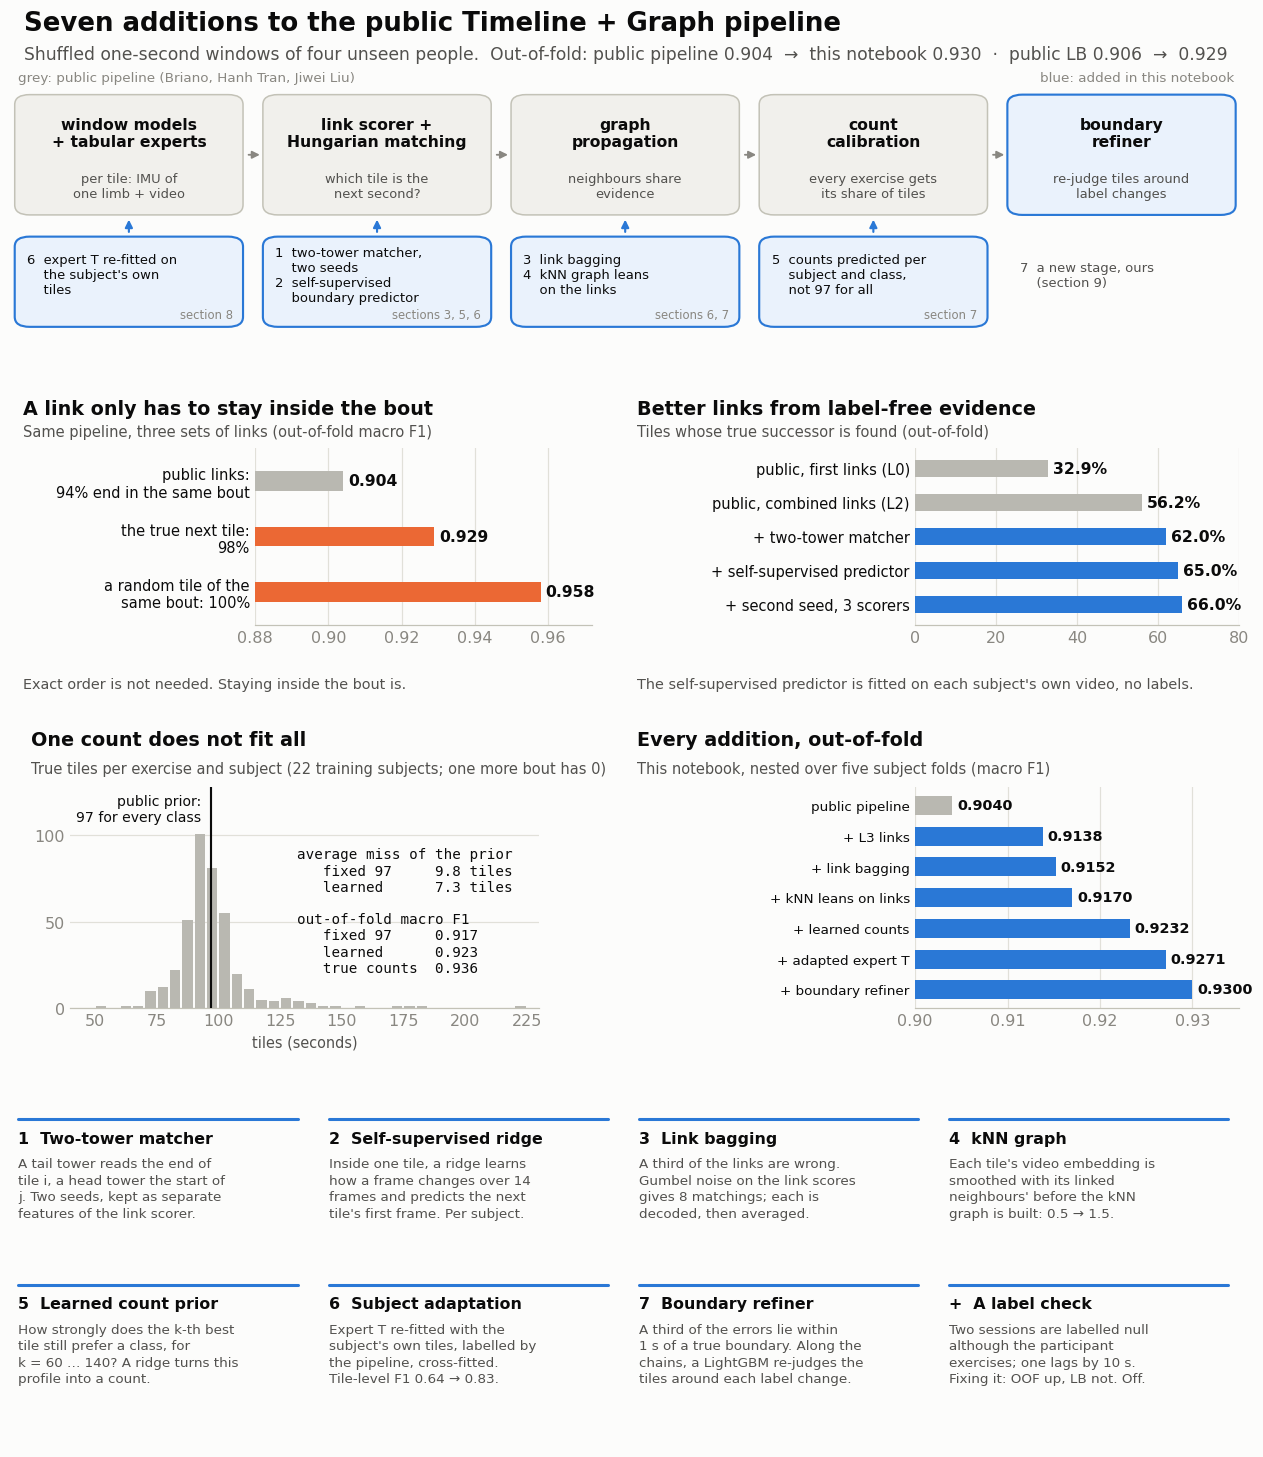

In [1]:
# The whole notebook in one picture. Every number comes from our local runs and is derived in the section named in
# the panel; nothing is computed by this cell.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

INK, INK2, MUTED, GRID, AXIS, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
OURS, WHATIF, PUBLIC = "#2a78d6", "#eb6834", "#b9b8b1"       # ours / what-if experiment / public pipeline
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10.5, "text.color": INK, "axes.labelcolor": INK2,
                     "xtick.color": MUTED, "ytick.color": MUTED, "axes.edgecolor": AXIS})

STAGES = ["public pipeline", "+ L3 links", "+ link bagging", "+ kNN leans on links", "+ learned counts",
          "+ adapted expert T", "+ boundary refiner"]
STAGE_OOF = [0.9040, 0.9138, 0.9152, 0.9170, 0.9232, 0.9271, 0.9300]
COUNT_EDGES = list(range(40, 231, 5))
COUNT_HIST = [0, 0, 1, 0, 1, 1, 10, 12, 22, 51, 101, 81, 55, 20, 11, 5, 4, 6, 4, 3, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0]

fig = plt.figure(figsize=(12, 13.4), dpi=110, facecolor=SURF)
fig.text(0.04, 0.982, "Seven additions to the public Timeline + Graph pipeline", fontsize=17, weight="bold", va="top")
fig.text(0.04, 0.958, "Shuffled one-second windows of four unseen people.  Out-of-fold: "
         "public pipeline 0.904  →  this notebook 0.930  ·  public LB 0.906  →  0.929", fontsize=11.2, color=INK2, va="top")


def panel(rect, title, sub, title_x=0.0):
    ax = fig.add_axes(rect, facecolor=SURF)
    ax.text(title_x, 1.17, title, transform=ax.transAxes, fontsize=12.5, weight="bold", va="bottom")
    ax.text(title_x, 1.05, sub, transform=ax.transAxes, fontsize=9.6, color=INK2, va="bottom")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.tick_params(length=0)
    return ax


# ---------------------------------------------------------------- A. where the pipeline changes
ax = fig.add_axes([0.03, 0.765, 0.94, 0.17], facecolor=SURF)
ax.set_xlim(0, 100)
ax.set_ylim(0, 30)
ax.axis("off")
boxes = [(0.5, "window models\n+ tabular experts", "per tile: IMU of\none limb + video", False),
         (20.5, "link scorer +\nHungarian matching", "which tile is the\nnext second?", False),
         (40.5, "graph\npropagation", "neighbours share\nevidence", False),
         (60.5, "count\ncalibration", "every exercise gets\nits share of tiles", False),
         (80.5, "boundary\nrefiner", "re-judge tiles around\nlabel changes", True)]
for x, head, body, ours_box in boxes:
    ax.add_patch(FancyBboxPatch((x, 14.0), 18, 14.0, boxstyle="round,pad=0.2,rounding_size=1.2",
                                fc="#eaf2fc" if ours_box else "#f1f0ec", ec=OURS if ours_box else AXIS, lw=1.4 if ours_box else 1))
    ax.text(x + 9, 23.6, head, ha="center", va="center", fontsize=10.2, weight="bold")
    ax.text(x + 9, 17.2, body, ha="center", va="center", fontsize=8.5, color=INK2)
for x in (18.9, 38.9, 58.9, 78.9):
    ax.add_patch(FancyArrowPatch((x, 21.0), (x + 1.4, 21.0), arrowstyle="-|>", mutation_scale=10, color=MUTED, lw=1.2))
ours = [(0.5, "6  expert T re-fitted on\n    the subject's own\n    tiles", "section 8"),
        (20.5, "1  two-tower matcher,\n    two seeds\n2  self-supervised\n    boundary predictor", "sections 3, 5, 6"),
        (40.5, "3  link bagging\n4  kNN graph leans\n    on the links", "sections 6, 7"),
        (60.5, "5  counts predicted per\n    subject and class,\n    not 97 for all", "section 7")]
for x, txt, sec in ours:
    ax.add_patch(FancyBboxPatch((x, 0.6), 18, 10.4, boxstyle="round,pad=0.2,rounding_size=1.2", fc="#eaf2fc", ec=OURS, lw=1.4))
    ax.text(x + 0.8, 6.6, txt, ha="left", va="center", fontsize=8.6)
    ax.text(x + 17.4, 1.1, sec, ha="right", va="bottom", fontsize=7.6, color=MUTED)
    ax.add_patch(FancyArrowPatch((x + 9, 11.4), (x + 9, 13.6), arrowstyle="-|>", mutation_scale=10, color=OURS, lw=1.4))
ax.text(80.5 + 0.8, 6.6, "7  a new stage, ours\n    (section 9)", ha="left", va="center", fontsize=8.6, color=INK2)
ax.text(0.6, 29.4, "grey: public pipeline (Briano, Hanh Tran, Jiwei Liu)", fontsize=8.8, color=MUTED, va="bottom")
ax.text(98.6, 29.4, "blue: added in this notebook", fontsize=8.8, color=MUTED, va="bottom", ha="right")


def hbars(ax, labels, values, colors, fmt, xlim, fs=9.6, h=0.36):
    y = list(range(len(values)))[::-1]
    ax.barh(y, [v - xlim[0] for v in values], left=xlim[0], height=h, color=colors, zorder=3)
    for yi, v in zip(y, values):
        ax.text(v + (xlim[1] - xlim[0]) * 0.015, yi, fmt.format(v), va="center", fontsize=fs + 0.6, weight="bold", zorder=4)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=fs, color=INK)
    ax.set_xlim(*xlim)
    ax.set_ylim(-0.6, len(values) - 0.4)
    ax.grid(axis="x", color=GRID, lw=0.8, zorder=0)
    ax.spines["left"].set_visible(False)


# ---------------------------------------------------------------- B. what a link has to do
ax = panel([0.215, 0.565, 0.255, 0.12], "A link only has to stay inside the bout",
           "Same pipeline, three sets of links (out-of-fold macro F1)", title_x=-0.69)
hbars(ax, ["public links:\n94% end in the same bout", "the true next tile:\n98%", "a random tile of the\nsame bout: 100%"],
      [0.904, 0.929, 0.958], [PUBLIC, WHATIF, WHATIF], "{:.3f}", (0.88, 0.972))
ax.text(-0.69, -0.36, "Exact order is not needed. Staying inside the bout is.", transform=ax.transAxes, fontsize=9.4, color=INK2)

# ---------------------------------------------------------------- C. finding the next tile
ax = panel([0.715, 0.565, 0.245, 0.12], "Better links from label-free evidence",
           "Tiles whose true successor is found (out-of-fold)", title_x=-0.86)
hbars(ax, ["public, first links (L0)", "public, combined links (L2)", "+ two-tower matcher", "+ self-supervised predictor",
          "+ second seed, 3 scorers"], [32.9, 56.2, 62.0, 65.0, 66.0], [PUBLIC, PUBLIC, OURS, OURS, OURS], "{:.1f}%", (0, 80), h=0.5)
ax.text(-0.86, -0.36, "The self-supervised predictor is fitted on each subject's own video, no labels.", transform=ax.transAxes,
        fontsize=9.4, color=INK2)

# ---------------------------------------------------------------- D. counts
ax = panel([0.075, 0.305, 0.355, 0.15], "One count does not fit all",
           "True tiles per exercise and subject (22 training subjects; one more bout has 0)", title_x=-0.085)
centers = [e + 2.5 for e in COUNT_EDGES[:-1]]
ax.bar(centers, COUNT_HIST, width=4.2, color=PUBLIC, zorder=3)
ax.axvline(97, color=INK, lw=1.4, zorder=4)
ax.text(93, 124, "public prior:\n97 for every class", fontsize=9.2, va="top", ha="right")
ax.set_xlim(40, 230)
ax.set_ylim(0, 128)
ax.set_yticks([0, 50, 100])
ax.set_xlabel("tiles (seconds)", fontsize=9.5)
ax.grid(axis="y", color=GRID, lw=0.8, zorder=0)
ax.spines["left"].set_visible(False)
ax.text(132, 56, "average miss of the prior\n   fixed 97     9.8 tiles\n   learned      7.3 tiles\n\nout-of-fold macro F1\n   fixed 97     0.917\n   learned      0.923\n   true counts  0.936",
        fontsize=9.3, va="center", family="DejaVu Sans Mono", color=INK)

# ---------------------------------------------------------------- E. this notebook, stage by stage
ax = panel([0.715, 0.305, 0.245, 0.15], "Every addition, out-of-fold",
           "This notebook, nested over five subject folds (macro F1)", title_x=-0.86)
hbars(ax, STAGES, STAGE_OOF, [PUBLIC] + [OURS] * (len(STAGES) - 1), "{:.4f}", (0.90, 0.935), fs=8.8, h=0.62)
ax.set_xticks([0.90, 0.91, 0.92, 0.93])

# ---------------------------------------------------------------- F. the eight ideas in words
ax = fig.add_axes([0.03, 0.008, 0.94, 0.225], facecolor=SURF)
ax.axis("off")
ax.set_xlim(0, 100)
ax.set_ylim(0, 40)
notes = [("1  Two-tower matcher", "A tail tower reads the end of\ntile i, a head tower the start of\nj. Two seeds, kept as separate\nfeatures of the link scorer."),
         ("2  Self-supervised ridge", "Inside one tile, a ridge learns\nhow a frame changes over 14\nframes and predicts the next\ntile's first frame. Per subject."),
         ("3  Link bagging", "A third of the links are wrong.\nGumbel noise on the link scores\ngives 8 matchings; each is\ndecoded, then averaged."),
         ("4  kNN graph", "Each tile's video embedding is\nsmoothed with its linked\nneighbours' before the kNN\ngraph is built: 0.5 → 1.5."),
         ("5  Learned count prior", "How strongly does the k-th best\ntile still prefer a class, for\nk = 60 … 140? A ridge turns this\nprofile into a count."),
         ("6  Subject adaptation", "Expert T re-fitted with the\nsubject's own tiles, labelled by\nthe pipeline, cross-fitted.\nTile-level F1 0.64 → 0.83."),
         ("7  Boundary refiner", "A third of the errors lie within\n1 s of a true boundary. Along the\nchains, a LightGBM re-judges the\ntiles around each label change."),
         ("+  A label check", "Two sessions are labelled null\nalthough the participant\nexercises; one lags by 10 s.\nFixing it: OOF up, LB not. Off.")]
for k, (head, body) in enumerate(notes):
    x0, y0 = 0.6 + 25 * (k % 4), 39.4 - 20 * (k // 4)
    ax.plot([x0, x0 + 22.5], [y0, y0], color=OURS, lw=2, solid_capstyle="round")
    ax.text(x0, y0 - 1.4, head, fontsize=10.4, weight="bold", va="top")
    ax.text(x0, y0 - 4.6, body, fontsize=8.8, color=INK2, va="top", linespacing=1.35)
plt.show()

The test set is 12,234 one-second windows of four unseen people, shuffled. Each window has the accelerometer of one random limb and 15 video frames. The public pipeline puts the windows back in order with *links*, lets linked and similar windows share evidence on a graph, and then gives every exercise its expected share of windows. We kept that design and asked six questions about it.

**1. Are the training labels right?** Not everywhere. The WEAR paper's supplementary material lists every recording session with its length and number of activities, and the lengths add up to the training files to the second. Two sessions are labelled `null` from start to end although the participant exercises in them (1,531 seconds), and in a third the labels come 10 seconds after the activity. Cleaning them raises the out-of-fold score but not the public LB, so this version trains on the labels as released; the cleaning is a switch (section 2).

**2. What does a link have to get right?** Not the order. If we replace the pipeline's links by the true next window, the out-of-fold score goes from 0.904 to 0.929. If we replace them by a *random* window of the same exercise bout, it goes to 0.958. A link is useful when it stays inside the bout (section 6).

**3. Then where do better links come from?** From evidence about time, not about labels. A scorer trained to pick windows of the same bout keeps 96% of its links inside the bout, more than any other set we built, and the score goes *down* (0.910 → 0.889): those links connect windows that already agree. So we improved the "next second" evidence itself, with two models that never see a label: a two-tower matcher trained on the training recordings, with two seeds (section 3), and a ridge predictor fitted on each subject's own video, test subjects included (section 5). The share of windows whose true successor is found goes from 56% to 66%.

**4. How much should the graph trust one matching?** The Hungarian assignment returns one timeline, yet a third of its links are not the true successor. We add Gumbel noise to the link scores, solve the assignment eight times, decode every matching separately and average (section 6). The graph's kNN graph can then lean more on the links (section 7).

**5. Is 97 windows per exercise right?** On average, yes. Per bout, no: real bouts last 60 to 140 seconds, and every window of mismatch becomes an error. A small regressor predicts the count of every (subject, exercise) from how its probability ranks decay (section 7).

**6. Where are the remaining errors?** A third of them lie within one second of a true boundary, where every expert is unsure. The graph does not know which neighbour comes before and which after; the chains do. A refiner walks the chains and re-judges the tiles around each label change (section 9).

And one transductive step: the tabular expert is re-fitted on the pipeline's own predictions for the same subject (section 8).

| step, in the order we submitted them | nested out-of-fold | public LB |
|---|---|---|
| public pipeline, reproduced | 0.9040 | 0.90624 |
| + two-tower features in the link scorer | 0.9103 | 0.91112 |
| + learned count prior | 0.9143 | 0.91654 |
| + pseudo-label adapted expert | 0.9198 | 0.92034 |
| + self-supervised features in the link scorer | 0.9211 | 0.92380 |
| the same four additions and nothing else | 0.9223 | 0.92515 |
| + link bagging (version 2 of this notebook) | 0.9230 | 0.92718 |
| + kNN graph leaning on the links | 0.9263 | 0.92651 |
| + boundary refiner | 0.9286 | 0.92573 |
| *side branch, not kept:* + cleaned training labels, whitened kNN embedding | 0.9415 ¹ | 0.92686 |
| **this version: + a second two-tower seed and three scorer seeds in the link scorer** | **0.9300** | **0.92942** |

¹ scored on the cleaned labels; every other row uses the labels as released.

**Read the last rows with care.** From the seventh row on, the public leaderboard no longer follows the out-of-fold score step by step: two runs of the same code with re-trained GPU models differed by 0.0037 there, the size of these steps. The public leaderboard is a sample of the windows of four people; the out-of-fold score covers 22. This version has the best public LB of all our runs; it is not the best out-of-fold (a whitened variant reached 0.9330, LB 0.92642).

Out-of-fold means: the 22 training subjects are cut into test-like one-second tiles (one random limb, shuffled), split into five subject folds, and every model that feeds a later stage is fitted without the subject it is applied to. It is the public notebook's protocol, extended here to the stages the public notebook only ran on the test set.

> The LB score in the title is from running this notebook on our own machine; version 3 of this notebook holds that run's outputs. The outputs below are from Kaggle's run of the same code. GPU training is not bit-reproducible, so the two can differ in the third decimal.

## Scoreboard: what each part is worth

**This version, stage by stage** (our own run, version 3; Kaggle's run below prints its own numbers, which differ slightly). Nested out-of-fold macro F1 on the 69,326 test-like tiles of the 22 training subjects (five subject folds). The third column gives the numbers the public notebook reports for its own stages.

| stage | out-of-fold | public notebook |
|---|---|---|
| window models: 4 fusion + 2 IMU-only seeds, blended | 0.7239 | 0.7253 |
| + label propagation + first links (L0) + count calibration | 0.8464 | 0.847 |
| + tabular experts S3 and T | 0.8776 | 0.877 |
| + combined links (L2) + graph self-training = **the public pipeline** | **0.9040** | 0.905 |
| + L3 links (two-tower and self-supervised features in the link scorer) | 0.9138 | |
| + link bagging (8 matchings) | 0.9152 | |
| + kNN graph leaning on the links (smoothing weight 0.5 → 1.5) | 0.9170 | |
| + learned count prior (two passes) | 0.9232 | |
| + tabular expert T adapted by pseudo-labels (T alone, per tile: 0.643 → 0.831) | 0.9271 | |
| + boundary refiner along the chains | **0.9300** | |
| *what if:* the true count of every (subject, exercise), instead of the learned one | 0.9359 ² | |

² in place of the learned counts, before the adapted expert and the refiner (compare with 0.9232).

Per fold at the end: 0.9375, 0.9128, 0.9373, 0.9168, 0.9441. The refiner changes 1,215 out-of-fold tiles and 137 test tiles.

**Links** (successor of every tile after the Hungarian assignment)

| links | linked | exact successor | ends in the same bout | full pipeline |
|---|---|---|---|---|
| public L0 | 92.5% | 32.9% | 88.7% | |
| public L2 (65 pair features) | 94.8% | 56.2% | 93.7% | 0.9040 |
| L2 + two-tower matcher (8 features) | 95.9% | 62.0% | 93.8% | 0.9087 |
| L2 + self-supervised predictor (7 features) | 95.1% | 60.8% | 94.5% | 0.9101 |
| L2 + both = L3 (version 2) | 95.9% | 65.0% | 94.5% | 0.9137 |
| **L3 with two two-tower seeds (16 features) and three scorer seeds (this version)** | 96.0% | **66.0%** | **94.5%** | **0.9138** |
| *what if:* the true next tile | 100% | 100% | 97.9% | 0.9293 |
| *what if:* a random tile of the same bout | 97.9% | 0% | 100% | 0.9582 |

The pipeline column uses the public blend and the fixed count prior, so that only the links differ between rows; all rows except this version's are from the version 2 run. A perturbed matching keeps 84% of the links of the plain one. In the feature importance of this version's L3 scorer (gain), the 65 public features hold 26%, the 16 two-tower features 67%, the 7 self-supervised features 7%.

## Credits and thanks

| Whose work | What we took from it | What we changed or added |
|---|---|---|
| **Briano** ([LB 0.890 \| WEAR@HASCA 2026 Timeline + Graph](https://www.kaggle.com/code/woominyo/lb-0-890-wear-hasca-2026-timeline-graph), Apache 2.0) | The whole base pipeline, as code: test-like tiles and the fold split, the window classifier, L0 and L2 link scorers with ridge boundary predictors and 65 pair features, the tabular experts T and S3, graph propagation with self-training, Sinkhorn count calibration. The code cells of sections 2 and 4 are theirs. | Lines marked `LOCAL`: an optional label check (off by default); leave-one-fold-out versions of the tabular experts and of the link scorer, so that every later stage can be scored out-of-fold; the candidate pairs are saved for our scorer; the graph stage accepts count targets and a kNN temperature. |
| **Hanh Tran** ([WEAR@HASCA LB 0.9](https://www.kaggle.com/code/honghanhhh/wear-hasca-lb-0-9)) | Timeline links as Briano's L0 stage uses them (adapted from this notebook, as Briano states): candidate successors from video-boundary similarity, a LightGBM pair scorer, a Hungarian assignment with cycle breaking. Also its habit of gating every change on an out-of-fold check, which we copied as a working rule. | — |
| **Jiwei Liu** ([public fast GPU inference](https://www.kaggle.com/code/jiweiliu/public-fast-gpu-inference)) | The inference-only packaging of the pipeline and its public score (LB 0.9077), which was our reproduction target. | We retrain everything inside the notebook instead of loading saved models. |
| **Akhyar Ahmad**, **Evelyn_Yang_02**, **Avik Das**, **Nomannic**, **SibamSamanta07**, **Swathi H A**, **Lakhindar Pal** (public notebooks of this competition) | Read while planning: chain decoding with Viterbi and count bands (Akhyar Ahmad), window counts per test subject (Avik Das), single-window baselines between 0.60 and 0.69. | None of their code is used here. |
| **Marius Bock, Hilde Kuehne, Kristof Van Laerhoven, Michael Moeller** | The WEAR dataset, this challenge, and the per-session table of the [supplementary material](https://github.com/mariusbock/wear/blob/main/supplementary_material.pdf) that made the label check of section 2 possible. | |

What is ours: the label check (section 2), the two-tower boundary matcher (section 3), the self-supervised subject-specific boundary predictor (section 5), their use as features of the link scorer (section 6), link bagging (section 6), the kNN graph changes and the learned count prior (section 7), the cross-fitted pseudo-label adaptation (section 8), the boundary refiner (section 9), the leave-one-fold-out extension that lets all of this be measured, and the experiments in section 10.

Thank you, Briano, Hanh Tran and Jiwei Liu. Without a pipeline this clearly written and this well documented, none of the questions above could have been asked in a week.

## 1. Setup

Attach the competition data and select the accelerator **GPU T4 x2**. No internet and no extra dataset are needed. The window models of the public pipeline train on both GPUs (about 30 minutes), our two-tower matcher trains with two seeds, one per GPU, and the CPU stages take the rest. Expect about about two hours in total.

**About the versions.** Version 1 (Quick Save, our outputs) and version 2 (run on Kaggle) are the configuration of the seventh row of the table above, LB 0.92718 from our own run. Version 3 adds the kNN smoothing change, the boundary refiner, and a second two-tower seed with three scorer seeds in the link scorer. It is a Quick Save of our own run, whose `submission.csv` scored LB 0.92942 (the notebook skips a stage whose outputs already exist, and in that run the six window models and the first two-tower seed came from an earlier run of the same code). This version (4) is the same code, run on Kaggle from scratch, so the outputs and the `submission.csv` below are Kaggle's. GPU training is not bit-reproducible, so Kaggle's result can differ in the third decimal: version 2's own `submission.csv` scored 0.92463 against 0.92718 for the same code on our machine.

`WEAR_SMOKE=1` runs a tiny version of everything (5 subjects, a few steps and boosting rounds) to test the code. `WEAR_DATA` and `WEAR_WORK` let the notebook run outside Kaggle. `WEAR_ABLATION=0` skips the out-of-fold scores of the intermediate steps (extra link scorers and decodes). `WEAR_CLEAN=1` trains on the cleaned labels of section 2, `WEAR_WHITEN=0.5` whitens the kNN embedding (section 7); both are off here.

In [2]:
import os
for _k in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_k, "4")       # Kaggle has 4 vCPUs; the reference runs used 4 BLAS threads as well
import gc, hashlib, json, re, shutil, subprocess, sys, threading, time
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.optimize import linear_sum_assignment
import lightgbm as lgb

SMOKE = os.environ.get("WEAR_SMOKE", "0") == "1"      # tiny run for testing the code
SMOKE_SUBJECTS = {0, 1, 2, 3, 4}
os.environ["WEAR_SEED"] = "11"   # FORK: independent fit
ABLATION = False   # FORK: skip the OOF ablations of the intermediate steps   # LOCAL: also score the unchanged public pipeline out-of-fold
# LOCAL: WEAR_CLEAN=1 cuts the sessions without labels off the end of their recordings (seconds kept) and
# moves lagging labels earlier (section 2). Off by default: on the public LB it did not help.
UNLABELLED_TAIL = {"sbj_10": 2566, "sbj_2": 3452} if os.environ.get("WEAR_CLEAN", "0") == "1" else {}
# LOCAL: labels that lag the signals: recording -> (from second, lag in seconds); the labels are moved earlier
LABEL_LAG = {"sbj_7": (1368, 10)} if UNLABELLED_TAIL else {}
SLUG = "3rd-wear-dataset-challenge-hasca-2026"
ON_KAGGLE = Path("/kaggle/input").exists()


def find_input():
    if os.environ.get("WEAR_DATA"):
        return Path(os.environ["WEAR_DATA"])
    for p in (Path("/kaggle/input/competitions") / SLUG, Path("/kaggle/input") / SLUG):
        if (p / "test" / "test_meta_data.csv").exists():
            return p
    hits = sorted(Path("/kaggle/input").glob("*/test/test_meta_data.csv")) + \
        sorted(Path("/kaggle/input").glob("*/*/test/test_meta_data.csv"))
    assert hits, "competition data not found: attach the competition or set WEAR_DATA"
    return hits[0].parent.parent


INPUT = find_input()
WORK = Path(os.environ.get("WEAR_WORK", "/kaggle/working" if ON_KAGGLE else "wear_run")).resolve()   # submission.csv
WORK.mkdir(parents=True, exist_ok=True)
os.chdir(WORK)
if os.environ.get("WEAR_ROOT"):
    ROOT = Path(os.environ["WEAR_ROOT"])
elif ON_KAGGLE and shutil.disk_usage("/tmp").free > 12e9:
    ROOT = Path("/tmp/wear")            # about 6.5 GB of scratch that must not become notebook output
else:
    ROOT = WORK / "_wear"
PROC, RUNS_DIR = ROOT / "proc", ROOT / "runs"
for _p in (ROOT, PROC, RUNS_DIR):
    _p.mkdir(parents=True, exist_ok=True)
CLEANUP = os.environ.get("WEAR_CLEANUP", "1" if ON_KAGGLE else "0") == "1"
WINDOW_BUDGET_MIN = float(os.environ.get("WEAR_WINDOW_BUDGET_MIN", "330"))   # FORK: more window runs   # wall-clock cap of the GPU stage

T_START, TIMES = time.time(), {}


def rss_gb():
    try:
        s = Path("/proc/self/status").read_text()
        return tuple(int(re.search(k + r":\s+(\d+)", s).group(1)) / 2 ** 20 for k in ("VmRSS", "VmHWM"))
    except Exception:
        return float("nan"), float("nan")


class stage:
    """logs wall time and memory of a pipeline stage and frees memory afterwards"""
    def __init__(self, name):
        self.name = name

    def __enter__(self):
        self.t = time.time()
        print(f"\n===== {self.name} | start at {(self.t - T_START) / 60:.1f} min", flush=True)
        return self

    def __exit__(self, *exc):
        gc.collect()
        TIMES[self.name] = time.time() - self.t
        r, h = rss_gb()
        print(f"===== {self.name} | {TIMES[self.name] / 60:.1f} min (total {(time.time() - T_START) / 60:.1f} min) "
              f"| RSS {r:.1f} GB, peak {h:.1f} GB", flush=True)


def error_line(text):
    """the most informative line of a subprocess traceback: the last 'SomeError: message' line"""
    lines = [l.strip() for l in text.strip().splitlines() if l.strip()]
    hits = [l for l in lines if re.match(r"[A-Za-z_][\w.]*(Error|Exception)(:|$)", l)]
    return (hits or lines or ["?"])[-1]


# Is there a GPU that torch can actually use? This runs in a subprocess so that the notebook itself holds no CUDA context.
# A GPU can be visible but unusable: torch.cuda.is_available() is True, yet the torch build has no kernels for it
# (e.g. a P100 = sm_60 with a torch build for sm_75+). The first CUDA op then fails, so the check runs one.
_chk = subprocess.run([sys.executable, "-c",
                       "import json, torch; assert torch.cuda.is_available(), 'torch.cuda.is_available() is False'; "
                       "torch.ones(8, device='cuda').sum().item(); "
                       "print(json.dumps({'n': torch.cuda.device_count(), 'name': torch.cuda.get_device_name(0), "
                       "'cap': torch.cuda.get_device_capability(0), 'torch': torch.__version__}))"],
                      capture_output=True, text=True)
GPU_OK = _chk.returncode == 0
GPU_INFO = json.loads(_chk.stdout.strip().splitlines()[-1]) if GPU_OK else {"n": 0}
N_GPU = GPU_INFO["n"]
print(f"input {INPUT}\nwork {WORK}\nscratch {ROOT}\nSMOKE={SMOKE} GPU={GPU_INFO if GPU_OK else 'none'}")
if not GPU_OK:
    print("WARNING: no usable GPU (" + error_line(_chk.stderr) + ").\n"
          "The window models fall back to a very reduced CPU run (with CUDA hidden from the training subprocesses), "
          "so the score will be far below 0.903. Select the GPU T4 x2 accelerator to reproduce the LB score.")

input /kaggle/input/competitions/3rd-wear-dataset-challenge-hasca-2026
work /kaggle/working
scratch /tmp/wear
SMOKE=False GPU={'n': 2, 'name': 'Tesla T4', 'cap': [7, 5], 'torch': '2.11.0+cu128'}


## 2. The public pipeline, part 1: test-like tiles and window models

*Code by Briano, unchanged except for an optional label check (lines marked `LOCAL`, off in this version).* The training recordings are cut the way the test set was made: non-overlapping one-second tiles, one random valid limb per tile, video frames 8 – 22 of the 30. Subjects are split into five folds. A small network (1D-CNN on the accelerometer, pooled MLP on the video, a fusion head) is trained per fold on windows at every 0.1 s and scored on the held-out subjects' tiles. Four fusion seeds and two accelerometer-only seeds are blended.

**Three label issues (ours).** Table 2 of the [WEAR supplementary material](https://github.com/mariusbock/wear/blob/main/supplementary_material.pdf) lists every recording session with its duration and number of activities, and the durations add up to the length of each training file to the second. (The paper's sbj_18∗ and sbj_19† are `sbj_0_2` and `sbj_14_2` here, and its sbj_20 – 23 are sbj_18 – 21 here.) With the sessions placed, three things stand out:

| file | where | what we found | with `WEAR_CLEAN=1` |
|---|---|---|---|
| `sbj_10` | session 3, from second 2566 to the end (1,419 s) | 9 activities in the table, labels all `null`; the window models see jogging variants, lunges, bench-dips, stretching | cut off |
| `sbj_2` | session 3, from second 3452 to the end (112 s) | 1 activity in the table, labels all `null`; the participant does jogging with rotating arms, which is missing from the other two sessions | cut off |
| `sbj_7` | session 2, from second 1368 | the labels come 10 s after the activity: in all nine bouts the held-out prediction starts 8 – 14 s and ends 9 – 12 s before the label. Of the 46 sessions, 44 agree best with the predictions at a shift of 0 (±1 s); this one goes from 0.807 to 0.978 agreement at +10 s | labels moved 10 s earlier |

**Why it is off.** On the cleaned labels the six window models reach 0.7361 out-of-fold instead of 0.7239, and the whole notebook 0.9415 (scored on the cleaned labels). On the public leaderboard, four runs trained on the cleaned labels scored 0.9232 – 0.9269 (mean about 0.925), against 0.9257 – 0.9286 (mean about 0.927) for three runs of the same kind (bagging, kNN smoothing 1.5, boundary refiner) on the released labels. Cleaning also removes noise from the evaluation, so part of the out-of-fold gain is not real, and the test labels probably follow the same conventions as the released ones. We report the issues because they are real and they matter for anyone validating out-of-fold: on our pipeline, leaving the 1,531 unlabelled tiles out of the evaluation alone moves the score from 0.9269 to 0.9315. This version trains on the labels as released.

In [3]:
N_CLS, WIN, VLEN = 19, 50, 15
CFG = {"imu_w": 0.3, "lp": (10, 0.1, 0.5, 0.9), "link_alpha": 0.5, "link_iters": 10, "sharpen_T": 0.5, "per_ex": 97,
       "null_min": 0.05}
TRAIN_SETS = {0: 2, 14: 2}   # train subjects 0 and 14 recorded the exercise circuit twice; every test subject once


def macro_f1(y, pred):
    cm = np.bincount(y * N_CLS + pred, minlength=N_CLS * N_CLS).reshape(N_CLS, N_CLS)
    tp = np.diag(cm)
    denom = cm.sum(0) + cm.sum(1)
    present = denom > 0
    return float((2 * tp[present] / denom[present]).mean())


def mean_logp(logps):
    return np.log(np.mean([np.exp(x) for x in logps], 0) + 1e-8)


def blend(fus, imu, wi):
    x = fus + wi * imu if imu is not None else fus
    x = x - x.max(1, keepdims=True)
    return x - np.log(np.exp(x).sum(1, keepdims=True))


def label_prop(P0, emb, grp, k=10, tau=0.1, use_p=0.5, alpha=0.9, iters=20):
    """per subject: kNN graph on (video similarity + prediction similarity), then probability propagation"""
    E = emb.astype(np.float32)
    E /= np.linalg.norm(E, axis=1, keepdims=True) + 1e-6
    F = np.empty_like(P0)
    for g in np.unique(grp):
        ii = np.flatnonzero(grp == g)
        n = len(ii)
        Q = np.sqrt(P0[ii]).astype(np.float32)
        S = E[ii] @ E[ii].T + use_p * (Q @ Q.T)
        np.fill_diagonal(S, -np.inf)
        nb = np.argpartition(-S, k, axis=1)[:, :k]
        rows = np.repeat(np.arange(n), k)
        vals = S[rows, nb.reshape(-1)]
        W = sp.csr_matrix((np.exp((vals - vals.max()) / tau), (rows, nb.reshape(-1))), shape=(n, n))
        W = W.maximum(W.T)
        d_ = np.asarray(W.sum(1)).ravel()
        d_[d_ == 0] = 1
        Dm = sp.diags(1 / np.sqrt(d_))
        Wn = Dm @ W @ Dm
        f0 = P0[ii]
        f = f0.copy()
        for _ in range(iters):
            f = alpha * (Wn @ f) + (1 - alpha) * f0
        F[ii] = f
    return F


def link_smooth(P, succ, score, alpha, iters):
    """mix each window with its linked successor/predecessor (weights sigmoid(link log-odds))"""
    m = succ >= 0
    src, dst = np.flatnonzero(m), succ[m]
    wt = 1 / (1 + np.exp(-np.clip(score[m], -20, 20)))
    W = sp.csr_matrix((np.r_[wt, wt], (np.r_[src, dst], np.r_[dst, src])), shape=(len(P), len(P)))
    d_ = np.asarray(W.sum(1)).ravel()
    cur = P.copy()
    for _ in range(iters):
        nb = (W @ cur) / np.maximum(d_[:, None], 1e-8)
        mix = np.where(d_[:, None] > 0, (1 - alpha) * P + alpha * nb, P)
        cur = mix / mix.sum(1, keepdims=True)
    return cur


def calibrate(P, sbj, sets, per_ex, null_min, iters=50):
    """Sinkhorn per subject: each exercise column sums to per_ex x (number of sets), null takes the rest"""
    out = np.empty_like(P)
    for s in np.unique(sbj):
        ii = np.flatnonzero(sbj == s)
        n = len(ii)
        null = max(n - 18 * per_ex * sets.get(int(s), 1), null_min * n)
        t_ = np.full(P.shape[1], (n - null) / 18)
        t_[0] = null
        Q = P[ii].copy()
        for _ in range(iters):
            Q *= (t_ / np.maximum(Q.sum(0), 1e-9))[None]
            Q /= Q.sum(1, keepdims=True)
        out[ii] = Q
    return out


def context_baseline(d):
    P = label_prop(np.exp(d["logp"]), d["emb"], d["grp"], *CFG["lp"])
    P = P / P.sum(1, keepdims=True)
    return link_smooth(P, d["succ"], d["score"], CFG["link_alpha"], CFG["link_iters"])


def finish(P, d):
    """pre-calibration probabilities (N,19) -> sharpen -> per-subject count calibration -> labels"""
    Q = np.clip(P, 1e-12, None) ** (1 / CFG["sharpen_T"])
    Q = calibrate(Q / Q.sum(1, keepdims=True), d["sbj"], d["sets"], CFG["per_ex"], CFG["null_min"])
    return Q.argmax(1)

In [ ]:
CLASSES = ["null", "jogging", "jogging (rotating arms)", "jogging (skipping)", "jogging (sidesteps)",
           "jogging (butt-kicks)", "stretching (triceps)", "stretching (lunging)", "stretching (shoulders)",
           "stretching (hamstrings)", "stretching (lumbar rotation)", "push-ups", "push-ups (complex)",
           "sit-ups", "sit-ups (complex)", "burpees", "lunges", "lunges (complex)", "bench-dips"]
LABEL_IDX = {c: i for i, c in enumerate(CLASSES)}
SENSORS = ["right_arm", "right_leg", "left_leg", "left_arm"]
ACC_COLS = [f"{s}_acc_{a}" for s in SENSORS for a in "xyz"]


def prep():
    recs = []
    csvs = sorted((INPUT / "train" / "inertial_feat").glob("*.csv"))     # this order defines the recording index
    if SMOKE:
        csvs = [c for c in csvs if int(c.stem.split("_")[1]) in SMOKE_SUBJECTS]
    for csv in csvs:
        stem = csv.stem
        df = pd.read_csv(csv, usecols=["sbj_id", *ACC_COLS, "label"], dtype={"label": str})
        acc = df[ACC_COLS].to_numpy(np.float32)
        valid = ~np.isnan(acc).reshape(-1, 4, 3).any(2)
        n_nan = int(np.isnan(acc).sum())
        if n_nan:
            acc = pd.DataFrame(acc).interpolate(limit_direction="both").fillna(0).to_numpy(np.float32)
        labels = df["label"].fillna("null").astype(str).str.strip()
        unknown = set(labels.unique()) - set(CLASSES)
        assert not unknown, f"{stem}: unknown labels {unknown}"
        lab = labels.map(LABEL_IDX).to_numpy(np.int8)
        vid = np.load(INPUT / "train" / "videomae_feat" / f"{stem}.npy").astype(np.float16)
        if stem in LABEL_LAG:            # LOCAL: in this session the labels come 10 s after the activity (section 1)
            t0, lag = LABEL_LAG[stem][0] * 50, LABEL_LAG[stem][1] * 50
            lab[t0:len(lab) - lag] = lab[t0 + lag:].copy()
            lab[len(lab) - lag:] = 0
        if stem in UNLABELLED_TAIL:      # LOCAL: the last session of this recording carries no labels (section 1)
            sec = UNLABELLED_TAIL[stem]
            acc, lab, valid, vid = acc[:sec * 50], lab[:sec * 50], valid[:sec * 50], vid[:sec * 30]
        np.save(PROC / f"{stem}_acc.npy", acc)
        np.save(PROC / f"{stem}_lab.npy", lab)
        np.save(PROC / f"{stem}_valid.npy", valid)
        np.save(PROC / f"{stem}_vid.npy", vid)
        recs.append({"stem": stem, "sbj": int(df["sbj_id"].iloc[0]), "T": len(acc), "F": len(vid)})
        print(f"{stem}: T={len(acc)} ({len(acc) / 50:.0f}s) F={len(vid)} nan={n_nan}", flush=True)
        del df, acc, vid
    (PROC / "recordings.json").write_text(json.dumps(recs, indent=1))

    meta = pd.read_csv(INPUT / "test" / "test_meta_data.csv")
    t_acc = np.load(INPUT / "test" / "test_inertial_data.npy").astype(np.float32)
    t_vid = np.load(INPUT / "test" / "test_videomae_data.npy")
    print("test shapes:", t_acc.shape, t_vid.shape, t_vid.dtype)
    if t_vid.shape[1] == 768:
        t_vid = t_vid.transpose(0, 2, 1)
    loc_col = "sensor_location" if "sensor_location" in meta else "inertial_sensor_location"
    np.save(PROC / "test_acc.npy", t_acc)
    np.save(PROC / "test_vid.npy", np.ascontiguousarray(t_vid).astype(np.float16))
    np.save(PROC / "test_sensor.npy", meta[loc_col].map({s: i for i, s in enumerate(SENSORS)}).to_numpy(np.int8))
    np.save(PROC / "test_id.npy", meta["id"].to_numpy())
    np.save(PROC / "test_sbj.npy", meta["sbj_id"].to_numpy(np.int16))
    print(meta[loc_col].value_counts().to_dict(), meta["sbj_id"].value_counts().sort_index().to_dict())
    return recs


with stage("W1 preprocessing"):
    if not (ROOT / ".done_prep").exists():
        recs = prep()
        (ROOT / ".done_prep").touch()
    recs = json.loads((PROC / "recordings.json").read_text())
    if not SMOKE:
        _cut = (3564 - UNLABELLED_TAIL.get("sbj_2", 3564)) + (3985 - UNLABELLED_TAIL.get("sbj_10", 3985))   # LOCAL: seconds cut off
        assert len(recs) == 24 and sum(r["T"] for r in recs) == 3466400 - 50 * _cut and sum(r["F"] for r in recs) == 2079840 - 30 * _cut
        assert all(r["F"] * 5 == r["T"] * 3 for r in recs)
    print(f"{len(recs)} recordings, {len({r['sbj'] for r in recs})} subjects")

In [ ]:
STRIDE, FOLDS = 5, 5


def oof_windows():
    recs = json.loads((PROC / "recordings.json").read_text())
    W_rec, W_start, W_y, W_sbj, W_ok = [], [], [], [], []
    for i, r in enumerate(recs):
        lab = np.load(PROC / f"{r['stem']}_lab.npy").astype(np.int64)
        val = np.load(PROC / f"{r['stem']}_valid.npy")
        T, Fr = r["T"], r["F"]
        starts = np.arange(0, T - WIN + 1, STRIDE)
        starts = starts[starts * 3 // 5 + 8 + VLEN <= Fr]
        cs = np.zeros((T + 1, N_CLS), np.int32)
        np.cumsum(np.eye(N_CLS, dtype=np.int32)[lab], axis=0, out=cs[1:])
        cnt = cs[starts + WIN] - cs[starts]
        miss = np.zeros((T + 1, 4), np.int32)
        np.cumsum(~val, axis=0, out=miss[1:])
        W_ok.append((miss[starts + WIN] - miss[starts]) == 0)
        W_rec.append(np.full(len(starts), i))
        W_start.append(starts)
        W_y.append(cnt.argmax(1))
        W_sbj.append(np.full(len(starts), r["sbj"]))
    W_rec, W_start, W_y, W_sbj, W_ok = map(np.concatenate, (W_rec, W_start, W_y, W_sbj, W_ok))
    keep = W_ok.any(1)
    W_rec, W_start, W_y, W_sbj, W_ok = (x[keep] for x in (W_rec, W_start, W_y, W_sbj, W_ok))

    sbjs, sbj_n = np.unique(W_sbj, return_counts=True)
    fold_of, load = {}, np.zeros(FOLDS)
    for s in sbjs[np.argsort(-sbj_n)]:
        f = int(load.argmin())
        fold_of[s] = f
        load[f] += sbj_n[sbjs == s][0]
    W_fold = np.array([fold_of[s] for s in W_sbj])

    out = {k: [] for k in ("rec", "start", "sensor", "y", "sbj", "fold")}
    for fold in range(FOLDS):
        idx = np.flatnonzero(W_fold == fold)
        idx = idx[W_start[idx] % WIN == 0]
        rng = np.random.default_rng(1234 + fold)
        cp = np.cumsum(W_ok[idx] / W_ok[idx].sum(1, keepdims=True), 1)
        sensor = (rng.random(len(idx))[:, None] > cp).sum(1)
        for k, v in (("rec", W_rec[idx]), ("start", W_start[idx]), ("sensor", sensor), ("y", W_y[idx]),
                     ("sbj", W_sbj[idx]), ("fold", np.full(len(idx), fold))):
            out[k].append(v)
    out = {k: np.concatenate(v) for k, v in out.items()}
    return recs, out


def load_inputs(recs, w):
    """per-window IMU of the chosen limb (N,50,3) float32 and video (N,15,768) float16"""
    n = len(w["rec"])
    acc = np.zeros((n, WIN, 3), np.float32)
    vid = np.zeros((n, VLEN, 768), np.float16)
    for i, r in enumerate(recs):
        ii = np.flatnonzero(w["rec"] == i)
        if not len(ii):
            continue
        a = np.load(PROC / f"{r['stem']}_acc.npy").reshape(-1, 4, 3)
        v = np.load(PROC / f"{r['stem']}_vid.npy", mmap_mode="r")
        st = w["start"][ii]
        acc[ii] = a[st[:, None] + np.arange(WIN), w["sensor"][ii][:, None]]
        vid[ii] = v[(st * 3 // 5)[:, None] + 8 + np.arange(VLEN)]
    return acc, vid


with stage("W2 test-like OOF windows"):
    if not (ROOT / ".done_simwin").exists():
        _recs, _w = oof_windows()
        _acc, _vid = load_inputs(_recs, _w)
        np.save(ROOT / "sim_acc.npy", _acc)
        np.save(ROOT / "sim_vid.npy", _vid)
        np.savez(ROOT / "sim_meta.npz", **_w)
        del _acc, _vid, _w
        (ROOT / ".done_simwin").touch()
    sim = {k: v.astype(np.int64) for k, v in dict(np.load(ROOT / "sim_meta.npz")).items()}
    fold_of = {int(s): int(f) for s, f in zip(sim["sbj"], sim["fold"])}
    print("rows", len(sim["y"]), "folds", {f: sorted(s for s in fold_of if fold_of[s] == f) for f in range(FOLDS)})
    if not SMOKE:
        assert len(sim["y"]) == (69326 if not UNLABELLED_TAIL else 67795), len(sim["y"])   # LOCAL
        assert UNLABELLED_TAIL or np.bincount(sim["fold"]).tolist() == [14353, 12995, 14625, 12768, 14585]
        assert UNLABELLED_TAIL or hashlib.sha1(sim["sensor"].tobytes()).hexdigest()[:12] == "f81d90085315"
        assert UNLABELLED_TAIL or hashlib.sha1(np.stack([sim["rec"], sim["start"]]).tobytes()).hexdigest()[:12] == "e4177f2589d7"

In [ ]:
%%writefile train_window.py
"""Window classifier, 5-fold by subject. This is a verbatim copy of our train.py with Kaggle patches marked 'PATCH':
 (a) mixed precision: bf16 on Ampere+ (as in the original runs), fp16 autocast + GradScaler on T4 (sm_75), and fp32
     on older GPUs, on CPU and when WEAR_AMP=0
 (b) memory-mapped per-recording video: only the concatenated copy is held in RAM
 (c) the class-balanced sampler uses a precomputed CDF, which gives the same indices as rng.choice(n, bs, p=pw)
Outputs (--out): oof_raw.npz (OOF log-probs of the test-like 1-s tiles + video embedding), test_logp_raw.npy (mean of
the 5 fold models' log-softmax), test_emb.npy. oof.npz / test_logp.npy / bias.npy / model_f*.pt are not used later.
"""
import argparse
import json
import math
import os
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

p = argparse.ArgumentParser()
p.add_argument("--data", default="/workspace/proc")
p.add_argument("--out", default="/workspace/runs/v1")
p.add_argument("--folds", type=int, default=5)
p.add_argument("--epochs", type=int, default=24)
p.add_argument("--steps", type=int, default=300)
p.add_argument("--bs", type=int, default=512)
p.add_argument("--lr", type=float, default=1e-3)
p.add_argument("--dim", type=int, default=256)
p.add_argument("--seed", type=int, default=0)
p.add_argument("--ema", type=float, default=0.999)
p.add_argument("--vnorm", default="global", choices=["global", "subject"])  # video feature normalisation unit
p.add_argument("--anorm", default="global", choices=["global", "subject"])  # IMU normalisation unit
p.add_argument("--run_folds", default="")  # e.g. "0,2" (empty = all)
p.add_argument("--eval_every", type=int, default=4)
p.add_argument("--vid_arch", default="pool", choices=["pool", "tf"])  # pool: mean/std pooling + MLP
p.add_argument("--vdrop", type=float, default=0.5)  # video input feature dropout
p.add_argument("--knn", default="1,5,10,20,40")  # neighbour-smoothing k candidates (logging only; 1 = off)
p.add_argument("--only", default="none", choices=["none", "imu", "video"])  # single-modality model
args = p.parse_args()

N_CLS, WIN, VLEN, STRIDE = 19, 50, 15, 5
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# PATCH (a): bf16 autocast is unsupported or emulated on T4 / P100 -> capability switch
CAP = torch.cuda.get_device_capability() if dev.type == "cuda" else (0, 0)
USE_AMP = CAP >= (7, 0)                                             # T4 (7,5): fp16 tensor cores; P100 (6,0): fp32
USE_AMP = USE_AMP and os.environ.get("WEAR_AMP", "1") != "0"          # the driver retries a failed run in fp32
AMP_DTYPE = torch.float16 if (7, 0) <= CAP < (8, 0) else torch.bfloat16
torch.ones(8, device=dev).sum().item()                              # fails fast if torch has no kernels for this GPU
if dev.type == "cuda":
    torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
out_dir = Path(args.out)
out_dir.mkdir(parents=True, exist_ok=True)
log_f = open(out_dir / "log.txt", "a")


def make_scaler(enabled):  # PATCH (a)
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)


def log(*a):
    s = " ".join(str(x) for x in a)
    print(s, flush=True)
    log_f.write(s + "\n")
    log_f.flush()


log(f"device {dev} capability {CAP} precision {AMP_DTYPE if USE_AMP else torch.float32} torch {torch.__version__}")


def macro_f1(y, pred):
    cm = np.bincount(y * N_CLS + pred, minlength=N_CLS * N_CLS).reshape(N_CLS, N_CLS)
    tp = np.diag(cm)
    denom = cm.sum(0) + cm.sum(1)
    present = denom > 0
    return float((2 * tp[present] / denom[present]).mean())


# ---------------- data ----------------
D = Path(args.data)
recs = json.loads((D / "recordings.json").read_text())
acc_l, lab_l, vid_l, val_l = [], [], [], []
for r in recs:
    acc_l.append(np.load(D / f"{r['stem']}_acc.npy"))
    val_l.append(np.load(D / f"{r['stem']}_valid.npy"))
    lab_l.append(np.load(D / f"{r['stem']}_lab.npy").astype(np.int64))
    vid_l.append(np.load(D / f"{r['stem']}_vid.npy", mmap_mode="r"))  # PATCH (b)
acc_off = np.cumsum([0] + [len(a) for a in acc_l])[:-1]
vid_off = np.cumsum([0] + [len(v) for v in vid_l])[:-1]
acc_all = np.concatenate(acc_l)
vid_all = np.concatenate(vid_l)

test_acc_np = np.load(D / "test_acc.npy")
test_vid_np = np.load(D / "test_vid.npy")
test_sensor_np = np.load(D / "test_sensor.npy").astype(np.int64)
test_sbj_np = np.load(D / "test_sbj.npy").astype(np.int64)

# normalisation groups: train subjects + test subjects (global mode: all groups share one set of stats)
SB = sorted({r["sbj"] for r in recs})
TS = sorted(set(test_sbj_np.tolist()))
G = len(SB) + len(TS)
test_grp_np = np.array([len(SB) + TS.index(t) for t in test_sbj_np])


def acc_stats(x, ok):
    """x (n,4,3), ok (n,4) -> per-sensor mean/std (4,3)"""
    m, sd = np.zeros((4, 3)), np.ones((4, 3))
    for k in range(4):
        xs = x[ok[:, k], k].astype(np.float64)
        if len(xs) > 100:
            m[k], sd[k] = xs.mean(0), xs.std(0) + 1e-3
    return m, sd


def vid_stats(v):
    v = v.astype(np.float32)
    return v.mean(0), v.std(0) + 1e-3


AM, AS = np.zeros((G, 4, 3)), np.ones((G, 4, 3))
VM, VS = np.zeros((G, 768)), np.ones((G, 768))
if args.anorm == "global":
    AM[:], AS[:] = acc_stats(acc_all.reshape(-1, 4, 3)[::5], np.concatenate(val_l)[::5])
else:
    for gi, sb in enumerate(SB):
        ii = [i for i, r in enumerate(recs) if r["sbj"] == sb]
        AM[gi], AS[gi] = acc_stats(np.concatenate([acc_l[i] for i in ii]).reshape(-1, 4, 3), np.concatenate([val_l[i] for i in ii]))
    for ti, t in enumerate(TS):
        m = test_sbj_np == t
        x = np.zeros((m.sum(), WIN, 4, 3), np.float32)
        ok = np.zeros((m.sum(), WIN, 4), bool)
        x[np.arange(m.sum()), :, test_sensor_np[m]] = test_acc_np[m]
        ok[np.arange(m.sum()), :, test_sensor_np[m]] = True
        AM[len(SB) + ti], AS[len(SB) + ti] = acc_stats(x.reshape(-1, 4, 3), ok.reshape(-1, 4))
if args.vnorm == "global":
    VM[:], VS[:] = vid_stats(vid_all[::7])
else:
    for gi, sb in enumerate(SB):
        VM[gi], VS[gi] = vid_stats(np.concatenate([vid_l[i][::3] for i, r in enumerate(recs) if r["sbj"] == sb]))
    for ti, t in enumerate(TS):
        VM[len(SB) + ti], VS[len(SB) + ti] = vid_stats(test_vid_np[test_sbj_np == t].reshape(-1, 768))
AM, AS, VM, VS = (torch.tensor(x, dtype=torch.float32, device=dev) for x in (AM, AS, VM, VS))
ACC = torch.from_numpy(acc_all).to(dev)
VID = torch.from_numpy(vid_all).to(dev)
del acc_all, vid_all

# window list: starts every 0.1 s, label = majority label inside the window
W_rec, W_start, W_y, W_pur, W_sbj, W_ok = [], [], [], [], [], []
for i, r in enumerate(recs):
    T, Fr = len(acc_l[i]), len(vid_l[i])
    starts = np.arange(0, T - WIN + 1, STRIDE)
    starts = starts[starts * 3 // 5 + 8 + VLEN <= Fr]
    cs = np.zeros((T + 1, N_CLS), np.int32)
    np.cumsum(np.eye(N_CLS, dtype=np.int32)[lab_l[i]], axis=0, out=cs[1:])
    cnt = cs[starts + WIN] - cs[starts]
    miss = np.zeros((T + 1, 4), np.int32)
    np.cumsum(~val_l[i], axis=0, out=miss[1:])
    W_ok.append((miss[starts + WIN] - miss[starts]) == 0)  # (n,4) sensors without missing data in the window
    W_rec.append(np.full(len(starts), i))
    W_start.append(starts)
    W_y.append(cnt.argmax(1))
    W_pur.append(cnt.max(1) / WIN)
    W_sbj.append(np.full(len(starts), r["sbj"]))
W_rec, W_start, W_y, W_pur, W_sbj, W_ok = map(np.concatenate, (W_rec, W_start, W_y, W_pur, W_sbj, W_ok))
keep = W_ok.any(1)
W_rec, W_start, W_y, W_pur, W_sbj, W_ok = (x[keep] for x in (W_rec, W_start, W_y, W_pur, W_sbj, W_ok))
W_ok_t = torch.as_tensor(W_ok, device=dev)
W_grp = np.array([SB.index(s) for s in W_sbj])
log(f"(window, sensor) pairs with missing data excluded: {int((~W_ok).sum())}")
log(f"windows={len(W_y)} recordings={len(recs)} subjects={len(np.unique(W_sbj))}")
log("class counts:", np.bincount(W_y, minlength=N_CLS).tolist())

acc_off_t = torch.tensor(acc_off, device=dev)
vid_off_t = torch.tensor(vid_off, device=dev)
ar50 = torch.arange(WIN, device=dev)
ar15 = torch.arange(VLEN, device=dev)


def rand_rot(n, max_deg=20.0):
    axis = F.normalize(torch.randn(n, 3, device=dev), dim=1)
    ang = (torch.rand(n, device=dev) * 2 - 1) * math.radians(max_deg)
    K = torch.zeros(n, 3, 3, device=dev)
    K[:, 0, 1], K[:, 0, 2], K[:, 1, 2] = -axis[:, 2], axis[:, 1], -axis[:, 0]
    K = K - K.transpose(1, 2)
    s, c = ang.sin()[:, None, None], ang.cos()[:, None, None]
    return torch.eye(3, device=dev) + s * K + (1 - c) * (K @ K)


def prep_inputs(a_raw, v_raw, sensor, g, train):
    """a_raw (B,50,3) in g, v_raw (B,15,768) f16, sensor (B,), g (B,) normalisation group -> model inputs"""
    B = a_raw.shape[0]
    a_raw = a_raw.float()
    if train:
        a_raw = a_raw @ rand_rot(B)
        a_raw = a_raw * (0.9 + 0.2 * torch.rand(B, 1, 1, device=dev))
        a_raw = a_raw + 0.02 * torch.randn_like(a_raw)
    mag = a_raw.norm(dim=-1, keepdim=True) - 1.0
    a = (a_raw - AM[g, sensor][:, None]) / AS[g, sensor][:, None]
    a = torch.cat([a, mag], -1)
    v = (v_raw.float() - VM[g][:, None]) / VS[g][:, None]
    has_a = torch.ones(B, device=dev)
    has_v = torch.ones(B, device=dev)
    if args.only != "none":
        if args.only == "imu":
            v = torch.zeros_like(v)
        else:
            a = torch.zeros_like(a)
        if train:
            v = v + 0.1 * torch.randn_like(v) * (args.only == "video")
        return a, v, has_a * (args.only == "imu"), has_v * (args.only == "video")
    if train:
        v = v + 0.1 * torch.randn_like(v)
        v = v * (torch.rand(B, VLEN, 1, device=dev) > 0.1)
        r = torch.rand(B, device=dev)
        has_v = (r >= 0.2).float()          # 20%: no video
        has_a = ((r < 0.2) | (r >= 0.3)).float()  # 10%: no IMU
        v = v * has_v[:, None, None]
        a = a * has_a[:, None, None]
    return a, v, has_a, has_v


def gather_train(idx, sensor):
    rec = torch.as_tensor(W_rec[idx], device=dev)
    st = torch.as_tensor(W_start[idx], device=dev)
    B = len(idx)
    a = ACC[acc_off_t[rec][:, None] + st[:, None] + ar50].view(B, WIN, 4, 3)
    a = a[torch.arange(B, device=dev), :, sensor]
    v = VID[vid_off_t[rec][:, None] + (st * 3 // 5)[:, None] + 8 + ar15]
    return a, v


# ---------------- model ----------------
class ConvBlock(nn.Module):
    def __init__(self, cin, cout, k, d=1):
        super().__init__()
        self.c = nn.Conv1d(cin, cout, k, padding=d * (k // 2), dilation=d)
        self.bn = nn.BatchNorm1d(cout)
        self.skip = nn.Conv1d(cin, cout, 1) if cin != cout else nn.Identity()

    def forward(self, x):
        return F.gelu(self.bn(self.c(x))) + self.skip(x)


class Net(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.sens = nn.Embedding(4, 32)
        self.imu = nn.Sequential(ConvBlock(4 + 32, 64, 7), ConvBlock(64, 128, 5), ConvBlock(128, 128, 5, 2),
                                 ConvBlock(128, d, 3, 4), ConvBlock(d, d, 3, 8))
        self.imu_out = nn.Sequential(nn.Linear(2 * d, d), nn.GELU())
        self.vin = nn.Sequential(nn.Dropout(args.vdrop), nn.Linear(768, d), nn.GELU(), nn.Dropout(0.2))
        if args.vid_arch == "tf":
            self.vpos = nn.Parameter(torch.zeros(1, VLEN, d))
            layer = nn.TransformerEncoderLayer(d, 4, 2 * d, 0.1, activation="gelu", batch_first=True, norm_first=True)
            self.vtf = nn.TransformerEncoder(layer, 2)
        self.vid_out = nn.Sequential(nn.Linear(2 * d, d), nn.GELU(), nn.Dropout(0.3))
        self.fuse = nn.Sequential(nn.Linear(2 * d + 32, d), nn.GELU(), nn.Dropout(0.3), nn.Linear(d, N_CLS))
        self.h_imu = nn.Linear(d, N_CLS)
        self.h_vid = nn.Linear(d, N_CLS)

    def forward(self, a, v, sensor):
        e = self.sens(sensor)
        x = torch.cat([a.transpose(1, 2), e[:, :, None].expand(-1, -1, a.shape[1])], 1)
        h = self.imu(x)
        hi = self.imu_out(torch.cat([h.mean(-1), h.amax(-1)], 1))
        if args.vid_arch == "tf":
            z = self.vtf(self.vin(v) + self.vpos)
            hv = self.vid_out(torch.cat([z.mean(1), z.amax(1)], 1))
        else:
            z = self.vin(v)
            hv = self.vid_out(torch.cat([z.mean(1), z.std(1)], 1))
        return self.fuse(torch.cat([hi, hv, e], 1)), self.h_imu(hi), self.h_vid(hv)


@torch.no_grad()
def predict(model, a_raw, v_raw, sensor, g, bs=2048, heads=False):
    model.eval()
    outs = []
    for i in range(0, len(sensor), bs):
        a, v, _, _ = prep_inputs(a_raw[i:i + bs], v_raw[i:i + bs], sensor[i:i + bs], g[i:i + bs], False)
        with torch.autocast(dev.type, dtype=AMP_DTYPE, enabled=USE_AMP):  # PATCH (a)
            logits = model(a, v, sensor[i:i + bs])
        outs.append(torch.stack([F.log_softmax(x.float(), 1) for x in logits]))
    out = torch.cat(outs, 1).cpu().numpy()  # (3, N, C): fusion, imu-only, video-only
    return out if heads else out[0]


def val_set(idx, rng):
    """test-like: every non-overlapping 1-s window with one random limb that has no missing data"""
    idx = idx[W_start[idx] % WIN == 0]
    cp = np.cumsum(W_ok[idx] / W_ok[idx].sum(1, keepdims=True), 1)
    sensor = torch.as_tensor((rng.random(len(idx))[:, None] > cp).sum(1), device=dev)
    a, v = gather_train(idx, sensor)
    return a, v, sensor, torch.as_tensor(W_grp[idx], device=dev), W_y[idx]


@torch.no_grad()
def vid_emb(v_raw, g, bs=4096):
    """for neighbour search: window mean of the normalised video features"""
    return torch.cat([((v_raw[i:i + bs].float() - VM[g[i:i + bs]][:, None]) / VS[g[i:i + bs]][:, None]).mean(1)
                      for i in range(0, len(g), bs)])


@torch.no_grad()
def knn_smooth(logp, emb, grp, k):
    """average the probabilities of the k most similar windows (by video, same subject, including itself)"""
    if k <= 1:
        return logp
    out = np.empty_like(logp)
    P = torch.from_numpy(np.exp(logp)).to(dev)
    E = F.normalize(emb.float(), dim=1)
    for gv in np.unique(grp):
        ii = np.flatnonzero(grp == gv)
        ti = torch.as_tensor(ii, device=dev)
        nb = (E[ti] @ E[ti].T).topk(min(k, len(ii)), dim=1).indices
        out[ii] = torch.log(P[ti][nb].mean(1) + 1e-8).cpu().numpy()
    return out


# ---------------- folds (by subject, balanced window counts) ----------------
sbjs, sbj_n = np.unique(W_sbj, return_counts=True)
fold_of, fold_load = {}, np.zeros(args.folds)
for s in sbjs[np.argsort(-sbj_n)]:
    f = int(fold_load.argmin())
    fold_of[s] = f
    fold_load[f] += sbj_n[sbjs == s][0]
W_fold = np.array([fold_of[s] for s in W_sbj])
log("folds:", {f: sorted(int(s) for s in sbjs if fold_of[s] == f) for f in range(args.folds)})

test_acc = torch.from_numpy(test_acc_np).to(dev)
test_vid = torch.from_numpy(test_vid_np).to(dev)
test_sensor = torch.from_numpy(test_sensor_np).to(dev)
test_grp = torch.from_numpy(test_grp_np).to(dev)
run_folds = [int(f) for f in args.run_folds.split(",")] if args.run_folds else list(range(args.folds))

freq = np.bincount(W_y, minlength=N_CLS).astype(np.float64)
cls_w = (1.0 / np.sqrt(freq))[W_y]  # sample with class frequency^-0.5

oof_logp, oof_y, oof_emb, oof_grp, test_logps = [], [], [], [], []
t0 = time.time()
for fold in run_folds:
    torch.manual_seed(args.seed * 100 + fold)
    rng = np.random.default_rng(args.seed * 100 + fold)
    tr_idx = np.flatnonzero(W_fold != fold)
    va_idx = np.flatnonzero(W_fold == fold)
    pw = cls_w[tr_idx] / cls_w[tr_idx].sum()
    cdf = pw.cumsum()  # PATCH (c): what rng.choice(len(tr_idx), bs, p=pw) computes on every call
    cdf /= cdf[-1]
    va = val_set(va_idx, np.random.default_rng(1234 + fold))

    model = Net(args.dim).to(dev)
    ema = torch.optim.swa_utils.AveragedModel(model, multi_avg_fn=torch.optim.swa_utils.get_ema_multi_avg_fn(args.ema),
                                              use_buffers=True)
    opt = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=0.05)
    scaler = make_scaler(USE_AMP and AMP_DTYPE == torch.float16)  # PATCH (a)
    total = args.epochs * args.steps
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=args.lr, total_steps=total, pct_start=0.1)
    step = 0
    for ep in range(args.epochs):
        model.train()
        tl = 0.0
        for _ in range(args.steps):
            idx = tr_idx[cdf.searchsorted(rng.random(args.bs), side="right")]  # PATCH (c)
            sensor = torch.multinomial(W_ok_t[torch.as_tensor(idx, device=dev)].float(), 1).squeeze(1)
            a_raw, v_raw = gather_train(idx, sensor)
            g = torch.as_tensor(W_grp[idx], device=dev)
            a, v, has_a, has_v = prep_inputs(a_raw, v_raw, sensor, g, True)
            y = torch.as_tensor(W_y[idx], device=dev)
            with torch.autocast(dev.type, dtype=AMP_DTYPE, enabled=USE_AMP):  # PATCH (a)
                out, oi, ov = model(a, v, sensor)
            loss = F.cross_entropy(out.float(), y, label_smoothing=0.1)
            li = F.cross_entropy(oi.float(), y, label_smoothing=0.1, reduction="none")
            lv = F.cross_entropy(ov.float(), y, label_smoothing=0.1, reduction="none")
            loss = loss + 0.3 * (li * has_a).sum() / has_a.sum().clamp(min=1) + 0.3 * (lv * has_v).sum() / has_v.sum().clamp(min=1)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()  # PATCH (a): pass-through when the scaler is disabled
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            scaler.step(opt)
            scaler.update()
            sched.step()
            ema.update_parameters(model)
            tl += loss.item()
            step += 1
        if (ep + 1) % args.eval_every == 0 or ep == args.epochs - 1:
            lp3 = predict(ema.module, *va[:4], heads=True)
            f1s = [macro_f1(va[4], x.argmax(1)) for x in lp3]
            log(f"fold {fold} ep {ep+1}/{args.epochs} loss {tl/args.steps:.4f} val_macroF1(ema) fusion {f1s[0]:.4f} "
                f"imu {f1s[1]:.4f} video {f1s[2]:.4f} [{time.time()-t0:.0f}s]")
    lp = predict(ema.module, *va[:4])
    oof_logp.append(lp)
    oof_y.append(va[4])
    oof_emb.append(vid_emb(va[1], va[3]))
    oof_grp.append(va[3].cpu().numpy())
    test_logps.append(predict(ema.module, test_acc, test_vid, test_sensor, test_grp))
    torch.save(ema.module.state_dict(), out_dir / f"model_f{fold}.pt")
    log(f"fold {fold} final val_macroF1 {macro_f1(va[4], lp.argmax(1)):.4f}")

oof_logp = np.concatenate(oof_logp)
oof_y = np.concatenate(oof_y)
oof_emb = torch.cat(oof_emb)
oof_grp = np.concatenate(oof_grp)
log(f"OOF macroF1 (no bias) {macro_f1(oof_y, oof_logp.argmax(1)):.4f}")
np.savez(out_dir / "oof_raw.npz", logp=oof_logp, y=oof_y, grp=oof_grp, emb=oof_emb.half().cpu().numpy())

# neighbour smoothing: choose k on OOF (logging only; the pipeline uses the raw log-probs)
best_k, best_f = 1, -1.0
for k in [int(x) for x in args.knn.split(",")]:
    f = macro_f1(oof_y, knn_smooth(oof_logp, oof_emb, oof_grp, k).argmax(1))
    log(f"knn k={k}: OOF macroF1 {f:.4f}")
    if f > best_f:
        best_k, best_f = k, f
log(f"chosen k={best_k}")
oof_logp = knn_smooth(oof_logp, oof_emb, oof_grp, best_k)

# per-class logit bias tuned on OOF macro F1 (logging only)
bias = np.zeros(N_CLS)
grid = np.linspace(-1.5, 1.5, 31)
best = macro_f1(oof_y, oof_logp.argmax(1))
for it in range(3):
    for c in range(N_CLS):
        for g in grid:
            b2 = bias.copy()
            b2[c] = g
            f = macro_f1(oof_y, (oof_logp + b2).argmax(1))
            if f > best:
                best, bias = f, b2
    log(f"bias tuning iter {it}: OOF macroF1 {best:.4f}")
log("bias:", np.round(bias, 2).tolist())

test_logp_raw = np.mean(test_logps, 0)
np.save(out_dir / "test_logp_raw.npy", test_logp_raw)
test_emb = vid_emb(test_vid, test_grp)
np.save(out_dir / "test_emb.npy", test_emb.half().cpu().numpy())
test_logp = knn_smooth(test_logp_raw, test_emb, test_grp_np, best_k)
np.savez(out_dir / "oof.npz", logp=oof_logp, y=oof_y)
np.save(out_dir / "test_logp.npy", test_logp)
np.save(out_dir / "bias.npy", bias)
log("test pred dist (with bias):", np.bincount((test_logp + bias).argmax(1), minlength=N_CLS).tolist())
log(f"done in {time.time()-t0:.0f}s")

In [ ]:
TRAIN_COMMON = ["--data", str(PROC), "--vnorm", "subject", "--anorm", "subject", "--vid_arch", "pool"]
FULL_RUNS = [  # (name, args) in priority order; --knn/--eval_every only change logging
    ("final_s0", "--seed 0 --epochs 12 --eval_every 4 --knn 1,3,5,7,10"),
    ("imu_s0", "--seed 0 --epochs 30 --eval_every 5 --only imu --knn 1,3,5"),
    ("final_s1", "--seed 1 --epochs 12 --eval_every 4 --knn 1,3,5,7,10"),
    ("final_s2", "--seed 2 --epochs 12 --eval_every 4 --knn 1,3,5"),
    ("final_s3", "--seed 3 --epochs 12 --eval_every 4 --knn 1,3,5"),
    ("imu_s1", "--seed 1 --epochs 30 --eval_every 5 --only imu --knn 1,3,5"),
    ("final_s4", "--seed 4 --epochs 12 --eval_every 4 --knn 1,3,5"),
    ("tfv_s0", "--seed 0 --epochs 12 --eval_every 4 --knn 1,3,5 --vid_arch tf"),
    ("imu_s2", "--seed 2 --epochs 30 --eval_every 5 --only imu --knn 1,3,5"),
    ("final_s5", "--seed 5 --epochs 12 --eval_every 4 --knn 1,3,5"),
    ("tfv_s1", "--seed 1 --epochs 12 --eval_every 4 --knn 1,3,5 --vid_arch tf"),
]
SEED_OFF = int(os.environ.get("WEAR_SEED", "0"))      # LOCAL: other seeds for an independent run
if SEED_OFF:
    FULL_RUNS = [(n, re.sub(r"--seed (\d+)", lambda m: f"--seed {int(m.group(1)) + 10 * SEED_OFF}", a)) for n, a in FULL_RUNS]
CPU_RUNS = [  # emergency fallback without a usable GPU: heavily under-trained, only keeps the notebook running
    ("final_s0", "--seed 0 --epochs 4 --steps 100 --bs 256 --eval_every 4 --knn 1"),
    ("imu_s0", "--seed 0 --epochs 4 --steps 100 --bs 256 --eval_every 4 --only imu --knn 1"),
]
SMOKE_RUNS = [
    ("final_s0", "--seed 0 --epochs 1 --steps 3 --bs 64 --eval_every 1 --knn 1"),
    ("imu_s0", "--seed 0 --epochs 1 --steps 3 --bs 64 --eval_every 1 --only imu --knn 1"),
]
ESSENTIAL = ("final_s0", "imu_s0")


def run_complete(name):
    return all((RUNS_DIR / name / f).exists() for f in ("oof_raw.npz", "test_logp_raw.npy", "test_emb.npy"))


def run_steps(a):
    arg = lambda k, dflt: int(re.search(rf"--{k} (\d+)", a).group(1)) if f"--{k} " in a else dflt
    return 5 * arg("steps", 300) * arg("epochs", 24)


def run_window(name, a, gpu, amp=True):
    env = dict(os.environ)
    if gpu is not None:
        env.update(CUDA_VISIBLE_DEVICES=str(gpu), OMP_NUM_THREADS="1")
    else:
        env["CUDA_VISIBLE_DEVICES"] = ""        # CPU fallback: hide a GPU that is visible but unusable (see the GPU check)
    env["WEAR_AMP"] = "1" if amp else "0"       # 0 = fp32 training (mixed precision off)
    cmd = [sys.executable, str(WORK / "train_window.py"), *TRAIN_COMMON, *a.split(), "--out", str(RUNS_DIR / name)]
    ts = time.time()
    with open(RUNS_DIR / f"{name}.out", "w") as fo:
        rc = subprocess.run(cmd, stdout=fo, stderr=subprocess.STDOUT, env=env).returncode
    text = (RUNS_DIR / f"{name}.out").read_text()
    tail = text.strip().splitlines()
    oof = [l for l in tail if l.startswith("OOF macroF1")]
    print(f"[{name}] gpu={gpu} rc={rc} {(time.time() - ts) / 60:.1f} min | {oof[0] if oof else ''}", flush=True)
    if rc != 0:
        print("\n".join(tail[-25:]) + f"\n[{name}] error: {error_line(text)}", flush=True)
    return rc


def run_queue(queue, gpu, t0, failed):
    sec_per_step, amp = None, gpu is not None
    for name, a in queue:
        steps = run_steps(a)
        if sec_per_step and name not in ESSENTIAL and \
                (time.time() - t0 + steps * sec_per_step + 90) / 60 > WINDOW_BUDGET_MIN:
            print(f"time guard: skip {name} (would need about {steps * sec_per_step / 60:.0f} min)", flush=True)
            continue
        ts = time.time()
        rc = run_window(name, a, gpu, amp)
        if rc != 0 and amp:
            # safety net: a failure on the mixed-precision path (fp16 + GradScaler on T4) must not sink the notebook,
            # so retry once in fp32 and keep fp32 for the rest of this queue
            print(f"[{name}] retrying in fp32; mixed precision is off for the rest of this queue", flush=True)
            amp, ts = False, time.time()
            rc = run_window(name, a, gpu, amp)
        if rc != 0:
            failed.append(name)
            continue
        sec_per_step = max(time.time() - ts - 60, 1.0) / steps      # about 60 s per run is loading/predicting


with stage("W3 window models"):
    RUNS = SMOKE_RUNS if SMOKE else (FULL_RUNS if GPU_OK else CPU_RUNS)
    todo = [(n, a) for n, a in RUNS if not run_complete(n)]
    print("runs to train:", [n for n, _ in todo], "| already done:", [n for n, _ in RUNS if run_complete(n)])
    failed, t0 = [], time.time()
    if GPU_OK and N_GPU >= 2 and len(todo) > 1:
        queues, load = [[], []], [0, 0]                    # longest-first split into two balanced queues
        for n, a in sorted(todo, key=lambda x: -run_steps(x[1])):
            q = int(np.argmin(load))
            queues[q].append((n, a))
            load[q] += run_steps(a)
        prio = [n for n, _ in RUNS]
        queues = [sorted(q, key=lambda x: prio.index(x[0])) for q in queues]
        print("queues:", [[n for n, _ in q] for q in queues], "steps", load)
        threads = [threading.Thread(target=run_queue, args=(q, g, t0, failed)) for g, q in enumerate(queues)]
        for th in threads:
            th.start()
            time.sleep(30)                                 # stagger the 3.2 GB data loads
        for th in threads:
            th.join()
    else:
        run_queue(todo, 0 if GPU_OK else None, t0, failed)
    assert not [n for n in failed if n in ESSENTIAL], f"essential window run failed: {failed}"
    FUSION = [RUNS_DIR / n for n in ("final_s0", "final_s1", "final_s2", "final_s3", "final_s4", "final_s5", "final_s6", "final_s7",
                                     "tfv_s0", "tfv_s1") if run_complete(n)]   # FORK: more fusion seeds
    IMU = [RUNS_DIR / n for n in ("imu_s0", "imu_s1", "imu_s2", "imu_s3") if run_complete(n)]   # FORK
    assert FUSION and FUSION[0].name == "final_s0" and IMU, (FUSION, IMU)
    print("fusion runs:", [p.name for p in FUSION], "| IMU-only runs:", [p.name for p in IMU])

In [ ]:
def load_runs(runs, split):
    if split == "oof":
        return mean_logp([np.load(r / "oof_raw.npz")["logp"] for r in runs])
    xs = [np.load(r / "test_logp_raw.npy") for r in runs]     # rows do not sum to 1 -> renormalise each run
    return mean_logp([x - np.log(np.exp(x - x.max(1, keepdims=True)).sum(1, keepdims=True)) - x.max(1, keepdims=True)
                      for x in xs])


with stage("W4 blend"):
    _o = np.load(FUSION[0] / "oof_raw.npz")
    assert (_o["y"] == sim["y"]).all() and (_o["grp"] == sim["sbj"]).all()
    _fus, _imu = load_runs(FUSION, "oof"), load_runs(IMU, "oof")
    d = {"logp": blend(_fus, _imu, CFG["imu_w"]), "fusion_logp": _fus, "imu_logp": _imu,
         "emb": _o["emb"].astype(np.float32), "grp": sim["sbj"], "y": sim["y"], "sbj": sim["sbj"], "fold": sim["fold"],
         "sensor": sim["sensor"], "sets": TRAIN_SETS,
         "vid": lambda: np.load(ROOT / "sim_vid.npy", mmap_mode="r"),      # (N,15,768) float16, raw VideoMAE
         "acc": lambda: np.load(ROOT / "sim_acc.npy")}                     # (N,50,3) float32, g
    _tsbj = np.load(PROC / "test_sbj.npy").astype(np.int64)
    _fus_t, _imu_t = load_runs(FUSION, "test"), load_runs(IMU, "test")
    t = {"logp": blend(_fus_t, _imu_t, CFG["imu_w"]), "fusion_logp": _fus_t, "imu_logp": _imu_t,
         "emb": np.load(FUSION[0] / "test_emb.npy").astype(np.float32), "grp": _tsbj, "sbj": _tsbj,
         "sensor": np.load(PROC / "test_sensor.npy").astype(np.int64), "sets": {},
         "vid": lambda: np.load(PROC / "test_vid.npy", mmap_mode="r"),
         "acc": lambda: np.load(PROC / "test_acc.npy")}
    del _o, _fus, _imu, _fus_t, _imu_t
    print(f"window-level OOF macro F1: fusion x{len(FUSION)} {macro_f1(d['y'], d['fusion_logp'].argmax(1)):.4f}, "
          f"IMU-only x{len(IMU)} {macro_f1(d['y'], d['imu_logp'].argmax(1)):.4f}, "
          f"blend {macro_f1(d['y'], d['logp'].argmax(1)):.4f}   (ours with 4F+2I: 0.7194 / 0.5995 / 0.7253)")
    print("test argmax distribution:", np.bincount(t["logp"].argmax(1), minlength=N_CLS).tolist())

## 3. Two-tower boundary matcher (ours)

Is tile *j* the second right after tile *i*? The public pipeline answers with hand-made similarities and ridge predictors. We add a learned one.

Two towers read a tile each. The *tail* tower emphasises the end of tile *i* (last state of a GRU over the 15 frames, last 8 positions of a CNN over the 50 samples), the *head* tower the start of tile *j*.

`score(i → j) = scale · cos(g_i, h_j) + [limb_i = limb_j] · ⟨gs_i, hs_j⟩`

The second term only acts when both tiles carry the same limb. That is the one case where the raw signal is physically continuous across the boundary, and a plain cosine of pooled embeddings cannot express "the first sample of *j* continues the last sample of *i*".

Training uses the training recordings in their real order: two contiguous blocks of 256 tiles from one recording, at a random tile phase, with one random limb per tile. The loss is a softmax over the block, for the true successor of every row and the true predecessor of every column. Rotation and scale augmentation are drawn once per (recording, limb), not per tile, so the continuity of a limb's signal survives.

Out-of-fold, on the held-out subjects, the true successor is the top-1 of its row for 32% of the tiles (cosine of last and first frame: 24%) and among the top 40 for 94%. Larger or longer-trained versions memorise the 22 subjects (held-out top-1 falls from 0.31 to 0.23 between 2,000 and 4,000 steps at twice the batch), and a cross-encoder that reads both tiles jointly did not beat the two towers (0.373 vs 0.3725). So this small version is the one we use, and only as features for the next scorer.

In [ ]:
%%writefile train_link.py
"""Neural boundary matcher (ours): is tile j the second right after tile i?

Two towers. The 'tail' tower reads tile i with emphasis on its end, the 'head' tower reads tile j with emphasis on its
start:  score(i -> j) = scale * cos(g_i, h_j) + [limb_i == limb_j] * <gs_i, hs_j>
The second term only acts when both tiles carry the same limb, where the raw accelerometer signal is continuous.
Trained 5-fold by subject with a contrastive loss inside contiguous blocks of a recording (the true next tile against
all other tiles of the block, in both directions). Outputs the tail / head embeddings of the test-like tiles (each by
the fold model that never saw its subject) and of the test tiles (all fold models).
"""
import argparse
import json
import math
import os
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

p = argparse.ArgumentParser()
p.add_argument("--data", required=True)      # proc directory of the window pipeline
p.add_argument("--root", required=True)      # scratch root with sim_acc.npy / sim_vid.npy / sim_meta.npz
p.add_argument("--out", required=True)
p.add_argument("--folds", default="0,1,2,3,4")
p.add_argument("--steps", type=int, default=3000)
p.add_argument("--R", type=int, default=2)   # recordings per step
p.add_argument("--M", type=int, default=512)  # tiles per recording per step (two contiguous blocks)
p.add_argument("--lr", type=float, default=1e-3)
p.add_argument("--seed", type=int, default=0)
args = p.parse_args()
WIN, VLEN, VOFF = 50, 15, 8
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if os.environ.get("WEAR_FREE_CACHE", "0") == "1":      # shared unified-memory machine only (not needed on Kaggle)
    _x = np.ones(int(9 * 2 ** 30 // 8))
    del _x
CAP = torch.cuda.get_device_capability() if dev.type == "cuda" else (0, 0)
USE_AMP = CAP >= (7, 0)
AMP_DTYPE = torch.float16 if (7, 0) <= CAP < (8, 0) else torch.bfloat16
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
D, ROOT, OUT = Path(args.data), Path(args.root), Path(args.out)
OUT.mkdir(parents=True, exist_ok=True)


def log(*a):
    s = " ".join(str(x) for x in a)
    print(s, flush=True)
    with open(OUT / "log.txt", "a") as f:
        f.write(s + "\n")


# ---------------- data ----------------
recs = json.loads((D / "recordings.json").read_text())
acc_l = [np.load(D / f"{r['stem']}_acc.npy").reshape(-1, 4, 3) for r in recs]
val_l = [np.load(D / f"{r['stem']}_valid.npy") for r in recs]
vid_l = [np.load(D / f"{r['stem']}_vid.npy", mmap_mode="r") for r in recs]
acc_off = np.cumsum([0] + [len(a) for a in acc_l])
vid_off = np.cumsum([0] + [len(v) for v in vid_l])
SB = sorted({r["sbj"] for r in recs})
rec_grp = np.array([SB.index(r["sbj"]) for r in recs])
rec_T = np.array([r["T"] for r in recs])


def subject_stats(acc, ok, vid):
    """per-limb mean/std of the accelerometer (4,3) and mean/std of the video features (768,)"""
    am, as_ = np.zeros((4, 3)), np.ones((4, 3))
    for k in range(4):
        xs = acc[ok[:, k], k].astype(np.float64)
        if len(xs) > 100:
            am[k], as_[k] = xs.mean(0), xs.std(0) + 1e-3
    v = vid.astype(np.float32)
    return am, as_, v.mean(0), v.std(0) + 1e-3


def tile_stats(acc, vid, sensor, sbj):
    """label-free stats of a tile set, per subject (this is all we can compute for the test subjects)"""
    S = sorted(set(sbj.tolist()))
    out = [np.zeros((len(S), 4, 3)), np.ones((len(S), 4, 3)), np.zeros((len(S), 768)), np.ones((len(S), 768))]
    for gi, s in enumerate(S):
        m = np.flatnonzero(sbj == s)
        a = np.zeros((len(m), WIN, 4, 3), np.float32)
        ok = np.zeros((len(m), WIN, 4), bool)
        a[np.arange(len(m)), :, sensor[m]] = acc[m]
        ok[np.arange(len(m)), :, sensor[m]] = True
        st = subject_stats(a.reshape(-1, 4, 3), ok.reshape(-1, 4), np.asarray(vid[m]).reshape(-1, 768))
        for k in range(4):
            out[k][gi] = st[k]
    return [torch.tensor(x, dtype=torch.float32, device=dev) for x in out], torch.as_tensor(np.array([S.index(s) for s in sbj]), device=dev)


TR = [np.zeros((len(SB), 4, 3)), np.ones((len(SB), 4, 3)), np.zeros((len(SB), 768)), np.ones((len(SB), 768))]
for gi, sb in enumerate(SB):
    ii = [i for i, r in enumerate(recs) if r["sbj"] == sb]
    st = subject_stats(np.concatenate([acc_l[i] for i in ii]), np.concatenate([val_l[i] for i in ii]),
                       np.concatenate([vid_l[i][::3] for i in ii]))
    for k in range(4):
        TR[k][gi] = st[k]
TR = [torch.tensor(x, dtype=torch.float32, device=dev) for x in TR]
ACC = torch.from_numpy(np.concatenate(acc_l)).to(dev)
VID = torch.from_numpy(np.concatenate(vid_l)).to(dev)
MISS = torch.zeros((len(ACC) + 1, 4), dtype=torch.int32, device=dev)
MISS[1:] = torch.cumsum((~torch.from_numpy(np.concatenate(val_l)).to(dev)).int(), 0)
acc_off_t, vid_off_t = torch.tensor(acc_off, device=dev), torch.tensor(vid_off, device=dev)
ar50, ar15 = torch.arange(WIN, device=dev), torch.arange(VLEN, device=dev)
del acc_l, vid_l, val_l

sim = dict(np.load(ROOT / "sim_meta.npz"))
sim_acc_np, sim_vid_np = np.load(ROOT / "sim_acc.npy"), np.load(ROOT / "sim_vid.npy")
SIM_ST, sim_grp = tile_stats(sim_acc_np, sim_vid_np, sim["sensor"], sim["sbj"])
sim_acc, sim_vid = torch.from_numpy(sim_acc_np).to(dev), torch.from_numpy(sim_vid_np).to(dev)
sim_sensor = torch.from_numpy(sim["sensor"].astype(np.int64)).to(dev)
t_acc_np, t_vid_np = np.load(D / "test_acc.npy"), np.load(D / "test_vid.npy")
t_sensor_np, t_sbj_np = np.load(D / "test_sensor.npy").astype(np.int64), np.load(D / "test_sbj.npy").astype(np.int64)
TEST_ST, test_grp = tile_stats(t_acc_np, t_vid_np, t_sensor_np, t_sbj_np)
test_acc, test_vid = torch.from_numpy(t_acc_np).to(dev), torch.from_numpy(t_vid_np).to(dev)
test_sensor = torch.from_numpy(t_sensor_np).to(dev)
del sim_acc_np, sim_vid_np, t_acc_np, t_vid_np


def normalize(a_raw, v_raw, sensor, g, stats):
    AM, AS, VM, VS = stats
    a_raw = a_raw.float()
    mag = a_raw.norm(dim=-1, keepdim=True) - 1.0
    a = (a_raw - AM[g, sensor][..., None, :]) / AS[g, sensor][..., None, :]
    return torch.cat([a, mag], -1), (v_raw.float() - VM[g][..., None, :]) / VS[g][..., None, :]


def rand_rot(n, max_deg=20.0):
    axis = F.normalize(torch.randn(n, 3, device=dev), dim=1)
    ang = (torch.rand(n, device=dev) * 2 - 1) * math.radians(max_deg)
    K = torch.zeros(n, 3, 3, device=dev)
    K[:, 0, 1], K[:, 0, 2], K[:, 1, 2] = -axis[:, 2], axis[:, 1], -axis[:, 0]
    K = K - K.transpose(1, 2)
    s, c = ang.sin()[:, None, None], ang.cos()[:, None, None]
    return torch.eye(3, device=dev) + s * K + (1 - c) * (K @ K)


def train_batch(tr_recs, rng):
    """-> a (R,M,50,4), v (R,M,15,768), limb (R,M), nxt (R,M) index of the true next tile inside the row or -1"""
    R, M = args.R, args.M
    h = M // 2
    rec = rng.choice(tr_recs, R, p=rec_T[tr_recs] / rec_T[tr_recs].sum())
    st = np.zeros((R, M), np.int64)
    for b in range(R):
        n_t = rec_T[rec[b]] // WIN - 1
        ph = rng.integers(0, WIN)                               # random tile phase: far more pairs than one fixed grid
        k1 = rng.integers(0, n_t - 2 * h)
        k2 = rng.integers(k1 + h, n_t - h)
        st[b] = np.r_[k1 + np.arange(h), k2 + np.arange(h)] * WIN + ph
    nxt = np.full((R, M), -1, np.int64)
    nxt[:, :h - 1] = np.arange(1, h)
    nxt[:, h:M - 1] = np.arange(h + 1, M)
    nxt[st[:, h] == st[:, h - 1] + WIN, h - 1] = h
    gst = torch.as_tensor(acc_off[rec][:, None] + st, device=dev).flatten()
    ok = (MISS[gst + WIN] - MISS[gst]) == 0
    sensor = torch.multinomial(ok.float() + 1e-6, 1).squeeze(1)  # one random valid limb per tile, as in the test set
    a = ACC[gst[:, None] + ar50][torch.arange(len(gst), device=dev), :, sensor].view(R, M, WIN, 3)
    f0 = torch.as_tensor(vid_off[rec][:, None] + st * 3 // 5 + VOFF, device=dev).flatten()
    v = VID[f0[:, None] + ar15].view(R, M, VLEN, 768)
    sensor = sensor.view(R, M)
    ar = torch.arange(R, device=dev)[:, None]
    # one rotation / scale per (recording, limb): the signal of one limb must stay continuous across tiles
    a = torch.einsum("bltc,blcd->bltd", a, rand_rot(R * 4).view(R, 4, 3, 3)[ar, sensor])
    a = a * (0.9 + 0.2 * torch.rand(R, 4, device=dev))[ar, sensor][..., None, None]
    g = torch.as_tensor(rec_grp[rec], device=dev)[:, None].expand(R, M)
    a, v = normalize(a, v, sensor, g, TR)
    return a, v + 0.05 * torch.randn_like(v), sensor, torch.as_tensor(nxt, device=dev)


# ---------------- model ----------------
class ConvBlock(nn.Module):
    def __init__(self, cin, cout, k, d=1):
        super().__init__()
        self.c = nn.Conv1d(cin, cout, k, padding=d * (k // 2), dilation=d)
        self.bn = nn.BatchNorm1d(cout)
        self.skip = nn.Conv1d(cin, cout, 1) if cin != cout else nn.Identity()

    def forward(self, x):
        return F.gelu(self.bn(self.c(x))) + self.skip(x)


class Tower(nn.Module):
    def __init__(self, side, d=256, k=48, nb=8):
        super().__init__()
        self.side, self.nb, self.k = side, nb, k
        self.sens = nn.Embedding(4, 32)
        self.vin = nn.Sequential(nn.Dropout(0.1), nn.Linear(768, d), nn.GELU())
        self.vgru = nn.GRU(d, d, 1, batch_first=True, bidirectional=True)
        self.imu = nn.Sequential(ConvBlock(4 + 32, 64, 7), ConvBlock(64, 128, 5), ConvBlock(128, 128, 5, 2),
                                 ConvBlock(128, 128, 3, 4))
        self.imu_out = nn.Sequential(nn.Linear(128 * (nb + 2) + 4 * nb, d), nn.GELU())
        self.fuse = nn.Sequential(nn.Linear(4 * d + d + 32, 2 * d), nn.GELU(), nn.Linear(2 * d, d))
        self.same = nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.Linear(d, k))

    def forward(self, a, v, sensor):
        e = self.sens(sensor)
        o, _ = self.vgru(self.vin(v))
        hv = torch.cat([o[:, -1] if self.side == "tail" else o[:, 0], o.mean(1)], 1)
        h = self.imu(torch.cat([a.transpose(1, 2), e[:, :, None].expand(-1, -1, a.shape[1])], 1))
        edge, raw = (h[:, :, -self.nb:], a[:, -self.nb:]) if self.side == "tail" else (h[:, :, :self.nb], a[:, :self.nb])
        hi = self.imu_out(torch.cat([edge.flatten(1), h.mean(-1), h.amax(-1), raw.flatten(1)], 1))
        g = F.normalize(self.fuse(torch.cat([hv, hi, e], 1)), dim=1)
        gs = self.same(hi)
        blk = torch.zeros(len(gs), 4, self.k, device=gs.device, dtype=gs.dtype)
        blk[torch.arange(len(gs), device=gs.device), sensor] = gs            # only the block of this limb is non-zero
        return g, blk.flatten(1)


class LinkNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.tail, self.head = Tower("tail"), Tower("head")
        self.log_scale = nn.Parameter(torch.tensor(math.log(20.0)))

    def embed(self, a, v, sensor):
        g, gs = self.tail(a, v, sensor)
        h, hs = self.head(a, v, sensor)
        return torch.cat([self.log_scale.exp().clamp(max=100.0) * g, gs], 1), torch.cat([h, hs], 1)


def score(G_, H_):
    S = G_ @ H_.transpose(-1, -2)
    return S.masked_fill(torch.eye(S.shape[-1], device=S.device, dtype=torch.bool), -1e4)


@torch.no_grad()
def embed_set(model, acc, vid, sensor, grp, stats, idx, bs=2048):
    model.eval()
    Gs, Hs = [], []
    for lo in range(0, len(idx), bs):
        ii = torch.as_tensor(idx[lo:lo + bs], device=dev)
        a, v = normalize(acc[ii], vid[ii], sensor[ii], grp[ii], stats)
        with torch.autocast(dev.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            g, h = model.embed(a, v, sensor[ii])
        Gs.append(g.float())
        Hs.append(h.float())
    return torch.cat(Gs), torch.cat(Hs)


key = {(int(r), int(s)): i for i, (r, s) in enumerate(zip(sim["rec"], sim["start"]))}
TRUE_SUCC = np.array([key.get((int(r), int(s) + WIN), -1) for r, s in zip(sim["rec"], sim["start"])])
fold_of = {int(s): int(f) for s, f in zip(sim["sbj"], sim["fold"])}
t0 = time.time()
for fold in [int(f) for f in args.folds.split(",")]:
    if (OUT / f"emb_test_f{fold}.npz").exists():
        continue
    torch.manual_seed(args.seed * 100 + fold)
    rng = np.random.default_rng(args.seed * 100 + fold)
    tr_recs = np.array([i for i, r in enumerate(recs) if fold_of[r["sbj"]] != fold])
    model = LinkNet().to(dev)
    ema = torch.optim.swa_utils.AveragedModel(model, multi_avg_fn=torch.optim.swa_utils.get_ema_multi_avg_fn(0.999), use_buffers=True)
    opt = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=0.05)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=args.lr, total_steps=args.steps, pct_start=0.1)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP and AMP_DTYPE == torch.float16)
    tl, tn = 0.0, 0
    for step in range(1, args.steps + 1):
        model.train()
        a, v, sensor, nxt = train_batch(tr_recs, rng)
        R, M = sensor.shape
        with torch.autocast(dev.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            g, h = model.embed(a.flatten(0, 1), v.flatten(0, 1), sensor.flatten())
        S = score(g.float().view(R, M, -1), h.float().view(R, M, -1))
        m = nxt >= 0
        bi, ii = m.nonzero(as_tuple=True)
        loss = F.cross_entropy(S[m], nxt[m]) + F.cross_entropy(S.transpose(1, 2)[bi, nxt[m]], ii)   # successor + predecessor
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        scaler.step(opt)
        scaler.update()
        sched.step()
        ema.update_parameters(model)
        tl, tn = tl + loss.item(), tn + 1
        if step % 1000 == 0 or step == args.steps:
            log(f"fold {fold} step {step}/{args.steps} loss {tl / tn:.3f} [{time.time() - t0:.0f}s]")
            tl, tn = 0.0, 0
    net = ema.module
    # held-out subjects: embeddings + a quick retrieval check (is the true next tile the top-1 of its row?)
    va = np.flatnonzero(sim["fold"] == fold)
    G_, H_ = embed_set(net, sim_acc, sim_vid, sim_sensor, sim_grp, SIM_ST, va)
    hit = n_has = 0
    for s in np.unique(sim["sbj"][va]):
        loc = np.flatnonzero(sim["sbj"][va] == s)
        pos = {int(g): i for i, g in enumerate(va[loc])}
        tl_ = np.array([pos.get(int(x), -1) for x in TRUE_SUCC[va[loc]]])
        S = score(G_[loc], H_[loc])
        has = torch.as_tensor(np.flatnonzero(tl_ >= 0), device=dev)
        hit += int((S[has].argmax(1).cpu().numpy() == tl_[tl_ >= 0]).sum())
        n_has += len(has)
    log(f"fold {fold}: held-out top-1 successor accuracy {hit / n_has:.4f} [{time.time() - t0:.0f}s]")
    np.savez(OUT / f"emb_sim_f{fold}.npz", idx=va, G=G_.half().cpu().numpy(), H=H_.half().cpu().numpy())
    Gt, Ht = embed_set(net, test_acc, test_vid, test_sensor, test_grp, TEST_ST, np.arange(len(test_sensor)))
    np.savez(OUT / f"emb_test_f{fold}.npz", G=Gt.half().cpu().numpy(), H=Ht.half().cpu().numpy())
log(f"done in {time.time() - t0:.0f}s")

In [ ]:
with stage("O1 two-tower boundary matchers (two seeds)"):
    _seed0 = int(os.environ.get("WEAR_SEED", "0"))
    LINK_DIRS = [ROOT / "link"] + [ROOT / f"link_s{_k}" for _k in range(1, 4)]   # FORK: four seeds          # the same model trained with two seeds

    def run_link(out, seed, folds, gpu):
        out.mkdir(exist_ok=True)
        env = dict(os.environ)
        env["CUDA_VISIBLE_DEVICES"] = str(gpu) if gpu is not None else ""
        cmd = [sys.executable, str(WORK / "train_link.py"), "--data", str(PROC), "--root", str(ROOT), "--out", str(out),
               "--folds", folds, "--steps", "30" if SMOKE else ("300" if not GPU_OK else "3000"), "--seed", str(seed)]
        with open(out / f"train_{folds.replace(',', '')}.out", "w") as fo:
            return subprocess.Popen(cmd, stdout=fo, stderr=subprocess.STDOUT, env=env)

    todo = [(k, out) for k, out in enumerate(LINK_DIRS) if not all((out / f"emb_test_f{f}.npz").exists() for f in range(FOLDS))]
    if GPU_OK and N_GPU >= 2:       # one seed per GPU
        jobs = []                                   # FORK: two seeds at a time, one per GPU
        for _i in range(0, len(todo), 2):
            _pair = [(out, run_link(out, _seed0 + k, "0,1,2,3,4", _j)) for _j, (k, out) in enumerate(todo[_i:_i + 2])]
            for _o, _p in _pair:
                _p.wait()
            jobs += _pair
    else:
        jobs = []
        for k, out in todo:
            jobs.append((out, run_link(out, _seed0 + k, "0,1,2,3,4", 0 if GPU_OK else None)))
            jobs[-1][1].wait()
    for out, j in jobs:
        assert j.wait() == 0, "\n".join(p.read_text()[-3000:] for p in out.glob("train_*.out"))
    for out in LINK_DIRS:
        print(out.name, ":", (out / "log.txt").read_text() if (out / "log.txt").exists() else "(embeddings reused)")

## 4. The public pipeline, part 2: links, tabular experts, graph

*Code by Briano; the L0 link stage is adapted from Hanh Tran. Unchanged except for the lines marked `LOCAL`.*

* **L0 links.** Candidate successors from video-boundary similarity, 12 pair features, a LightGBM scorer, a Hungarian one-to-one assignment with cycle breaking.
* **Tabular experts.** T: LightGBM on hand-made features of one tile. S3: a stacker that adds the window models' log-probabilities and those of linked and similar tiles.
* **Combined links (L2).** Ridge boundary predictors, 11 candidate sources, 65 pair features, one LightGBM scorer.
* **Graph stage.** Label propagation on a kNN graph mixed with the link graph, with self-training rounds, then a per-subject Sinkhorn calibration to 97 tiles per exercise.

Our `LOCAL` lines here: (a) leave-one-fold-out versions of T and S3, so that the blend exists out-of-fold; (b) the candidate pairs and their features are saved; (c) the graph stage can take count targets and an optional kNN temperature (`/t0.3` in a config name); (d) the public pipeline's own submission is written to `submission_public_pipeline.csv` for comparison.

In [ ]:
_K_TH, _K_11, _K_MP = 40, 15, 15
L0_ROUNDS = 20 if SMOKE else 200


def _unit(x):
    return x / np.maximum(np.linalg.norm(x, axis=1, keepdims=True), 1e-9)


def _topk(sim_, k):
    k = min(k, sim_.shape[1] - 1)
    return np.argpartition(-sim_, k - 1, axis=1)[:, :k]


def pair_features(video, inertial, limbs):
    """candidate successors (union of video-boundary top-k) and 12 pair features"""
    n = len(video)
    fr = np.asarray(video, dtype=np.float32).copy()
    fr /= np.maximum(np.linalg.norm(fr, axis=2, keepdims=True), 1e-9)
    tail, head = _unit(fr[:, -3:].mean(1)), _unit(fr[:, :3].mean(1))
    last, first, mp = fr[:, -1], fr[:, 0], _unit(fr.mean(1))
    th, lf, mm = tail @ head.T, last @ first.T, mp @ mp.T
    for m in (th, lf, mm):
        np.fill_diagonal(m, -1.0)
    merged = np.sort(np.concatenate([_topk(th, _K_TH), _topk(lf, _K_11), _topk(mm, _K_MP)], 1), 1)
    dup = np.zeros_like(merged, dtype=bool)
    dup[:, 1:] = merged[:, 1:] == merged[:, :-1]
    merged[dup] = -1
    cand = np.full_like(merged, -1)
    for r in range(n):
        v = merged[r, merged[r] >= 0]
        cand[r, :len(v)] = v
    valid = cand >= 0
    ch = np.where(valid, cand, 0)
    rows = np.arange(n)[:, None]
    fwd, frame, pooled, rev = th[rows, ch], lf[rows, ch], mm[rows, ch], th[ch, rows]
    dom_r = fwd - th.max(1)[:, None]
    dom_c = fwd - th.max(0)[ch]
    srt = np.sort(th, 1)
    margin = np.broadcast_to((srt[:, -1] - srt[:, -2])[:, None], fwd.shape)
    rank_row = np.empty((n, n), np.int32)
    rank_row[rows, np.argsort(-th, 1)] = np.arange(n, dtype=np.int32)[None]
    rank_col = np.empty((n, n), np.int32)
    rank_col[np.argsort(-th, 0), np.arange(n)[None]] = np.arange(n, dtype=np.int32)[:, None]
    same = (limbs[:, None] == limbs[ch]).astype(np.float32)
    a = np.asarray(inertial, dtype=np.float32)
    gap = np.linalg.norm(a[:, -1][:, None] - a[ch][:, :, 0], axis=2)
    ext = np.linalg.norm((2 * a[:, -1] - a[:, -2])[:, None] - a[ch][:, :, 0], axis=2)
    feats = np.stack([fwd, frame, pooled, rev, dom_r, dom_c, margin,
                      np.log1p(rank_row[rows, ch]), np.log1p(rank_col[rows, ch]), same,
                      np.where(same > 0, np.log1p(gap), np.nan), np.where(same > 0, np.log1p(ext), np.nan)], 2).astype(np.float32)
    feats[~valid] = np.nan
    return cand, feats


def train_tiles(rec_ids, seed):
    """cut training recordings into test-like 1-s tiles with one random valid limb per tile"""
    recs_ = json.loads((PROC / "recordings.json").read_text())
    out = []
    for i in rec_ids:
        st = recs_[i]["stem"]
        acc = np.load(PROC / f"{st}_acc.npy").reshape(-1, 4, 3)
        ok = np.load(PROC / f"{st}_valid.npy")
        vid = np.load(PROC / f"{st}_vid.npy", mmap_mode="r")
        s = np.arange(0, len(acc) - WIN + 1, WIN)
        s = s[s * 3 // 5 + 8 + VLEN <= len(vid)]
        n = len(s)
        miss = np.zeros((len(ok) + 1, 4), np.int32)
        np.cumsum(~ok, axis=0, out=miss[1:])
        okw = (miss[s + WIN] - miss[s]) == 0
        rng = np.random.default_rng(seed + i * 17)
        cp = np.cumsum(okw / np.maximum(okw.sum(1, keepdims=True), 1), 1)
        limbs = np.minimum((rng.random(n)[:, None] > cp).sum(1), 3)
        a = acc[s[:, None] + np.arange(WIN), limbs[:, None]]
        v = np.asarray(vid[(s * 3 // 5)[:, None] + 8 + np.arange(VLEN)], dtype=np.float32)
        out.append((v, a, limbs))
    return out


def pair_dataset(tiles, negatives, rng):
    X, Y = [], []
    for v, a, limbs in tiles:
        cand, feats = pair_features(v, a, limbs)
        n = len(cand)
        pos = cand == (np.arange(n)[:, None] + 1)
        pos[-1] = False
        for r in range(n):
            p_ = np.flatnonzero(pos[r])
            ng = np.flatnonzero((cand[r] >= 0) & ~pos[r])
            if len(ng) > negatives:
                ng = rng.choice(ng, negatives, replace=False)
            take = np.concatenate([p_, ng])
            X.append(feats[r, take])
            Y.append(np.r_[np.ones(len(p_)), np.zeros(len(ng))])
    return np.concatenate(X), np.concatenate(Y).astype(int)


def fit_scorer(rec_ids, seed=42, negatives=4, rounds=L0_ROUNDS):
    X, Y = pair_dataset(train_tiles(rec_ids, seed), negatives, np.random.default_rng(seed))
    model = lgb.LGBMClassifier(n_estimators=rounds, learning_rate=0.05, num_leaves=31, min_child_samples=40,
                               subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
                               class_weight="balanced", random_state=seed, n_jobs=-1, verbosity=-1)
    model.fit(np.nan_to_num(X, nan=0.0), Y)
    return model


def logodds(model, feats):
    flat = feats.reshape(-1, feats.shape[-1])
    out = np.full(len(flat), -50.0, np.float32)
    ok = np.isfinite(flat[:, 0])
    p_ = np.clip(model.predict_proba(np.nan_to_num(flat[ok], nan=0.0))[:, 1], 1e-6, 1 - 1e-6)
    out[ok] = np.log(p_ / (1 - p_))
    return out.reshape(feats.shape[:2])


def l0_assign(cand, lo, min_logodds=-1.0):
    """Hungarian 1:1 assignment -> drop weak links -> break every cycle at its weakest link"""
    n = len(cand)
    cost = np.full((n, n), -50.0, np.float32)
    valid = cand >= 0
    rows = np.broadcast_to(np.arange(n)[:, None], cand.shape)
    cost[rows[valid], cand[valid]] = lo[valid]
    np.fill_diagonal(cost, -1e4)
    r, c = linear_sum_assignment(-cost)
    succ = np.full(n, -1, np.int64)
    succ[r] = c
    edge = cost[np.arange(n), succ]
    succ[edge < min_logodds] = -1
    seen = np.zeros(n, bool)
    for s in range(n):
        if seen[s] or succ[s] < 0:
            continue
        path, pos, node = [], {}, s
        while node >= 0 and not seen[node]:
            seen[node] = True
            pos[node] = len(path)
            path.append(node)
            node = int(succ[node])
        if node >= 0 and node in pos:
            cyc = path[pos[node]:]
            succ[cyc[int(np.argmin([cost[x, succ[x]] for x in cyc]))]] = -1
    link_score = np.where(succ >= 0, cost[np.arange(n), np.maximum(succ, 0)], -50.0)
    return succ, link_score


def link_group(model, ii, video, acc, limbs):
    cand, feats = pair_features(video, acc, limbs)
    lo = logodds(model, feats)
    succ, score = l0_assign(cand, lo)
    return np.where(succ >= 0, ii[np.maximum(succ, 0)], -1), score


def true_successor(rec, start):
    """row of the tile that starts 1 s later in the same recording, else -1. TRAINING TARGET / diagnostics only"""
    key = {(r, s): n for n, (r, s) in enumerate(zip(rec.tolist(), start.tolist()))}
    return np.array([key.get((r, s + 50), -1) for r, s in zip(rec.tolist(), start.tolist())], np.int64)


with stage("L0 timeline links"):
    TRUE_SUCC = true_successor(sim["rec"], sim["start"])
    _V, _A = d["vid"](), d["acc"]()
    N_OOF = len(d["y"])
    succ_all, score_all = np.full(N_OOF, -1, np.int64), np.full(N_OOF, -50.0, np.float32)
    for f in range(FOLDS):
        held = set(d["sbj"][d["fold"] == f].tolist())
        model = fit_scorer([i for i, r in enumerate(recs) if r["sbj"] not in held])
        for sb in np.unique(d["sbj"][d["fold"] == f]):
            ii = np.flatnonzero(d["sbj"] == sb)
            succ_all[ii], score_all[ii] = link_group(model, ii, np.asarray(_V[ii], np.float32), _A[ii], d["sensor"][ii])
        m = (succ_all >= 0) & (d["fold"] == f)
        print(f"fold {f}: linked {m.sum() / (d['fold'] == f).sum():.3f} exact {(succ_all[m] == TRUE_SUCC[m]).mean():.3f} "
              f"same-label {(d['y'][succ_all[m]] == d['y'][m]).mean():.3f} [{time.time() - T_START:.0f}s]", flush=True)
    m = succ_all >= 0
    print(f"L0 OOF: linked {m.mean():.3f} exact {(succ_all[m] == TRUE_SUCC[m]).mean():.3f} "
          f"same-label {(d['y'][succ_all[m]] == d['y'][m]).mean():.3f}   (ours: 0.924 / 0.330 / 0.887)")
    d["succ"], d["score"] = succ_all, score_all
    del _V, _A
    model = fit_scorer(list(range(len(recs))))
    _tv, _ta = t["vid"](), t["acc"]()
    t_succ, t_score = np.full(len(t["sbj"]), -1, np.int64), np.full(len(t["sbj"]), -50.0, np.float32)
    for sb in np.unique(t["sbj"]):
        ii = np.flatnonzero(t["sbj"] == sb)
        t_succ[ii], t_score[ii] = link_group(model, ii, np.asarray(_tv[ii], np.float32), _ta[ii], t["sensor"][ii])
        print(f"test sbj {sb} n={len(ii)} linked {(t_succ[ii] >= 0).mean():.3f}", flush=True)
    t["succ"], t["score"] = t_succ, t_score
    np.savez(ROOT / "links_L0.npz", oof_succ=succ_all, oof_score=score_all, test_succ=t_succ, test_score=t_score)
    del model, _tv, _ta
    if not SMOKE:
        assert (d["succ"] >= 0).mean() > 0.9 and (t["succ"] >= 0).mean() > 0.9

In [ ]:
with stage("diagnostic context baseline"):
    print(f"OOF macro F1, window blend + label propagation + L0 link smoothing + calibration: "
          f"{macro_f1(d['y'], finish(context_baseline(d), d)):.4f}")

In [ ]:
def plp_of(logp, emb, grp):
    P = label_prop(np.exp(logp), emb, grp, *CFG["lp"])
    return (P / P.sum(1, keepdims=True)).astype(np.float32)


with stage("Plp"):
    PLP_OOF = plp_of(d["logp"], d["emb"], d["sbj"])
    PLP_TEST = plp_of(t["logp"], t["emb"], t["sbj"])

In [ ]:
BANDS = [(1, 1), (2, 2), (3, 4), (5, 7), (8, 12), (13, 25)]   # Hz (50 samples -> 1 Hz resolution)


def imu_feats(acc):
    """acc (N,50,3) in g -> (N,130) features, names"""
    acc = acc.astype(np.float32)
    mag = np.linalg.norm(acc, axis=2, keepdims=True)
    X = np.concatenate([acc, mag], 2)  # (N,50,4)
    chn = ["x", "y", "z", "m"]
    feats, names = [], []

    def add(v, nm):
        feats.append(v.astype(np.float32))
        names.append(nm)

    mu = X.mean(1)
    Xd = X - mu[:, None]
    sd = X.std(1) + 1e-6
    q = np.percentile(X, [10, 25, 50, 75, 90], axis=1)  # (5,N,4)
    dif = np.diff(X, axis=1)
    F = np.abs(np.fft.rfft(Xd, axis=1)) ** 2  # (N,26,4), 0..25 Hz
    Ftot = F[:, 1:].sum(1) + 1e-9
    pn = F[:, 1:] / Ftot[:, None]
    ac_full = np.stack([(Xd[:, :-L] * Xd[:, L:]).mean(1) for L in range(3, 41)], 1) / (sd[:, None] ** 2)  # (N,38,4)
    for c in range(4):
        n = chn[c]
        add(mu[:, c], f"mean_{n}")
        add(sd[:, c], f"std_{n}")
        add(X[:, :, c].min(1), f"min_{n}")
        add(X[:, :, c].max(1), f"max_{n}")
        for k, p_ in enumerate([10, 25, 50, 75, 90]):
            add(q[k, :, c], f"p{p_}_{n}")
        add(q[3, :, c] - q[1, :, c], f"iqr_{n}")
        add(X[:, :, c].max(1) - X[:, :, c].min(1), f"range_{n}")
        add((Xd[:, :, c] ** 2).mean(1), f"energy_{n}")
        add(np.abs(Xd[:, :, c]).mean(1), f"mad_{n}")
        z = Xd[:, :, c] / sd[:, c:c + 1]
        add((z ** 3).mean(1), f"skew_{n}")
        add((z ** 4).mean(1), f"kurt_{n}")
        s = np.sign(Xd[:, :, c])
        add((s[:, 1:] * s[:, :-1] < 0).mean(1), f"zcr_{n}")
        add(np.abs(dif[:, :, c]).mean(1), f"jerk_{n}")
        add(dif[:, :, c].std(1), f"jerkstd_{n}")
        add(np.argmax(F[:, 1:, c], 1) + 1.0, f"domf_{n}")
        add(F[:, 1:, c].max(1) / Ftot[:, c], f"domfrac_{n}")
        add(np.log(Ftot[:, c]), f"logpow_{n}")
        for lo, hi in BANDS:
            add(F[:, lo:hi + 1, c].sum(1) / Ftot[:, c], f"band{lo}-{hi}_{n}")
        add(-(pn[:, :, c] * np.log(pn[:, :, c] + 1e-12)).sum(1), f"spent_{n}")
        add(ac_full[:, :, c].max(1), f"acmax_{n}")
        add(np.argmax(ac_full[:, :, c], 1) + 3.0, f"aclag_{n}")
        add(X[:, -10:, c].mean(1) - X[:, :10, c].mean(1), f"trend_{n}")
    for a, b in [(0, 1), (0, 2), (1, 2)]:
        add((Xd[:, :, a] * Xd[:, :, b]).mean(1) / (sd[:, a] * sd[:, b]), f"corr_{chn[a]}{chn[b]}")
    g = mu[:, :3] / (np.linalg.norm(mu[:, :3], axis=1, keepdims=True) + 1e-6)
    for k in range(3):
        add(g[:, k], f"grav_{chn[k]}")
    return np.stack(feats, 1), names


def standardize(X, sbj, sensor):
    """z-score within (subject x limb), using only that subject's own windows (label-free)"""
    Z = np.empty_like(X)
    for s in np.unique(sbj):
        for k in np.unique(sensor):
            ii = np.flatnonzero((sbj == s) & (sensor == k))
            if not len(ii):
                continue
            m, sd = X[ii].mean(0), X[ii].std(0) + 1e-6
            Z[ii] = (X[ii] - m) / sd
    return Z


def video_pass(V, n, chunk=3000):
    """frame mean (N,768) + motion scalars (N,4)"""
    vm = np.zeros((n, 768), np.float32)
    mot = np.zeros((n, 4), np.float32)
    for a in range(0, n, chunk):
        v = np.asarray(V[a:a + chunk], np.float32)
        vm[a:a + chunk] = v.mean(1)
        u = v / (np.linalg.norm(v, axis=2, keepdims=True) + 1e-6)
        dd = np.linalg.norm(np.diff(v, axis=1), axis=2)
        mot[a:a + chunk, 0] = dd.mean(1)
        mot[a:a + chunk, 1] = (u[:, 0] * u[:, -1]).sum(1)
        mot[a:a + chunk, 2] = (u[:, :-1] * u[:, 1:]).sum(2).min(1)
        mot[a:a + chunk, 3] = v.std(1).mean(1)
    return vm, mot


def hand_features(dd):
    imu, names = imu_feats(dd["acc"]())
    z = standardize(imu, dd["sbj"], dd["sensor"])
    X = np.concatenate([imu, z, dd["sensor"][:, None].astype(np.float32)], 1).astype(np.float32)
    vm, mot = video_pass(dd["vid"](), len(dd["sbj"]))
    return {"imu": X, "vmean": vm, "vmot": mot}, names + [f"z_{n}" for n in names] + ["sensor"]


K_PCA = 48


def sub_center(vm, sbj):
    mu = np.zeros((sbj.max() + 1, vm.shape[1]), np.float32)
    for s in np.unique(sbj):
        mu[s] = vm[sbj == s].mean(0)
    return vm - mu[sbj], mu


def pca(X):
    m = X.mean(0)
    C = np.cov((X - m).T)
    ev, evec = np.linalg.eigh(C)
    o = np.argsort(-ev)[:K_PCA]
    return m.astype(np.float32), evec[:, o].astype(np.float32), ev[o]


def tstd(V, comps, chunk=3000):
    """per-frame projection -> std over the 15 frames"""
    n = V.shape[0]
    out = np.zeros((n, comps.shape[1]), np.float32)
    for a in range(0, n, chunk):
        v = np.asarray(V[a:a + chunk], np.float32)
        out[a:a + chunk] = (v @ comps).std(1)
    return out


with stage("tabular features"):
    FEAT = {}
    FEAT["oof"], IMU_NAMES = hand_features(d)
    FEAT["test"], _ = hand_features(t)
    _Xc, _ = sub_center(FEAT["oof"].pop("vmean"), d["sbj"])
    _Tc, _ = sub_center(FEAT["test"].pop("vmean"), t["sbj"])
    _m, _c, _ev = pca(_Xc)       # PCA fitted on all OOF rows (label-free); test uses the same components
    FEAT["oof"]["vpca"] = np.concatenate([(_Xc - _m) @ _c, tstd(d["vid"](), _c)], 1).astype(np.float32)
    FEAT["test"]["vpca"] = np.concatenate([(_Tc - _m) @ _c, tstd(t["vid"](), _c)], 1).astype(np.float32)
    del _Xc, _Tc
    print({s: {k: v.shape for k, v in f.items()} for s, f in FEAT.items()})

In [ ]:
TAB_PARAMS = dict(objective="multiclass", num_class=19, learning_rate=0.08, num_leaves=31, min_data_in_leaf=80,
                  feature_fraction=0.3, bagging_fraction=0.8, bagging_freq=1, lambda_l2=5.0, max_bin=63,
                  num_threads=4, verbose=-1, seed=11)
TAB_ROUNDS = {"S3": 5, "T": 5} if SMOKE else {"S3": 60, "T": 113}
TAB_TEST_CHOICE = (("S3", 0.5), ("T", 0.3))
NB_IMU = ["mean_x", "mean_y", "mean_z", "std_m", "energy_m", "mad_x", "mad_y", "mad_z", "jerk_m", "domf_m",
          "acmax_m", "aclag_m", "logpow_m", "grav_x", "grav_y", "grav_z"]


def neighbor_block(dd, imu, names):
    """features of the L0-linked successor / predecessor windows (NaN where there is no link)"""
    succ = dd["succ"]
    n = len(succ)
    prv = np.full(n, -1)
    prv[succ[succ >= 0]] = np.flatnonzero(succ >= 0)
    sc_n = np.where(succ >= 0, dd["score"], np.nan)
    sc_p = np.where(prv >= 0, dd["score"][np.maximum(prv, 0)], np.nan)

    def take(A_, idx):
        out = A_[np.maximum(idx, 0)].astype(np.float32)
        out[idx < 0] = np.nan
        return out

    nxt2 = np.where(succ >= 0, succ[np.maximum(succ, 0)], -1)
    prv2 = np.where(prv >= 0, prv[np.maximum(prv, 0)], -1)
    lp = dd["logp"]
    P = np.exp(lp)
    acc = np.zeros_like(P)
    cnt = np.zeros(n)
    for idx in (prv2, prv, succ, nxt2):
        acc += np.where(idx[:, None] >= 0, P[np.maximum(idx, 0)], 0)
        cnt += idx >= 0
    ctx = np.log(np.where(cnt[:, None] > 0, acc / np.maximum(cnt[:, None], 1), np.nan) + 1e-6)
    zi = [names.index("z_" + k) for k in NB_IMU]
    sens = dd["sensor"].astype(np.float32)
    blocks = [take(lp, succ), take(lp, prv), ctx, sc_n[:, None], sc_p[:, None], cnt[:, None],
              take(sens[:, None], succ), take(sens[:, None], prv), take(imu[:, zi], succ), take(imu[:, zi], prv)]
    return np.concatenate(blocks, 1).astype(np.float32)


def knn_block(dd, k=10):
    """within-subject cosine top-k neighbours of the video embedding: log mean probability + similarity summary"""
    E = dd["emb"] / (np.linalg.norm(dd["emb"], axis=1, keepdims=True) + 1e-6)
    P = np.exp(dd["logp"])
    out = np.zeros((len(P), 21), np.float32)
    for s in np.unique(dd["sbj"]):
        ii = np.flatnonzero(dd["sbj"] == s)
        S = E[ii] @ E[ii].T
        np.fill_diagonal(S, -np.inf)
        nb = np.argpartition(-S, k, axis=1)[:, :k]
        sims = np.take_along_axis(S, nb, 1)
        out[ii, :19] = np.log(P[ii][nb].mean(1) + 1e-6)
        out[ii, 19], out[ii, 20] = sims.max(1), sims.mean(1)
    return out


def tab_build(variant, dd, split):
    imu = FEAT[split]["imu"]
    X = [imu, FEAT[split]["vmot"], FEAT[split]["vpca"]]
    if variant in ("S1", "S2", "S3"):
        X += [dd["logp"], dd["fusion_logp"], dd["imu_logp"]]
    if variant in ("S2", "S3"):
        X.append(neighbor_block(dd, imu, IMU_NAMES))
    if variant == "S3":
        X.append(knn_block(dd))
    return np.concatenate(X, 1).astype(np.float32)


def tab_blend(lp, parts):
    """log-softmax((1 - sum w) * window logp + sum w_v * lgb_logp_v)"""
    x = (1 - sum(w for _, w in parts)) * lp
    for q, w in parts:
        x = x + w * q
    x = x - x.max(1, keepdims=True)
    return (x - np.log(np.exp(x).sum(1, keepdims=True))).astype(np.float32)


with stage("tabular experts"):
    TAB_TEST = {}
    for v in ("S3", "T"):
        X = tab_build(v, d, "oof")
        if not SMOKE:
            assert X.shape[1] == (533 if v == "S3" else 361), X.shape   # LOCAL: the row count depends on UNLABELLED_TAIL
        booster = lgb.train(TAB_PARAMS, lgb.Dataset(X, d["y"], params={"max_bin": TAB_PARAMS["max_bin"]}), TAB_ROUNDS[v])
        del X
        Xt = tab_build(v, t, "test")
        TAB_TEST[v] = np.log(np.clip(booster.predict(Xt, num_iteration=TAB_ROUNDS[v]), 1e-7, 1)).astype(np.float32)
        del Xt, booster
        print(f"{v}: test argmax distribution {np.bincount(TAB_TEST[v].argmax(1), minlength=N_CLS).tolist()}", flush=True)
    TEST_LOGP_B = tab_blend(t["logp"], [(TAB_TEST[v], w) for v, w in TAB_TEST_CHOICE])
    assert np.isfinite(TEST_LOGP_B).all() and np.abs(np.exp(TEST_LOGP_B).sum(1) - 1).max() < 1e-4
    np.save(ROOT / "test_logp_b.npy", TEST_LOGP_B)
    print("blended test argmax distribution:", np.bincount(TEST_LOGP_B.argmax(1), minlength=N_CLS).tolist())
    # ---- LOCAL: leave-one-fold-out tabular experts -> an out-of-fold version of blend B; keep the features of T
    TAB_OOF = {}
    for v in ("S3", "T"):
        X = tab_build(v, d, "oof")
        o_ = np.zeros((len(d["y"]), N_CLS), np.float32)
        for k in range(FOLDS):
            tr = d["fold"] != k
            bst = lgb.train(TAB_PARAMS, lgb.Dataset(X[tr], d["y"][tr], params={"max_bin": TAB_PARAMS["max_bin"]}), TAB_ROUNDS[v])
            o_[~tr] = np.log(np.clip(bst.predict(X[~tr], num_iteration=TAB_ROUNDS[v]), 1e-7, 1))
        TAB_OOF[v] = o_
        print(f"{v}: nested OOF macro F1 {macro_f1(d['y'], o_.argmax(1)):.4f}", flush=True)
        del X
    OOF_LOGP_B = tab_blend(d["logp"], [(TAB_OOF[v], w) for v, w in TAB_TEST_CHOICE])
    print(f"blend B nested OOF macro F1 {macro_f1(d['y'], OOF_LOGP_B.argmax(1)):.4f}; + label propagation + L0 link "
          f"smoothing + calibration {macro_f1(d['y'], finish(context_baseline({**d, 'logp': OOF_LOGP_B}), d)):.4f}", flush=True)
    XT_OOF, XT_TEST = tab_build("T", d, "oof"), tab_build("T", t, "test")
    FEAT.clear()

In [ ]:
STRIDE_B, D_V = 10, 768
BF, BH, BT, BL, BM = range(5)
SHRINK, IMU_LAM, RIDGE_LAM = 0.1, 1e-3, 0.1


def unit(x):
    return x / np.maximum(np.linalg.norm(x, axis=-1, keepdims=True), 1e-9)


def bs_vid_blocks(fr):
    """fr (n,15,768) unit + centred frames -> (n, 5*768) [First, Head(3), Tail(3), Last, Mean]"""
    return np.concatenate([fr[:, 0], fr[:, :3].mean(1), fr[:, -3:].mean(1), fr[:, -1], fr.mean(1)], 1)


def bs_imu_summ(a):
    """a (n,50,3) -> tail_in (n,19), head_out (n,11), head_in (n,19), tail_out (n,11)"""
    mag = np.linalg.norm(a, axis=2)
    lsd = lambda m: np.log(m.std(1) + 0.01)[:, None]
    tail_in = np.concatenate([a.mean(1), a.std(1), a[:, -10:].mean(1), a[:, -10:].std(1), a[:, -1], a[:, -3:].mean(1), lsd(mag)], 1)
    head_in = np.concatenate([a.mean(1), a.std(1), a[:, :10].mean(1), a[:, :10].std(1), a[:, 0], a[:, :3].mean(1), lsd(mag)], 1)
    head_out = np.concatenate([a[:, :10].mean(1), a[:, :3].mean(1), a.mean(1), lsd(mag[:, :10]), lsd(mag)], 1)
    tail_out = np.concatenate([a[:, -10:].mean(1), a[:, -3:].mean(1), a.mean(1), lsd(mag[:, -10:]), lsd(mag)], 1)
    return tail_in, head_out, head_in, tail_out


def add1(x):
    return np.concatenate([x, np.ones((len(x), 1), x.dtype)], 1)


class Gram:
    """S += zi^T zi, C += zi^T zj in float64 (fp32 products; on the GPU when available, which saves about 5 min)"""
    def __init__(self, dim):
        if GPU_OK:
            import torch
            torch.backends.cuda.matmul.allow_tf32 = False
            self.torch, self.dev = torch, torch.device("cuda")
            self.S = torch.zeros((dim, dim), dtype=torch.float64, device=self.dev)
            self.C = torch.zeros((dim, dim), dtype=torch.float64, device=self.dev)
        else:
            self.torch, self.S, self.C = None, np.zeros((dim, dim)), np.zeros((dim, dim))

    def add(self, zi, zj):
        if self.torch is None:
            self.S += zi.T @ zi
            self.C += zi.T @ zj
        else:
            a, b = self.torch.from_numpy(zi).to(self.dev), self.torch.from_numpy(zj).to(self.dev)
            self.S += (a.T @ a).double()
            self.C += (a.T @ b).double()

    def result(self):
        if self.torch is None:
            return self.S, self.C
        S, C = self.S.cpu().numpy(), self.C.cpu().numpy()
        del self.S, self.C
        self.torch.cuda.empty_cache()
        return S, C


def subject_stats(recs_):
    """label-free sufficient statistics of consecutive 1-s tile pairs (s, s+50) of one subject's recordings"""
    acc_sum, cnt = np.zeros(D_V), 0
    for r in recs_:
        v = np.load(PROC / f"{r['stem']}_vid.npy", mmap_mode="r")
        st = np.arange(0, r["T"] - WIN + 1, WIN)
        st = st[st * 3 // 5 + 8 + VLEN <= r["F"]]
        idx = ((st * 3 // 5)[:, None] + 8 + np.arange(VLEN)).ravel()
        fr = unit(np.asarray(v[idx], np.float32))
        acc_sum += fr.sum(0)
        cnt += len(fr)
    mu = (acc_sum / cnt).astype(np.float32)
    Dz = 5 * D_V + 1
    gram = Gram(Dz)
    n = 0
    IM = {k: np.zeros(s) for k, s in (("fS", (4, 4, 20, 20)), ("fC", (4, 4, 20, 11)), ("fY", (4, 4, 11, 11)), ("fn", (4, 4)),
                                      ("bS", (4, 4, 20, 20)), ("bC", (4, 4, 20, 11)), ("bY", (4, 4, 11, 11)))}
    for r in recs_:
        v = np.load(PROC / f"{r['stem']}_vid.npy", mmap_mode="r")
        a = np.load(PROC / f"{r['stem']}_acc.npy").reshape(-1, 4, 3)
        val = np.load(PROC / f"{r['stem']}_valid.npy")
        T, Fr = r["T"], r["F"]
        st = np.arange(0, T - 2 * WIN + 1, STRIDE_B)
        st = st[(st + WIN) * 3 // 5 + 8 + VLEN <= Fr]
        frames = unit(np.asarray(v[: Fr], np.float32)) - mu  # (F,768)
        for c0 in range(0, len(st), 4000):
            s = st[c0:c0 + 4000]
            fi = (s * 3 // 5)[:, None] + 8 + np.arange(VLEN)
            zi = add1(bs_vid_blocks(frames[fi]))
            zj = add1(bs_vid_blocks(frames[fi + 30]))  # s + 50 samples = +30 frames
            gram.add(zi, zj)
            n += len(s)
            del zi, zj
        del frames
        miss = np.zeros((T + 1, 4), np.int32)
        np.cumsum(~val, axis=0, out=miss[1:])
        ok_i = (miss[st + WIN] - miss[st]) == 0
        ok_j = (miss[st + 2 * WIN] - miss[st + WIN]) == 0
        su_i = [bs_imu_summ(a[st[:, None] + np.arange(WIN), l]) for l in range(4)]
        su_j = [bs_imu_summ(a[st[:, None] + WIN + np.arange(WIN), l]) for l in range(4)]
        for l in range(4):
            for l2 in range(4):
                m = ok_i[:, l] & ok_j[:, l2]
                if not m.any():
                    continue
                x, y = add1(su_i[l][0][m]), su_j[l2][1][m]
                IM["fS"][l, l2] += x.T @ x
                IM["fC"][l, l2] += x.T @ y
                IM["fY"][l, l2] += y.T @ y
                IM["fn"][l, l2] += m.sum()
                x, y = add1(su_j[l2][2][m]), su_i[l][3][m]
                IM["bS"][l, l2] += x.T @ x
                IM["bC"][l, l2] += x.T @ y
                IM["bY"][l, l2] += y.T @ y
    S, C = gram.result()
    return dict(S=S.astype(np.float32), C=C.astype(np.float32), n=n, **IM)


def blk(*bs):
    return np.concatenate([np.arange(b * D_V, (b + 1) * D_V) for b in bs] + [np.array([5 * D_V])])


XF, YF = blk(BL, BT, BH, BM), np.arange(BH * D_V, (BH + 1) * D_V)  # forward: inputs of window i, target = head of j
XB, YB = blk(BF, BH, BT, BM), np.arange(BT * D_V, (BT + 1) * D_V)  # backward: inputs of window j, target = tail of i


def _dir_stats(st, fwd):
    S, C = st["S"], st["C"]
    if fwd:
        xx, xy, yy = S[np.ix_(XF, XF)], C[np.ix_(XF, YF)], S[np.ix_(YF, YF)]
    else:  # sum z_j z_j^T ~ S, sum z_j z_i^T = C^T
        xx, xy, yy = S[np.ix_(XB, XB)], C[np.ix_(YB, XB)].T, S[np.ix_(YB, YB)]
    return xx, xy, yy, float(st["n"])


def _solve(xx, xy, n, lam):
    reg = lam * np.mean(np.diag(xx)[:-1])
    A_ = xx + reg * np.diag(np.r_[np.ones(len(xx) - 1), 0.0])
    return np.linalg.solve(A_, xy)


def _prec_sqrt(R):
    e, U = np.linalg.eigh((R + R.T) / 2)
    e = np.maximum(e, 0)
    e = e + SHRINK * e.mean()
    return ((U / np.sqrt(e)) @ U.T).astype(np.float32), float(np.sum(np.log(e)))


def fit_ridge(fold_sum, train_folds):
    st = None
    for g in train_folds:
        f = fold_sum[g]
        if st is None:
            st = {k: np.array(v, np.float64) for k, v in f.items()}
        else:
            for k in st:
                st[k] += f[k]
    lam = {True: RIDGE_LAM, False: RIDGE_LAM}       # the value CV picked for every fold model
    m = {"lam_f": lam[True], "lam_b": lam[False]}
    for fwd, tag in ((True, "f"), (False, "b")):
        xx, xy, yy, n = _dir_stats(st, fwd)
        W = _solve(xx, xy, n, lam[fwd])
        R = (yy - xy.T @ W - W.T @ xy + W.T @ xx @ W) / n
        m["W" + tag] = W.astype(np.float32)
        m["P" + tag], _ = _prec_sqrt(R)
        m["r2" + tag] = 1 - np.trace(R) / (np.trace(yy) / n)
    for tag in ("f", "b"):
        Wl = np.zeros((4, 4, 20, 11), np.float32)
        Pl = np.zeros((4, 4, 11, 11), np.float32)
        Ld = np.zeros((4, 4), np.float32)
        for l in range(4):
            for l2 in range(4):
                xx, xy, yy, n = st[tag + "S"][l, l2], st[tag + "C"][l, l2], st[tag + "Y"][l, l2], st["fn"][l, l2]
                reg = IMU_LAM * np.mean(np.diag(xx)[:-1])
                W = np.linalg.solve(xx + reg * np.diag(np.r_[np.ones(19), 0.0]), xy)
                R = (yy - xy.T @ W - W.T @ xy + W.T @ xx @ W) / n
                R = (R + R.T) / 2 + 1e-4 * np.eye(11)
                Pr = np.linalg.inv(R)
                Wl[l, l2], Pl[l, l2], Ld[l, l2] = W, Pr, np.linalg.slogdet(Pr)[1]
        m["imuW" + tag], m["imuP" + tag], m["imuL" + tag] = Wl, Pl, Ld
    return m


with stage("combined links A: ridge boundary predictors"):
    fold_sum = {}
    for g in range(FOLDS):
        acc_ = None
        for sb in sorted(s for s in fold_of if fold_of[s] == g):
            st_ = subject_stats([r for r in recs if r["sbj"] == sb])
            st_ = {k: np.array(v, np.float64) for k, v in st_.items()}
            if acc_ is None:
                acc_ = st_
            else:
                for k in acc_:
                    acc_[k] += st_[k]
            del st_
        fold_sum[g] = {k: (v.astype(np.float32) if k in ("S", "C") else v) for k, v in acc_.items()}
        del acc_
        print(f"fold {g}: statistics of {int(fold_sum[g]['n'])} tile pairs [{time.time() - T_START:.0f}s]", flush=True)
    RIDGES = [fit_ridge(fold_sum, [h for h in range(FOLDS) if h != g]) for g in range(FOLDS)]
    del fold_sum
    print("ridge r2 (forward, backward):", [(round(float(m["r2f"]), 3), round(float(m["r2b"]), 3)) for m in RIDGES],
          "  (ours: about 0.58)")

In [ ]:
SOURCES = [("th", "r", 40), ("lf", "r", 15), ("mm", "r", 15), ("lfc", "r", 15),
           ("imu", "r", 8), ("imu", "c", 5), ("extlin", "r", 25), ("extlin", "c", 10),
           ("lfz", "c", 30), ("ext2", "r", 25), ("dual", "r", 25)]   # (matrix, row/column top-k, k)
KCAP, KNEW, LOWV = 160, 20, -1e4
OLD30 = ["fwd", "frame", "pooled", "rev", "dom_r", "dom_c", "margin", "rank_r", "rank_c", "same", "gap", "ext",
         "lfc", "thc", "mmc", "revc", "lfc_dom_r", "lfc_dom_c", "ext2", "dratio",
         "bc_w", "bc_lp", "maxp_i", "maxp_j", "magdiff", "stdratio", "limb_i", "limb_j", "gap3", "slope"]
NEW_DECODE = ["lfz", "lfz_dom_r", "lfz_dom_c", "lfz_rank_r", "lfz_rank_c", "extlin", "extlin_rank_r", "extlin_rank_c",
              "ext2_rank_r", "dual", "dual_rank_r", "imu_d", "imu_dom_r", "imu_dom_c", "imu_rank_r", "imu_rank_c",
              "lfc_rank_r", "lfc_rank_c", "n_src", "bc_ca", "maxca_i", "maxca_j", "l1_ca"]
CA_FEATS = ["bc_ca", "maxca_i", "maxca_j", "l1_ca"]           # not used in the 'all' variant
BASE49 = [f for f in OLD30 + NEW_DECODE if f not in CA_FEATS]
NEW16 = ["ll_f", "ll_b", "ll_f_domc", "ll_f_domr", "ll_b_domr", "ll_b_domc", "rs", "rs_domr", "rs_domc", "rs_rank_r",
         "rs_rank_c", "cos_f", "cos_b", "raw_f", "imu_f", "imu_b"]
LK_NEG = 16
LK_ROUNDS = 20 if SMOKE else 300
LK_PARAMS = dict(objective="cross_entropy", learning_rate=0.05, num_leaves=63, min_data_in_leaf=100,
                 bagging_fraction=0.8, bagging_freq=1, feature_fraction=0.8, lambda_l2=1.0,
                 num_threads=4, verbosity=-1, seed=11)


def ranks_at(S, cand, axis):
    """rank of S at the candidate positions within its row (axis=1) or column (axis=0): number of larger values"""
    n, K = cand.shape
    ch = np.maximum(cand, 0)
    rows = np.arange(n)[:, None]
    M = S if axis == 1 else S.T
    Ss = np.sort(M, axis=1).astype(np.float64)
    lo, hi = float(Ss.min()), float(Ss.max())
    span = hi - lo + 1.0
    flat = (Ss - lo + (np.arange(n) * span)[:, None]).ravel()
    del Ss
    if axis == 1:
        v, base = S[rows, ch], rows
    else:
        v, base = S[rows, ch], ch
    q = (v.astype(np.float64) - lo + base * span)
    pos = np.searchsorted(flat, q.ravel(), side="right").reshape(n, K)
    return (base + 1) * n - pos


def topk_rows(S, k):
    k = min(k, S.shape[1] - 1)
    return np.argpartition(-S, k - 1, axis=1)[:, :k]


def topk(S, k):
    return np.argpartition(-S, k - 1, axis=1)[:, :k]


def vid_blocks(frc):
    return np.concatenate([frc[:, 0], frc[:, :3].mean(1), frc[:, -3:].mean(1), frc[:, -1], frc.mean(1),
                           np.ones((len(frc), 1), np.float32)], 1)


def imu_summ(a):
    mag = np.linalg.norm(a, axis=2)
    lsd = lambda x: np.log(x.std(1) + 0.01)[:, None]
    tail_in = np.concatenate([a.mean(1), a.std(1), a[:, -10:].mean(1), a[:, -10:].std(1), a[:, -1], a[:, -3:].mean(1), lsd(mag), np.ones((len(a), 1))], 1)
    head_in = np.concatenate([a.mean(1), a.std(1), a[:, :10].mean(1), a[:, :10].std(1), a[:, 0], a[:, :3].mean(1), lsd(mag), np.ones((len(a), 1))], 1)
    head_out = np.concatenate([a[:, :10].mean(1), a[:, :3].mean(1), a.mean(1), lsd(mag[:, :10]), lsd(mag)], 1)
    tail_out = np.concatenate([a[:, -10:].mean(1), a[:, -3:].mean(1), a.mean(1), lsd(mag[:, -10:]), lsd(mag)], 1)
    return [x.astype(np.float32) for x in (tail_in, head_out, head_in, tail_out)]


def imu_pair_ll(summ, limbs, I, J, m):
    """forward / backward IMU log-densities of the candidate pairs (I -> J)"""
    tail_in, head_out, head_in, tail_out = summ
    lf = np.zeros(len(I), np.float32)
    lb = np.zeros(len(I), np.float32)
    li, lj = limbs[I], limbs[J]
    for l in range(4):
        for l2 in range(4):
            k = np.flatnonzero((li == l) & (lj == l2))
            if not len(k):
                continue
            i, j = I[k], J[k]
            r = head_out[j] - tail_in[i] @ m["imuWf"][l, l2]
            lf[k] = -0.5 * np.einsum("nd,de,ne->n", r, m["imuPf"][l, l2], r) + 0.5 * m["imuLf"][l, l2]
            r = tail_out[i] - head_in[j] @ m["imuWb"][l, l2]
            lb[k] = -0.5 * np.einsum("nd,de,ne->n", r, m["imuPb"][l, l2], r) + 0.5 * m["imuLb"][l, l2]
    return lf, lb


def ll_mats(z, m):
    p_ = z[:, XF] @ m["Wf"]
    q = z[:, XB] @ m["Wb"]
    out = []
    for pred, tgt, P, fwd in ((p_, z[:, YF], m["Pf"], True), (q, z[:, YB], m["Pb"], False)):
        a, b = pred @ P, tgt @ P
        L = (b @ a.T) if not fwd else (a @ b.T)  # always [i, j] = i -> j
        L *= 2
        if fwd:
            L -= (a * a).sum(1)[:, None]
            L -= (b * b).sum(1)[None, :]
        else:
            L -= (b * b).sum(1)[:, None]
            L -= (a * a).sum(1)[None, :]
        L *= 0.5 / D_V
        np.fill_diagonal(L, -1e4)
        out.append(L)
    return out, p_, q


def rs_mat(ll_f, ll_b):
    fcm, bcm = ll_f.max(0), ll_b.max(0)
    rs = ll_b + (ll_b - bcm[None]) + (ll_f - fcm[None])
    np.fill_diagonal(rs, -1e5)
    return rs


def new_feats(z, mu, m, cand, summ, limbs):
    """16 ridge-boundary features of the candidate pairs (gathered from (n,n) matrices to save memory)"""
    n, K = cand.shape
    valid = cand >= 0
    ch = np.where(valid, cand, 0)
    rows = np.arange(n)[:, None]
    (ll_f, ll_b), p_, q = ll_mats(z, m)
    F = {"ll_f": ll_f[rows, ch], "ll_b": ll_b[rows, ch]}
    fcm, frm, bcm, brm = ll_f.max(0), ll_f.max(1), ll_b.max(0), ll_b.max(1)
    F["ll_f_domc"] = F["ll_f"] - fcm[ch]
    F["ll_f_domr"] = F["ll_f"] - frm[:, None]
    F["ll_b_domr"] = F["ll_b"] - brm[:, None]
    F["ll_b_domc"] = F["ll_b"] - bcm[ch]
    rs = rs_mat(ll_f, ll_b)
    del ll_f, ll_b
    F["rs"] = rs[rows, ch]
    F["rs_domr"] = F["rs"] - rs.max(1)[:, None]
    F["rs_domc"] = F["rs"] - rs.max(0)[ch]
    rr = np.empty((n, n), np.int32)
    rr[rows, np.argsort(-rs, 1)] = np.arange(n, dtype=np.int32)[None]
    F["rs_rank_r"] = np.log1p(rr[rows, ch])
    rr[np.argsort(-rs, 0), np.arange(n)[None]] = np.arange(n, dtype=np.int32)[:, None]
    F["rs_rank_c"] = np.log1p(rr[rows, ch])
    del rr, rs
    H, T = z[:, YF], z[:, YB]
    S = unit(p_) @ unit(H).T
    F["cos_f"] = S[rows, ch]
    S = unit(T) @ unit(q).T
    F["cos_b"] = S[rows, ch]
    S = unit(p_ + mu) @ unit(H + mu).T
    F["raw_f"] = S[rows, ch]
    del S
    I = np.broadcast_to(rows, cand.shape)[valid]
    J = cand[valid]
    lf, lb = imu_pair_ll(summ, limbs, I, J, m)
    F["imu_f"] = np.zeros((n, K), np.float32)
    F["imu_b"] = np.zeros((n, K), np.float32)
    F["imu_f"][valid], F["imu_b"][valid] = lf, lb
    out = np.stack([F[k] for k in NEW16], 2).astype(np.float32)
    out[~valid] = np.nan
    return out


def subject_all(V, A, limbs, logp, plp, models):
    """one subject: candidate successors (11 sources, cap 160, + ridge top-20 of every model) and pair features.
    Returns cand (n,K) local (-1 pad), valid (n,K), base (P,49) float16, new (len(models),P,16) float32;
    pairs are in row-major order of valid."""
    n = len(V)
    fr = unit(np.asarray(V, np.float32))
    mu = fr.reshape(-1, fr.shape[-1]).mean(0)
    sd = fr.reshape(-1, fr.shape[-1]).std(0) + 1e-3
    frc_all = fr - mu
    z = vid_blocks(frc_all)  # subject-centred unit-frame blocks for the ridge models
    del frc_all
    T, H = unit(fr[:, -3:].mean(1)), unit(fr[:, :3].mean(1))
    last, first, mp = fr[:, -1].copy(), fr[:, 0].copy(), unit(fr.mean(1))
    frc_last, frc_first = fr[:, -1] - mu, fr[:, 0] - mu
    frc_l4, frc_mean = fr[:, -4] - mu, fr.mean(1) - mu
    Tc, Hc = fr[:, -3:].mean(1) - mu, fr[:, :3].mean(1) - mu
    del fr
    a = np.asarray(A, np.float32)
    e = 2 * a[:, -1] - a[:, -2]
    sl = limbs[:, None] == limbs[None, :]

    def mat(name):
        if name == "th":
            S = T @ H.T
        elif name == "lf":
            S = last @ first.T
        elif name == "mm":
            S = mp @ mp.T
        elif name == "lfc":
            S = unit(frc_last) @ unit(frc_first).T
        elif name == "lfz":
            S = unit(frc_last / sd) @ unit(frc_first / sd).T
        elif name == "extlin":
            S = unit(frc_last + (frc_last - frc_l4) * 16 / 3) @ unit(frc_first).T
        elif name == "ext2":
            S = unit(Tc + 1.5 * (Tc - Hc)) @ unit(Hc).T
            S += unit(Tc) @ unit(Hc - 1.5 * (Tc - Hc)).T
        elif name == "thc":
            S = unit(Tc) @ unit(Hc).T
        elif name == "dual":
            L = (unit(frc_last) @ unit(frc_first).T) / 0.05
            np.fill_diagonal(L, LOWV)
            rm = L.max(1, keepdims=True)
            r = rm + np.log(np.exp(L - rm).sum(1, keepdims=True))
            cm = L.max(0, keepdims=True)
            c = cm + np.log(np.exp(L - cm).sum(0, keepdims=True))
            S = 2 * L - r - c
        elif name == "imu":
            S = np.empty((n, n), np.float32)
            for s0 in range(0, n, 1024):
                S[s0:s0 + 1024] = -np.linalg.norm(e[s0:s0 + 1024, None] - a[None, :, 0], axis=2)
            S[~sl] = LOWV
        S = np.asarray(S, np.float32)
        np.fill_diagonal(S, LOWV)
        return S

    # 0) ridge-score top-20 per model
    tops = []
    for m in models:
        (ll_f, ll_b), _, _ = ll_mats(z, m)
        rs = rs_mat(ll_f, ll_b)
        del ll_f, ll_b
        tops.append(np.ascontiguousarray(topk(rs, KNEW)))  # copy: releases the (n,n) int64 argpartition buffer
        del rs
    # 1) similarity-source candidates
    parts = []
    for name, dr, k in SOURCES:
        S = mat(name)
        if dr == "r":
            parts.append(np.ascontiguousarray(topk_rows(S, k)))
        else:
            tk = topk_rows(S.T, k)
            jj = np.repeat(np.arange(n), tk.shape[1])
            parts.append((tk.ravel(), jj))
        del S
    pairs_i = [np.repeat(np.arange(n), p_.shape[1]) if not isinstance(p_, tuple) else p_[0] for p_ in parts]
    pairs_j = [p_.ravel() if not isinstance(p_, tuple) else p_[1] for p_ in parts]
    pi, pj = np.concatenate(pairs_i), np.concatenate(pairs_j)
    ok = pi != pj
    key = pi[ok].astype(np.int64) * n + pj[ok]
    uk, nsrc = np.unique(key, return_counts=True)
    ui, uj = uk // n, uk % n
    cntr = np.bincount(ui, minlength=n)
    Kd = int(min(cntr.max(), KCAP))
    start = np.concatenate([[0], np.cumsum(cntr)])
    # 2) union: source list (capped by number of sources) + ridge-only candidates (n_src = 0)
    lists, nss = [], []
    ext_all = np.concatenate(tops, 1)
    for r in range(n):
        js, ns = uj[start[r]:start[r + 1]], nsrc[start[r]:start[r + 1]]
        if len(js) > Kd:
            o = np.argsort(-ns, kind="stable")[:Kd]
            js, ns = js[o], ns[o]
        ex = np.unique(ext_all[r])
        ex = ex[(ex != r) & ~np.isin(ex, js)]
        lists.append(np.concatenate([js, ex]).astype(np.int32))
        nss.append(np.concatenate([ns, np.zeros(len(ex))]).astype(np.float32))
    K = max(len(x) for x in lists)
    cand = np.full((n, K), -1, np.int32)
    nsr = np.zeros((n, K), np.float32)
    for r in range(n):
        m_ = len(lists[r])
        cand[r, :m_], nsr[r, :m_] = lists[r], nss[r]
    del lists, nss
    valid = cand >= 0
    ch = np.maximum(cand, 0)
    rows = np.arange(n)[:, None]
    # 3) pair features
    F = {"n_src": nsr}
    th = mat("th")
    F["fwd"], F["rev"] = th[rows, ch], th[ch, rows]
    F["dom_r"] = F["fwd"] - th.max(1)[:, None]
    F["dom_c"] = F["fwd"] - th.max(0)[ch]
    srt = np.partition(th, n - 2, axis=1)[:, -2:]
    F["margin"] = np.broadcast_to((srt[:, 1] - srt[:, 0])[:, None], ch.shape)
    F["rank_r"] = np.log1p(ranks_at(th, cand, 1))
    F["rank_c"] = np.log1p(ranks_at(th, cand, 0))
    del th
    F["frame"] = mat("lf")[rows, ch]
    F["pooled"] = mat("mm")[rows, ch]
    S = mat("lfc")
    F["lfc"] = S[rows, ch]
    F["lfc_dom_r"] = F["lfc"] - S.max(1)[:, None]
    F["lfc_dom_c"] = F["lfc"] - S.max(0)[ch]
    F["lfc_rank_r"] = np.log1p(ranks_at(S, cand, 1))
    F["lfc_rank_c"] = np.log1p(ranks_at(S, cand, 0))
    S = mat("thc")
    F["thc"], F["revc"] = S[rows, ch], S[ch, rows]
    del S
    mpc = unit(frc_mean)
    S = mpc @ mpc.T
    F["mmc"] = S[rows, ch]
    del S
    S = mat("ext2")
    F["ext2"] = S[rows, ch]
    F["ext2_rank_r"] = np.log1p(ranks_at(S, cand, 1))
    din = 1 - np.sum(unit(Tc) * unit(Hc), 1)
    F["dratio"] = np.log((1 - F["thc"] + 1e-4) / (0.5 * (din[:, None] + din[ch]) + 1e-4))
    S = mat("lfz")
    F["lfz"] = S[rows, ch]
    F["lfz_dom_r"] = F["lfz"] - S.max(1)[:, None]
    F["lfz_dom_c"] = F["lfz"] - S.max(0)[ch]
    F["lfz_rank_r"] = np.log1p(ranks_at(S, cand, 1))
    F["lfz_rank_c"] = np.log1p(ranks_at(S, cand, 0))
    S = mat("extlin")
    F["extlin"] = S[rows, ch]
    F["extlin_rank_r"] = np.log1p(ranks_at(S, cand, 1))
    F["extlin_rank_c"] = np.log1p(ranks_at(S, cand, 0))
    S = mat("dual")
    F["dual"] = S[rows, ch]
    F["dual_rank_r"] = np.log1p(ranks_at(S, cand, 1))
    S = mat("imu")
    same = sl[rows, ch]
    v = S[rows, ch]
    F["imu_d"] = np.where(same, np.log1p(-v), np.nan)
    F["imu_dom_r"] = np.where(same, np.log1p(-v) - np.log1p(-S.max(1))[:, None], np.nan)
    F["imu_dom_c"] = np.where(same, np.log1p(-v) - np.log1p(-S.max(0))[ch], np.nan)
    F["imu_rank_r"] = np.where(same, np.log1p(ranks_at(S, cand, 1)), np.nan)
    F["imu_rank_c"] = np.where(same, np.log1p(ranks_at(S, cand, 0)), np.nan)
    del S
    pw = np.sqrt(np.exp(logp)).astype(np.float32)
    F["bc_w"] = np.einsum("nc,nkc->nk", pw, pw[ch])
    pl = np.sqrt(plp).astype(np.float32)
    F["bc_lp"] = np.einsum("nc,nkc->nk", pl, pl[ch])
    F["maxp_i"] = np.broadcast_to(plp.max(1)[:, None], ch.shape)
    F["maxp_j"] = plp.max(1)[ch]
    F["same"] = same.astype(np.float32)
    a0 = a[:, 0]
    gap = np.linalg.norm(a[:, -1][:, None] - a0[ch], axis=2)
    ext = np.linalg.norm(e[:, None] - a0[ch], axis=2)
    F["gap"] = np.where(same, np.log1p(gap), np.nan)
    F["ext"] = np.where(same, np.log1p(ext), np.nan)
    g3 = np.linalg.norm(a[:, -3:].mean(1)[:, None] - a[:, :3].mean(1)[ch], axis=2)
    F["gap3"] = np.where(same, np.log1p(g3), np.nan)
    sl_i, sl_j = a[:, -1] - a[:, -4], a[:, 3] - a[:, 0]
    F["slope"] = np.where(same, np.log1p(np.linalg.norm(sl_i[:, None] - sl_j[ch], axis=2)), np.nan)
    mag = np.linalg.norm(a, axis=2)
    F["magdiff"] = np.abs(mag[:, -10:].mean(1)[:, None] - mag[:, :10].mean(1)[ch])
    ls = np.log(mag.std(1) + 0.01)
    F["stdratio"] = np.abs(ls[:, None] - ls[ch])
    F["limb_i"] = np.broadcast_to(limbs[:, None].astype(np.float32), ch.shape)
    F["limb_j"] = limbs[ch].astype(np.float32)
    # the submitted scorer was trained and applied on float16-stored base features: keep that rounding
    base = np.stack([np.asarray(F[k], np.float32)[valid] for k in BASE49], 1).astype(np.float16)
    del F
    summ = imu_summ(a)
    new = np.stack([new_feats(z, mu, m, cand, summ, limbs)[valid] for m in models])
    return cand, valid, base, new


def lk_assign(cl, lo, floor=-50.0):
    """Hungarian 1:1 -> drop invalid links -> break every cycle at its weakest link"""
    n = len(cl)
    cost = np.full((n, n), floor, np.float32)
    valid = cl >= 0
    rows = np.broadcast_to(np.arange(n)[:, None], cl.shape)
    cost[rows[valid], cl[valid]] = lo[valid]
    np.fill_diagonal(cost, -1e4)
    r, c = linear_sum_assignment(-cost)
    succ = np.full(n, -1, np.int64)
    succ[r] = c
    edge = cost[np.arange(n), succ]
    succ[edge <= floor + 1] = -1
    seen = np.zeros(n, bool)
    for s in range(n):
        if seen[s] or succ[s] < 0:
            continue
        path, pos, node = [], {}, s
        while node >= 0 and not seen[node]:
            seen[node] = True
            pos[node] = len(path)
            path.append(node)
            node = int(succ[node])
        if node >= 0 and node in pos:
            cyc = path[pos[node]:]
            succ[cyc[int(np.argmin([cost[x, succ[x]] for x in cyc]))]] = -1
    score = np.where(succ >= 0, cost[np.arange(n), np.maximum(succ, 0)], -50.0).astype(np.float32)
    return succ, score


with stage("combined links B-D: train pair features + LightGBM link scorer"):
    _V, _A = d["vid"](), d["acc"]()
    Xs, Ts, hits = [], [], []
    for s in np.unique(d["sbj"]):
        ii = np.flatnonzero(d["sbj"] == s)
        n = len(ii)
        g = fold_of[int(s)]
        cand, valid, base, new = subject_all(_V[ii], _A[ii], d["sensor"][ii], d["logp"][ii], PLP_OOF[ii], [RIDGES[g]])
        tl_ = np.full(N_OOF, -1)
        tl_[ii] = np.arange(n)
        true_loc = np.where(TRUE_SUCC[ii] >= 0, tl_[np.maximum(TRUE_SUCC[ii], 0)], -1)
        rp = np.repeat(np.arange(n), valid.sum(1))
        cj = cand[valid]
        pos = cj == true_loc[rp]
        rng = np.random.default_rng(7000 + int(s))
        key = rng.random(len(rp))
        key[pos] = -1.0                                       # the true successor first inside its row
        o = np.lexsort((key, rp))
        start = np.r_[0, np.cumsum(np.bincount(rp, minlength=n))]
        rank = np.arange(len(o)) - start[rp[o]]
        npos = np.bincount(rp, weights=pos.astype(float), minlength=n).astype(np.int64)
        keep = o[rank < LK_NEG + npos[rp[o]]]                 # true successor (if a candidate) + 16 random negatives
        Xs.append(np.concatenate([base[keep].astype(np.float32), new[0][keep]], 1))
        Ts.append(pos[keep].astype(np.float32))
        hits.append(((cand == true_loc[:, None]) & valid).any(1)[true_loc >= 0])
        print(f"sbj {s} fold {g} n={n} K={cand.shape[1]} pairs {valid.sum()} recall {hits[-1].mean():.3f} "
              f"[{time.time() - T_START:.0f}s]", flush=True)
        np.savez(ROOT / f"pairs_{int(s)}.npz", cand=cand, valid=valid, base=base, new=new[0])   # LOCAL: kept for our scorer
        del cand, valid, base, new, rp, cj, pos, key, o
    del _V, _A
    X, T = np.concatenate(Xs), np.concatenate(Ts)
    del Xs, Ts
    print(f"scorer rows {len(T)} positive rate {T.mean():.4f} candidate recall {np.concatenate(hits).mean():.4f}"
          f"   (ours: 1,173,696 / 0.0549 / 0.930)")
    LINK_MODEL = lgb.train(LK_PARAMS, lgb.Dataset(X, T, free_raw_data=True), num_boost_round=LK_ROUNDS)
    del X, T

In [ ]:
QN_REF = np.array([
    -6.44053, -4.24589, -3.88974, -3.66993, -3.50726, -3.38501, -3.2956, -3.23938, -3.164, -3.08718, -3.02778, -2.9586,
    -2.91022, -2.85837, -2.81864, -2.76946, -2.73008, -2.69456, -2.66283, -2.62686, -2.58885, -2.56627, -2.53275, -2.5104,
    -2.48715, -2.46204, -2.43572, -2.40964, -2.38207, -2.36088, -2.33957, -2.32001, -2.30017, -2.28296, -2.26387, -2.24349,
    -2.2301, -2.21079, -2.1938, -2.17706, -2.16025, -2.14563, -2.13114, -2.11619, -2.10318, -2.08508, -2.07014, -2.05329,
    -2.03848, -2.02516, -2.00913, -1.99429, -1.98093, -1.96463, -1.95237, -1.93573, -1.92301, -1.90952, -1.89385, -1.88181,
    -1.87227, -1.85927, -1.84582, -1.8301, -1.81951, -1.80524, -1.78992, -1.77961, -1.76906, -1.75497, -1.74413, -1.73459,
    -1.72344, -1.71004, -1.70193, -1.69138, -1.67934, -1.67145, -1.66081, -1.65201, -1.64085, -1.63023, -1.62012, -1.60891,
    -1.60047, -1.59098, -1.58019, -1.56991, -1.5607, -1.55057, -1.54051, -1.52986, -1.52046, -1.51251, -1.5009, -1.49179,
    -1.48359, -1.47493, -1.46435, -1.45481, -1.44453, -1.43285, -1.42277, -1.41318, -1.40498, -1.39849, -1.39163, -1.38326,
    -1.37311, -1.36289, -1.35217, -1.34187, -1.33335, -1.32571, -1.31736, -1.31079, -1.30357, -1.29586, -1.28827, -1.27904,
    -1.27184, -1.26444, -1.25572, -1.2479, -1.23857, -1.23208, -1.2233, -1.21406, -1.20452, -1.19665, -1.18822, -1.17898,
    -1.17071, -1.16304, -1.15494, -1.14773, -1.1397, -1.13294, -1.1259, -1.11888, -1.11101, -1.10422, -1.0951, -1.08625,
    -1.07749, -1.06927, -1.06228, -1.05529, -1.04736, -1.04162, -1.03469, -1.02856, -1.02128, -1.01478, -1.0079, -1.00095,
    -0.99447, -0.98576, -0.97793, -0.97048, -0.96385, -0.95723, -0.95033, -0.94408, -0.93814, -0.93077, -0.92375, -0.91803,
    -0.91354, -0.90606, -0.89776, -0.89092, -0.88521, -0.87876, -0.87191, -0.86506, -0.85759, -0.85028, -0.84307, -0.83672,
    -0.83045, -0.82334, -0.818, -0.81169, -0.80532, -0.79838, -0.79189, -0.78465, -0.77834, -0.77299, -0.76579, -0.75976,
    -0.7529, -0.74708, -0.74097, -0.73445, -0.72724, -0.72146, -0.7151, -0.70933, -0.70393, -0.69712, -0.69097, -0.6841,
    -0.67677, -0.67058, -0.66311, -0.65643, -0.6491, -0.64281, -0.63606, -0.63075, -0.62586, -0.62012, -0.613, -0.60814,
    -0.60173, -0.59573, -0.5902, -0.58485, -0.57897, -0.5706, -0.56592, -0.55923, -0.55203, -0.54653, -0.54152, -0.53428,
    -0.52813, -0.5231, -0.5161, -0.50945, -0.50301, -0.49784, -0.49201, -0.48611, -0.47949, -0.4741, -0.46767, -0.46239,
    -0.45609, -0.44969, -0.44178, -0.43399, -0.42726, -0.4213, -0.41596, -0.41026, -0.40488, -0.39874, -0.39323, -0.38766,
    -0.38296, -0.37716, -0.37223, -0.36639, -0.36116, -0.35422, -0.34778, -0.34205, -0.33703, -0.33198, -0.32623, -0.32018,
    -0.31323, -0.30698, -0.30149, -0.29655, -0.29103, -0.28458, -0.27964, -0.27379, -0.26773, -0.26276, -0.25757, -0.2514,
    -0.2462, -0.23996, -0.23485, -0.22929, -0.22374, -0.21851, -0.21272, -0.20806, -0.20304, -0.19744, -0.19168, -0.1869,
    -0.18204, -0.17571, -0.16855, -0.16364, -0.15844, -0.15309, -0.147, -0.14094, -0.13631, -0.13132, -0.12692, -0.12172,
    -0.11565, -0.10967, -0.10397, -0.09779, -0.09202, -0.08493, -0.07978, -0.07416, -0.06801, -0.06195, -0.05732, -0.05233,
    -0.04683, -0.04122, -0.03647, -0.0315, -0.0264, -0.02113, -0.01609, -0.00972, -0.0044, 0.00074, 0.00664, 0.01336,
    0.01835, 0.02468, 0.03027, 0.03738, 0.04293, 0.04816, 0.05373, 0.05939, 0.06618, 0.07004, 0.07548, 0.08072,
    0.08636, 0.09095, 0.09676, 0.10162, 0.1064, 0.11139, 0.11774, 0.12352, 0.12974, 0.13535, 0.14149, 0.14647,
    0.15119, 0.15616, 0.16146, 0.16594, 0.17061, 0.17593, 0.18111, 0.18694, 0.1925, 0.19721, 0.20228, 0.20668,
    0.21271, 0.21838, 0.22298, 0.22827, 0.23322, 0.23823, 0.24239, 0.24715, 0.25229, 0.25659, 0.2612, 0.26718,
    0.27076, 0.27571, 0.28041, 0.28641, 0.29194, 0.29802, 0.30453, 0.31002, 0.31575, 0.32088, 0.32647, 0.33243,
    0.33765, 0.34191, 0.3469, 0.35169, 0.35634, 0.36184, 0.36637, 0.37168, 0.37655, 0.38114, 0.38578, 0.39042,
    0.39549, 0.40015, 0.40544, 0.41128, 0.41628, 0.42113, 0.42567, 0.43017, 0.43582, 0.4407, 0.44557, 0.44957,
    0.4544, 0.45893, 0.46436, 0.46871, 0.47411, 0.47903, 0.48497, 0.48949, 0.49384, 0.49912, 0.50346, 0.50961,
    0.51492, 0.51972, 0.52429, 0.52964, 0.53516, 0.53935, 0.54457, 0.54957, 0.55513, 0.55969, 0.56451, 0.56936,
    0.57504, 0.5792, 0.58428, 0.58897, 0.59442, 0.59898, 0.60502, 0.60965, 0.61456, 0.61988, 0.62421, 0.62963,
    0.63453, 0.63918, 0.64475, 0.64966, 0.65459, 0.66066, 0.66481, 0.6688, 0.67413, 0.67838, 0.68432, 0.68851,
    0.69351, 0.69814, 0.70398, 0.70894, 0.71447, 0.72007, 0.72499, 0.73021, 0.73478, 0.73977, 0.74392, 0.74968,
    0.75502, 0.76024, 0.76476, 0.76897, 0.77437, 0.77895, 0.78432, 0.78876, 0.79371, 0.79875, 0.80342, 0.80885,
    0.81313, 0.81736, 0.82248, 0.82796, 0.8319, 0.83615, 0.84158, 0.84668, 0.85266, 0.85737, 0.8622, 0.86718,
    0.8729, 0.87703, 0.88082, 0.8857, 0.89172, 0.89664, 0.90113, 0.90599, 0.91114, 0.91492, 0.92079, 0.92673,
    0.9318, 0.93729, 0.94279, 0.94708, 0.95241, 0.95768, 0.9632, 0.9671, 0.97302, 0.97766, 0.98364, 0.98801,
    0.99347, 0.99826, 1.0033, 1.00871, 1.01337, 1.01793, 1.02295, 1.02782, 1.03312, 1.03782, 1.04197, 1.04603,
    1.05149, 1.05612, 1.06054, 1.06531, 1.07025, 1.07495, 1.08051, 1.08563, 1.0902, 1.09462, 1.09911, 1.10393,
    1.10893, 1.11601, 1.12063, 1.12398, 1.12912, 1.13278, 1.13821, 1.14314, 1.14781, 1.15253, 1.15676, 1.16179,
    1.16641, 1.17164, 1.17716, 1.18208, 1.18714, 1.19235, 1.19676, 1.20117, 1.20627, 1.21102, 1.21584, 1.21999,
    1.2254, 1.22995, 1.23481, 1.24022, 1.24548, 1.25046, 1.25449, 1.2604, 1.26603, 1.27027, 1.27627, 1.28115,
    1.28557, 1.2915, 1.2959, 1.3003, 1.3051, 1.30895, 1.31453, 1.32037, 1.32527, 1.3313, 1.33621, 1.34173,
    1.34691, 1.35157, 1.3559, 1.36098, 1.36683, 1.37185, 1.37833, 1.38303, 1.38814, 1.39211, 1.39729, 1.40319,
    1.40914, 1.4143, 1.41758, 1.42195, 1.42761, 1.43294, 1.43723, 1.44242, 1.44813, 1.45319, 1.45862, 1.46404,
    1.47043, 1.47512, 1.48044, 1.48497, 1.49036, 1.49491, 1.49974, 1.50556, 1.51209, 1.51667, 1.52178, 1.52698,
    1.53244, 1.5372, 1.54206, 1.54833, 1.55224, 1.55752, 1.56244, 1.56754, 1.57237, 1.57701, 1.58337, 1.58938,
    1.59431, 1.59936, 1.60361, 1.60822, 1.61354, 1.61922, 1.62492, 1.62997, 1.6348, 1.64083, 1.64626, 1.6517,
    1.65767, 1.66201, 1.66661, 1.67152, 1.67674, 1.68122, 1.6872, 1.69258, 1.69735, 1.70238, 1.70793, 1.71196,
    1.71682, 1.72176, 1.72702, 1.73311, 1.73831, 1.74397, 1.74958, 1.75495, 1.76084, 1.76674, 1.77191, 1.77733,
    1.78194, 1.78626, 1.79196, 1.79752, 1.80365, 1.80872, 1.8133, 1.81963, 1.825, 1.83038, 1.83541, 1.84033,
    1.84517, 1.85058, 1.85513, 1.86069, 1.86485, 1.87113, 1.87566, 1.88111, 1.88662, 1.89142, 1.89772, 1.90311,
    1.90898, 1.91554, 1.92162, 1.92827, 1.93415, 1.93803, 1.94383, 1.94964, 1.95597, 1.96185, 1.96731, 1.97179,
    1.97854, 1.98536, 1.99042, 1.99526, 2.0015, 2.00741, 2.01318, 2.01891, 2.02463, 2.029, 2.03484, 2.04017,
    2.04456, 2.05113, 2.05828, 2.06362, 2.06955, 2.07546, 2.08182, 2.08668, 2.09306, 2.09885, 2.10375, 2.11053,
    2.11625, 2.1203, 2.12569, 2.13197, 2.13789, 2.14285, 2.14689, 2.15386, 2.15935, 2.16474, 2.17041, 2.17683,
    2.18405, 2.1905, 2.19571, 2.20267, 2.20856, 2.21563, 2.22088, 2.22588, 2.23155, 2.23624, 2.24209, 2.24741,
    2.25324, 2.25843, 2.264, 2.26952, 2.27625, 2.28284, 2.28969, 2.29551, 2.30155, 2.3079, 2.315, 2.32125,
    2.32851, 2.3339, 2.34032, 2.34493, 2.35092, 2.35891, 2.3635, 2.36961, 2.3755, 2.38322, 2.38872, 2.39459,
    2.402, 2.40836, 2.41413, 2.42056, 2.4273, 2.43532, 2.4413, 2.4482, 2.4543, 2.46209, 2.4691, 2.47638,
    2.48182, 2.48761, 2.4948, 2.50215, 2.50781, 2.51296, 2.51994, 2.5265, 2.53502, 2.54137, 2.54972, 2.55634,
    2.56183, 2.56712, 2.57428, 2.58167, 2.58688, 2.59453, 2.60224, 2.61022, 2.61741, 2.62364, 2.63063, 2.6386,
    2.64595, 2.65255, 2.65963, 2.66873, 2.67565, 2.68196, 2.68848, 2.69561, 2.70205, 2.70875, 2.71588, 2.72487,
    2.73297, 2.74107, 2.74728, 2.75396, 2.76083, 2.76736, 2.77561, 2.78252, 2.78881, 2.79499, 2.80303, 2.81022,
    2.81784, 2.82591, 2.83398, 2.84127, 2.84885, 2.85811, 2.86715, 2.87343, 2.88316, 2.89153, 2.89885, 2.9076,
    2.91578, 2.92421, 2.93294, 2.94041, 2.94865, 2.95719, 2.96534, 2.97384, 2.98373, 2.99322, 3.00283, 3.00971,
    3.01925, 3.02625, 3.03576, 3.04482, 3.05318, 3.06142, 3.07082, 3.07973, 3.0886, 3.09817, 3.10649, 3.11667,
    3.1249, 3.13408, 3.14267, 3.14989, 3.15681, 3.16492, 3.17209, 3.17978, 3.18945, 3.19895, 3.20858, 3.21667,
    3.2262, 3.2342, 3.24288, 3.25186, 3.26168, 3.26915, 3.27844, 3.28939, 3.29857, 3.3096, 3.31954, 3.32814,
    3.34079, 3.34993, 3.36025, 3.36925, 3.38054, 3.38917, 3.40007, 3.41311, 3.42156, 3.43118, 3.44071, 3.45179,
    3.46286, 3.47391, 3.48499, 3.49936, 3.50833, 3.51937, 3.53001, 3.54127, 3.5534, 3.56458, 3.57572, 3.58738,
    3.59812, 3.60946, 3.62076, 3.63295, 3.64474, 3.65804, 3.66989, 3.68409, 3.69712, 3.7088, 3.72214, 3.73735,
    3.74994, 3.76291, 3.7775, 3.79119, 3.80433, 3.82209, 3.83732, 3.85324, 3.86721, 3.88342, 3.89538, 3.91178,
    3.93119, 3.94805, 3.96147, 3.97768, 3.9942, 4.01005, 4.02693, 4.04245, 4.05933, 4.07904, 4.09915, 4.11498,
    4.13171, 4.15185, 4.16966, 4.18722, 4.20433, 4.22227, 4.24448, 4.26094, 4.28241, 4.30119, 4.32529, 4.34364,
    4.36799, 4.3911, 4.41264, 4.43423, 4.45529, 4.47328, 4.49729, 4.52234, 4.5474, 4.57277, 4.601, 4.62882,
    4.65306, 4.68101, 4.71118, 4.74283, 4.77851, 4.80965, 4.8494, 4.88179, 4.92801, 4.97369, 5.02269, 5.09272,
    5.15093, 5.23979, 5.34928, 5.51486, 6.21687])   # 1001-point quantile table of our pooled linked OOF combined-link scores ('all', 22 subjects)


def qnorm(succ, score, sbj, ref):
    """per subject: rank of each linked score -> quantile of the reference distribution (succ unchanged)"""
    ref = np.sort(np.asarray(ref, np.float64))
    out = score.astype(np.float32).copy()
    for s in np.unique(sbj):
        m = np.flatnonzero((sbj == s) & (succ >= 0))
        if not len(m):
            continue
        r = np.argsort(np.argsort(score[m], kind="stable"), kind="stable")
        u = (r + 0.5) / len(m)
        out[m] = np.quantile(ref, u).astype(np.float32)
    return out


with stage("combined links E: test links"):
    _tv, _ta = t["vid"](), t["acc"]()
    NT = len(t["sbj"])
    L2_SUCC, L2_SCORE = np.full(NT, -1, np.int64), np.full(NT, -50.0, np.float32)
    for s in np.unique(t["sbj"]):
        ii = np.flatnonzero(t["sbj"] == s)
        cand, valid, base, new = subject_all(_tv[ii], _ta[ii], t["sensor"][ii], t["logp"][ii], PLP_TEST[ii], RIDGES)
        np.savez(ROOT / f"testpairs_{int(s)}.npz", cand=cand, valid=valid, base=base, new=new)   # LOCAL: kept for our scorer
        b = base.astype(np.float32)
        acc_ = np.zeros(valid.sum(), np.float64)
        for v in range(len(RIDGES)):                          # mean log-odds over the 5 ridge variants
            p_ = np.clip(LINK_MODEL.predict(np.concatenate([b, new[v]], 1), num_threads=4), 1e-6, 1 - 1e-6)
            acc_ += np.log(p_ / (1 - p_)).astype(np.float32)
        L = np.full(cand.shape, -50.0, np.float32)
        L[valid] = acc_ / len(RIDGES)
        s_loc, sc = lk_assign(cand, L)
        L2_SUCC[ii] = np.where(s_loc >= 0, ii[np.maximum(s_loc, 0)], -1)
        L2_SCORE[ii] = sc
        m = L2_SUCC[ii] >= 0
        print(f"test sbj {s} n={len(ii)} K={cand.shape[1]} linked {m.mean():.3f} median score {np.median(sc[m]):.2f} "
              f"[{time.time() - T_START:.0f}s]", flush=True)
        del cand, valid, base, new, b
    del _tv, _ta
    _m = L2_SUCC >= 0
    assert len(np.unique(L2_SUCC[_m])) == _m.sum() and (t["sbj"][L2_SUCC[_m]] == t["sbj"][_m]).all()
    L2_SCORE_QN = qnorm(L2_SUCC, L2_SCORE, t["sbj"], QN_REF)
    np.savez(ROOT / "links_L2_test.npz", succ=L2_SUCC, score=L2_SCORE, score_qn=L2_SCORE_QN)
    print(f"test linked {_m.mean():.3f} (ours 0.951); raw median score {np.median(L2_SCORE[_m]):.2f} (ours 0.52), "
          f"after qn {np.median(L2_SCORE_QN[_m]):.2f}")

In [ ]:
def _norm_rows(P):
    P = np.clip(P, 1e-12, None)
    return P / P.sum(1, keepdims=True)


class SubjectKNN:
    def __init__(self, emb, grp, K=40):
        E = emb.astype(np.float32)
        self.E = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-6)
        self.grp = grp
        self.groups = [np.flatnonzero(grp == g) for g in np.unique(grp)]
        self.K = K
        self.cache = {}

    def topk(self, P0, use_p, key):
        ck = (key, use_p)
        if ck in self.cache:
            return self.cache[ck]
        out = []
        for ii in self.groups:
            S = self.E[ii] @ self.E[ii].T
            if use_p:
                Q = np.sqrt(P0[ii]).astype(np.float32)
                S += use_p * (Q @ Q.T)
            np.fill_diagonal(S, -np.inf)
            nb = np.argpartition(-S, self.K, axis=1)[:, :self.K]
            vals = np.take_along_axis(S, nb, 1)
            o = np.argsort(-vals, 1)
            out.append((ii, np.take_along_axis(nb, o, 1), np.take_along_axis(vals, o, 1)))
            del S
        self.cache[ck] = out
        return out


def knn_W(nb, vals, k, tau):
    n = len(nb)
    nbk, vk = nb[:, :k], vals[:, :k]
    rows = np.repeat(np.arange(n), k)
    w = np.exp((vk - vk.max()) / tau).reshape(-1)
    W = sp.csr_matrix((w, (rows, nbk.reshape(-1))), shape=(n, n))
    return W.maximum(W.T).tocsr()


def sym_norm(W):
    d_ = np.asarray(W.sum(1)).ravel()
    d_[d_ == 0] = 1
    Dm = sp.diags(1 / np.sqrt(d_))
    return (Dm @ W @ Dm).tocsr()


def row_norm(W):
    d_ = np.asarray(W.sum(1)).ravel()
    d_[d_ == 0] = 1
    return (sp.diags(1 / d_) @ W).tocsr()


def link_W(succ, score, n_total, T=1.0, b=0.0, power=1.0):
    m = succ >= 0
    src, dst = np.flatnonzero(m), succ[m]
    wt = (1 / (1 + np.exp(-np.clip((score[m] - b) / T, -20, 20)))) ** power
    return sp.csr_matrix((np.r_[wt, wt], (np.r_[src, dst], np.r_[dst, src])), shape=(n_total, n_total))


def label_prop_generic(P0, knn, use_p=0.5, k=10, tau=0.1, alpha=0.9, iters=20, norm="sym", Qsrc=None, Lw=None,
                       beta=0.0, key="p0", link_mode="row"):
    tops = knn.topk(P0 if Qsrc is None else Qsrc, use_p, key)
    out = np.empty_like(P0)
    for ii, nb, vals in tops:
        W = knn_W(nb, vals, k, tau)
        A_ = sym_norm(W) if norm == "sym" else row_norm(W)
        f0 = P0[ii]
        if Lw is not None and beta > 0:
            Wl = Lw[ii][:, ii]
            dl = np.asarray(Wl.sum(1)).ravel()
            Al = row_norm(Wl)
            bb = beta * (dl > 0)[:, None] if link_mode == "row" else beta * np.minimum(dl / 2, 1)[:, None]
        f = f0.copy()
        for _ in range(iters):
            g = A_ @ f
            if Lw is not None and beta > 0:
                if norm == "sym":
                    gl = Al @ f
                    s_g = g.sum(1, keepdims=True) / np.maximum(f.sum(1, keepdims=True), 1e-12)
                    g = (1 - bb) * g + bb * gl * s_g
                else:
                    g = (1 - bb) * g + bb * (Al @ f)
            f = alpha * g + (1 - alpha) * f0
        out[ii] = f
    return _norm_rows(out)


def smooth_emb(emb, Lw, g=0.5, h=1):
    E = emb.astype(np.float32)
    E = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-6)
    if g == 0:
        return E
    An = row_norm(Lw)
    Es = E.copy()
    for _ in range(h):
        Es = E + g * (An @ Es)
    return Es.astype(np.float32)


def calibrate_targets(P, sbj, targets, iters=50):
    """LOCAL: Sinkhorn per subject with an explicit target vector (19,) per subject"""
    out = np.empty_like(P)
    for s in np.unique(sbj):
        ii = np.flatnonzero(sbj == s)
        t_ = targets[int(s)]
        Q = P[ii].copy()
        for _ in range(iters):
            Q *= (t_ / np.maximum(Q.sum(0), 1e-9))[None]
            Q /= Q.sum(1, keepdims=True)
        out[ii] = Q
    return out


class Runner:
    def __init__(self, dd, K=40, b=0.0):
        self.d = dd
        self.P0 = np.exp(dd["logp"])
        self.Lw = link_W(dd["succ"], dd["score"], len(self.P0), b=b)
        self.knns, self.K, self.stage1 = {}, K, {}

    def knn(self, emb_g):
        if emb_g not in self.knns:
            E = smooth_emb(self.d["emb"], self.Lw, emb_g, 1) if emb_g else self.d["emb"]
            self.knns[emb_g] = SubjectKNN(E, self.d["grp"], self.K)
        return self.knns[emb_g]

    def cal(self, P, T):
        if "targets" in self.d:      # LOCAL: per-subject, per-class count targets (learned count prior, section 7)
            return calibrate_targets(_norm_rows(P ** T), self.d["sbj"], self.d["targets"])
        return calibrate(_norm_rows(P ** T), self.d["sbj"], self.d["sets"], CFG["per_ex"], CFG["null_min"])

    def __call__(self, cfg):
        c = dict(alpha=0.95, beta=0.5, tau=0.1, k=10, iters=20, use_p=0.5, link_mode="row", emb_g=0.0,
                 rounds=1, T=2.0, w=0.5, alpha2=None)
        c.update(cfg)
        knn = self.knn(c["emb_g"])
        kw = dict(use_p=c["use_p"], k=c["k"], tau=c["tau"], iters=c["iters"], norm="row", Lw=self.Lw,
                  beta=c["beta"], link_mode=c["link_mode"], key="p0")
        k1 = (c["emb_g"], c["alpha"], repr(tuple(sorted(kw.items(), key=lambda x: x[0]))))
        if k1 not in self.stage1:
            self.stage1[k1] = label_prop_generic(self.P0, knn, alpha=c["alpha"], **kw)
        F = self.stage1[k1]
        a2 = c["alpha2"] if c["alpha2"] is not None else c["alpha"]
        for _ in range(c["rounds"] - 1):          # self-training rounds with count-calibrated pseudo-labels
            Q = self.cal(F, c["T"])
            F = label_prop_generic(_norm_rows(self.P0 ** (1 - c["w"]) * Q ** c["w"]), knn, Qsrc=self.P0, alpha=a2, **kw)
        return F


def parse_cfg(name):
    m = re.fullmatch(r"g([\d.]+)/(abs|row)([\d.]+)/b(-?[\d.]+)/a([\d.]+)/r(\d)w([\d.]+)(?:/t([\d.]+))?", name)
    g, lm, beta, b, a, r, w, tau = m.groups()     # LOCAL: optional kNN temperature "/t0.3"
    c = dict(emb_g=float(g), link_mode=lm, beta=float(beta), link_b=float(b), alpha=float(a), rounds=int(r), T=2.0,
             w=float(w))
    if tau:
        c["tau"] = float(tau)
    return c


def graph_P(dd, cfg_names):
    """mean of the configs' pre-calibration probabilities (configs grouped by link bias, one Runner per bias)"""
    Ps, runners = [], {}
    for c in sorted((parse_cfg(nm) for nm in cfg_names), key=lambda c: c["link_b"]):
        b = c.pop("link_b")
        if b not in runners:
            runners.clear()
            runners[b] = Runner(dd, b=b)
        Ps.append(runners[b](c).astype(np.float32))
    return _norm_rows(np.mean(Ps, 0))


# rs_combo 'comboqn' test top-5 (ranked on all 5 folds with quantile-normalised combined links)
TEST_CFGS = ["g0.5/abs0.8/b-2.0/a0.95/r3w0.5", "g0.5/abs0.8/b-2.0/a0.93/r3w0.5", "g0.5/abs0.8/b-2.0/a0.93/r2w0.7",
             "g0.5/abs0.6/b-2.0/a0.93/r3w0.5", "g0.5/abs0.8/b-2.0/a0.95/r2w0.7"]

with stage("graph + calibration + submission"):
    dt = dict(logp=TEST_LOGP_B, emb=t["emb"], grp=t["sbj"], sbj=t["sbj"], succ=L2_SUCC, score=L2_SCORE_QN, sets={})
    P_TEST = graph_P(dt, TEST_CFGS)
    assert np.isfinite(P_TEST).all()
    np.save(ROOT / "P_test.npy", P_TEST)
    labels = finish(P_TEST, dt)
    ids = np.load(PROC / "test_id.npy", allow_pickle=True)
    sample = pd.read_csv(INPUT / "sample_submission.csv")
    id_col, target_col = sample.columns[:2]
    sub = sample[[id_col]].merge(pd.DataFrame({id_col: ids, target_col: labels}), on=id_col, how="left")
    assert len(sub) == len(sample) and sub[target_col].notna().all()
    sub[target_col] = sub[target_col].astype(int)
    sub.to_csv(WORK / "submission_public_pipeline.csv", index=False)   # LOCAL: the unchanged public pipeline, for reference
    print("prediction counts:", np.bincount(labels, minlength=N_CLS).tolist())
    print("null share per test subject:",
          {int(s): round(float((labels[t["sbj"] == s] == 0).mean()), 3) for s in np.unique(t["sbj"])},
          "  (ours: 22 0.66, 23 0.43, 24 0.15, 25 0.09)")
    print(sub.head())

## 5. Pair features from our two boundary models
For every candidate pair *(i → j)* of the public link stage we add 23 numbers:
* **two-tower matcher**, trained with two seeds (8 + 8): row / column log-softmax of the score in both directions,
  dominance against the best score of the row and of the column, log ranks. A training subject is scored by the
  fold model that never saw it; a test subject by the mean over the five fold models. The two seeds give separate
  features, so the scorer can see where they disagree.
* **self-supervised boundary predictor** (7): described in the next cell.

In [ ]:
import torch
from sklearn.linear_model import RidgeCV

TDEV = torch.device("cuda" if GPU_OK else "cpu")


def _pair_stats(S, cand, valid, both_dirs):
    """score matrix S[i, j] = (i -> j) -> features gathered at the candidate pairs"""
    n = len(S)
    ci = torch.as_tensor(np.where(valid, cand, 0), device=S.device).long()
    rows = torch.arange(n, device=S.device)[:, None].expand_as(ci)
    ar = torch.arange(n, device=S.device, dtype=torch.int32)
    rk_r = torch.empty_like(S, dtype=torch.int32)
    rk_r.scatter_(1, S.argsort(1, descending=True), ar[None].expand(n, n))
    rk_c = torch.empty_like(S, dtype=torch.int32)
    rk_c.scatter_(0, S.argsort(0, descending=True), ar[:, None].expand(n, n))
    dom = [S[rows, ci] - S.max(1).values[:, None], S[rows, ci] - S.max(0).values[ci],
           torch.log1p(rk_r[rows, ci].float()), torch.log1p(rk_c[rows, ci].float())]
    if both_dirs:
        R, C = torch.log_softmax(S, 1), torch.log_softmax(S, 0)
        return [R[rows, ci], C[rows, ci], R[ci, rows], C[ci, rows]] + dom
    return dom


def tower_feats(embs, cand, valid):
    """embs: list of (G, H) tail / head embeddings of one subject's tiles (one per model) -> (pairs, 8)"""
    acc = 0
    for G_, H_ in embs:
        S = torch.as_tensor(G_, device=TDEV).float() @ torch.as_tensor(H_, device=TDEV).float().T
        S.fill_diagonal_(-1e4)
        acc = acc + torch.stack(_pair_stats(S, cand, valid, True), -1) / len(embs)
        del S
    return acc.cpu().numpy()[valid].astype(np.float32)


def ssl_scores(V, lam=0.01):
    """Self-supervised, subject-specific boundary predictor (ours).

    A tile holds 15 consecutive frames. Using only this subject's tiles, a ridge regression learns how a frame feature
    maps to the feature 14 frames later (first -> last frame of the same tile), and the reverse map. Applied to the
    LAST frame of tile i it predicts the first frame of the next tile (16 frames later); the reverse model predicts
    the last frame of the previous tile from the first frame of j. No label and no other subject is involved, so the
    predictor is fitted to the scenes of exactly this subject, the test subjects included."""
    mu = V.reshape(-1, V.shape[-1]).mean(0)
    sd = V.reshape(-1, V.shape[-1]).std(0) + 1e-3
    Z = (V - mu) / sd
    first, last = Z[:, 0], Z[:, -1]
    eye = torch.eye(Z.shape[-1], device=V.device)

    def fit(X, Y):
        W = torch.linalg.solve(X.T @ X + lam * len(X) * eye, X.T @ Y)
        return W, (Y - X @ W).std(0) + 1e-3

    Wf, rf = fit(first, last)
    Sf = -(torch.cdist((last @ Wf) / rf, first / rf) ** 2) / Z.shape[-1]
    Wb, rb = fit(last, first)
    Sb = -(torch.cdist(last / rb, (first @ Wb) / rb) ** 2) / Z.shape[-1]
    return Sf, Sb


def ssl_feats(V, cand, valid):
    """(pairs, 7): sum, forward, backward, dominance in the row and the column, log ranks"""
    Sf, Sb = ssl_scores(torch.as_tensor(np.asarray(V, np.float32), device=TDEV))
    S = Sf + Sb
    S.fill_diagonal_(-1e4)
    n = len(S)
    ci = torch.as_tensor(np.where(valid, cand, 0), device=TDEV).long()
    rows = torch.arange(n, device=TDEV)[:, None].expand_as(ci)
    f = [S[rows, ci], Sf[rows, ci], Sb[rows, ci]] + _pair_stats(S, cand, valid, False)
    return torch.stack(f, -1).cpu().numpy()[valid].astype(np.float32)


with stage("O2 pair features of the two boundary models"):
    _emb_sim = [{} for _ in LINK_DIRS]                  # per seed: fold -> (tile index, G, H)
    for e_, out in zip(_emb_sim, LINK_DIRS):
        for f in range(FOLDS):
            z = np.load(out / f"emb_sim_f{f}.npz")
            e_[f] = (z["idx"], z["G"], z["H"])
    _V, _tv = d["vid"](), t["vid"]()
    for s in np.unique(d["sbj"]):
        ii = np.flatnonzero(d["sbj"] == s)
        g = fold_of[int(s)]
        z = np.load(ROOT / f"pairs_{int(s)}.npz")
        parts = []
        for e_ in _emb_sim:                             # each seed gives its own 8 features
            idx, G_, H_ = e_[g]
            loc = np.searchsorted(idx, ii)
            assert (idx[loc] == ii).all()
            parts.append(tower_feats([(G_[loc], H_[loc])], z["cand"], z["valid"]))
        ours = np.concatenate(parts + [ssl_feats(_V[ii], z["cand"], z["valid"])], 1)
        np.save(ROOT / f"ours_{int(s)}.npy", ours.astype(np.float16))
    _emb_test = [[np.load(out / f"emb_test_f{f}.npz") for f in range(FOLDS)] for out in LINK_DIRS]
    for s in np.unique(t["sbj"]):
        ii = np.flatnonzero(t["sbj"] == s)
        z = np.load(ROOT / f"testpairs_{int(s)}.npz")
        ours = np.concatenate([tower_feats([(e["G"][ii], e["H"][ii]) for e in es], z["cand"], z["valid"]) for es in _emb_test]
                              + [ssl_feats(_tv[ii], z["cand"], z["valid"])], 1)
        np.save(ROOT / f"ours_test_{int(s)}.npy", ours.astype(np.float16))
    del _V, _tv, _emb_sim, _emb_test
    if GPU_OK:
        torch.cuda.empty_cache()

## 6. L3 links: the public scorer + our 23 features
Same LightGBM, same candidates, same Hungarian assignment as the public combined links (L2); the feature list grows
from 65 to 88, and the scorer is trained with three seeds whose log-odds are averaged. Out-of-fold links come from
five leave-one-fold-out scorers, test links from scorers trained on all 22 subjects (log-odds also averaged over the
five ridge variants, as in the public notebook).

In [ ]:
def scorer_rows(ours_too):
    """training rows of the link scorer: per tile the true successor (if it is a candidate) + 16 random negatives"""
    Xs, Ts, Fs = [], [], []
    for s in np.unique(d["sbj"]):
        ii = np.flatnonzero(d["sbj"] == s)
        n = len(ii)
        z = np.load(ROOT / f"pairs_{int(s)}.npz")
        cand, valid = z["cand"], z["valid"]
        X = [z["base"].astype(np.float32), z["new"]]
        if ours_too:
            X.append(np.load(ROOT / f"ours_{int(s)}.npy").astype(np.float32))
        X = np.concatenate(X, 1)
        tl_ = np.full(N_OOF, -1)
        tl_[ii] = np.arange(n)
        true_loc = np.where(TRUE_SUCC[ii] >= 0, tl_[np.maximum(TRUE_SUCC[ii], 0)], -1)
        rp = np.repeat(np.arange(n), valid.sum(1))
        pos = cand[valid] == true_loc[rp]
        rng = np.random.default_rng(7000 + int(s))
        key = rng.random(len(rp))
        key[pos] = -1.0
        o = np.lexsort((key, rp))
        start = np.r_[0, np.cumsum(np.bincount(rp, minlength=n))]
        rank = np.arange(len(o)) - start[rp[o]]
        npos = np.bincount(rp, weights=pos.astype(float), minlength=n).astype(np.int64)
        keep = o[rank < LK_NEG + npos[rp[o]]]
        Xs.append(X[keep])
        Ts.append(pos[keep].astype(np.float32))
        Fs.append(np.full(len(keep), fold_of[int(s)]))
    return np.concatenate(Xs), np.concatenate(Ts), np.concatenate(Fs)


LK_SEEDS = 1 if SMOKE else 5   # FORK


def log_odds(mdls, X):
    """mean log-odds of several scorers"""
    acc_ = 0.0
    for mdl in mdls:
        p_ = np.clip(mdl.predict(X), 1e-6, 1 - 1e-6)
        acc_ = acc_ + np.log(p_ / (1 - p_)) / len(mdls)
    return acc_


def oof_links(X, T, Fr, ours_too, tag):
    """leave-one-fold-out scorers -> Hungarian successor of every out-of-fold tile"""
    succ_, score_, lo = np.full(N_OOF, -1, np.int64), np.full(N_OOF, -50.0, np.float32), {}
    for g in range(FOLDS):
        mdls = [lgb.train({**LK_PARAMS, "seed": sd}, lgb.Dataset(X[Fr != g], T[Fr != g]), num_boost_round=LK_ROUNDS)
                for sd in range(LK_SEEDS if ours_too else 1)]
        for s in np.unique(d["sbj"][d["fold"] == g]):
            ii = np.flatnonzero(d["sbj"] == s)
            z = np.load(ROOT / f"pairs_{int(s)}.npz")
            Xp = [z["base"].astype(np.float32), z["new"]]
            if ours_too:
                Xp.append(np.load(ROOT / f"ours_{int(s)}.npy").astype(np.float32))
            L = np.full(z["cand"].shape, -50.0, np.float32)
            L[z["valid"]] = log_odds(mdls, np.concatenate(Xp, 1))
            s_loc, sc = lk_assign(z["cand"], L)
            succ_[ii] = np.where(s_loc >= 0, ii[np.maximum(s_loc, 0)], -1)
            score_[ii] = sc
            lo[int(s)] = L
        del mdls
    m = succ_ >= 0
    print(f"{tag} out-of-fold links: linked {m.mean():.3f}, exact successor {(succ_[m] == TRUE_SUCC[m]).mean():.3f}, "
          f"same label {(d['y'][succ_[m]] == d['y'][m]).mean():.3f}", flush=True)
    return succ_, qnorm(succ_, score_, d["sbj"], QN_REF), lo


with stage("O3 link scorers (out-of-fold + test)"):
    if ABLATION:        # the public L2 links out-of-fold: the reference our numbers are compared with
        X, T, Fr = scorer_rows(False)
        L2_OOF_SUCC, L2_OOF_QN, _ = oof_links(X, T, Fr, False, "public L2")
        del X, T
    X, T, Fr = scorer_rows(True)
    print(f"L3 scorer rows {len(T)} features {X.shape[1]}", flush=True)
    L3_OOF_SUCC, L3_OOF_QN, LO_OOF = oof_links(X, T, Fr, True, "L3 (ours)")
    L3_MODELS = [lgb.train({**LK_PARAMS, "seed": sd}, lgb.Dataset(X, T), num_boost_round=LK_ROUNDS) for sd in range(LK_SEEDS)]
    _imp = L3_MODELS[0].feature_importance("gain")
    _nt = 8 * len(LINK_DIRS)
    print(f"gain share: public 65 features {_imp[:65].sum() / _imp.sum():.2f}, two-tower {_nt} {_imp[65:65 + _nt].sum() / _imp.sum():.2f}, "
          f"self-supervised 7 {_imp[65 + _nt:].sum() / _imp.sum():.2f}")
    del X, T
    NT = len(t["sbj"])
    L3_SUCC, L3_SCORE, LO_TEST = np.full(NT, -1, np.int64), np.full(NT, -50.0, np.float32), {}
    for s in np.unique(t["sbj"]):
        ii = np.flatnonzero(t["sbj"] == s)
        z = np.load(ROOT / f"testpairs_{int(s)}.npz")
        base, ours = z["base"].astype(np.float32), np.load(ROOT / f"ours_test_{int(s)}.npy").astype(np.float32)
        acc_ = np.zeros(z["valid"].sum(), np.float64)
        for v in range(len(z["new"])):                        # mean log-odds over the 5 ridge variants and the scorer seeds
            acc_ += log_odds(L3_MODELS, np.concatenate([base, z["new"][v], ours], 1)) / len(z["new"])
        L = np.full(z["cand"].shape, -50.0, np.float32)
        L[z["valid"]] = acc_
        s_loc, sc = lk_assign(z["cand"], L)
        L3_SUCC[ii] = np.where(s_loc >= 0, ii[np.maximum(s_loc, 0)], -1)
        L3_SCORE[ii] = sc
        LO_TEST[int(s)] = L
    L3_SCORE_QN = qnorm(L3_SUCC, L3_SCORE, t["sbj"], QN_REF)
    _b = (L3_SUCC >= 0) & (L2_SUCC >= 0)
    print(f"test: linked {(L3_SUCC >= 0).mean():.3f}; same successor as the public L2 links for {(L3_SUCC[_b] == L2_SUCC[_b]).mean():.3f} of the tiles")

### Link bagging: several matchings instead of one
The graph stage takes **one** Hungarian matching as the timeline, although about a third of its links are not the
true successor and the scorer is often nearly undecided between two candidates. So we solve the matching several
times: once as it is, and seven times after adding Gumbel noise (scale 0.3) to the candidate log-odds
(perturb-and-MAP). Confident links survive in every matching, doubtful ones change. Each matching is decoded by the
graph stage separately and the class probabilities are averaged (geometric mean), so a wrong link pulls a tile only
in the decodes that contain it.

In [ ]:
from joblib import Parallel, delayed

BAG_K, BAG_TAU = (2 if SMOKE else 8), 0.3


def perturbed_matching(cand, L, tau, seed):
    """Hungarian matching on log-odds + Gumbel noise; the score handed on is the clean log-odds of the chosen link"""
    g = np.random.default_rng(seed).gumbel(size=L.shape).astype(np.float32)
    s_loc, _ = lk_assign(cand, np.where(cand >= 0, L + tau * g, L))
    hit = cand == s_loc[:, None]
    return s_loc, np.where(s_loc >= 0, np.where(hit, L, -np.inf).max(1), -50.0).astype(np.float32)


def bag_links(first, lo, sbj, pair_file, true_succ=None):
    """[(successor, quantile-normalised score)] * BAG_K; member 0 is the unperturbed matching `first`"""
    jobs = [(k, int(s)) for k in range(1, BAG_K) for s in np.unique(sbj)]
    out = Parallel(n_jobs=min(8, os.cpu_count() or 4))(
        delayed(perturbed_matching)(np.load(ROOT / pair_file.format(s))["cand"], lo[s], BAG_TAU, 1000 * k + s) for k, s in jobs)
    members, exact = [first], []
    for k in range(1, BAG_K):
        succ_, score_ = np.full(len(sbj), -1, np.int64), np.full(len(sbj), -50.0, np.float32)
        for (kk, s), (s_loc, sc) in zip(jobs, out):
            if kk == k:
                ii = np.flatnonzero(sbj == s)
                succ_[ii] = np.where(s_loc >= 0, ii[np.maximum(s_loc, 0)], -1)
                score_[ii] = sc
        members.append((succ_, qnorm(succ_, score_, sbj, QN_REF)))
        if true_succ is not None:
            exact.append((succ_ == true_succ)[succ_ >= 0].mean())
    same = np.mean([(m[0] == first[0]).mean() for m in members[1:]])
    print(f"{len(members)} matchings; a perturbed matching keeps {same:.3f} of the links of the plain one"
          + (f"; exact successor {np.mean(exact):.3f}" if exact else ""), flush=True)
    return members


with stage("O3b link bagging (perturbed matchings)"):
    L3_OOF_LINKS = bag_links((L3_OOF_SUCC, L3_OOF_QN), LO_OOF, d["sbj"], "pairs_{}.npz", TRUE_SUCC)
    L3_TEST_LINKS = bag_links((L3_SUCC, L3_SCORE_QN), LO_TEST, t["sbj"], "testpairs_{}.npz")
    # FORK: keep the link log-odds and candidate lists of every subject (re-bagging / cross-fit link averaging offline)
    _KEEP = WORK / "keep4"; _KEEP.mkdir(exist_ok=True)
    _lo = {}
    for _s, _L in LO_OOF.items():
        _z = np.load(ROOT / f"pairs_{_s}.npz"); _lo[f"oof_{_s}_L"] = _L.astype(np.float32); _lo[f"oof_{_s}_cand"] = _z["cand"]
    for _s, _L in LO_TEST.items():
        _z = np.load(ROOT / f"testpairs_{_s}.npz"); _lo[f"test_{_s}_L"] = _L.astype(np.float32); _lo[f"test_{_s}_cand"] = _z["cand"]
    np.savez_compressed(_KEEP / "link_logodds.npz", **_lo)
    del _lo
    del LO_OOF, LO_TEST

## 7. Decode: a better kNN graph and a learned count prior
**The kNN graph.** The graph stage spreads evidence over two graphs: the time links and a kNN graph of the tiles'
video embeddings. Before the kNN graph is built, every tile's embedding is smoothed with its linked neighbours'.
With the links bagged, the kNN graph can lean on them more: weight 0.5 → 1.5, +0.003 out-of-fold in every fold (the
public pipeline's own submission above keeps 0.5).

An optional second change, off in this version (`WEAR_WHITEN=0.5`): the embedding is **whitened** (centred per
subject, projected on the principal axes of the training tiles, every axis divided by its standard deviation). Same-label
kNN neighbours go from 0.830 to 0.861 and the out-of-fold score rises by about 0.004, but on the public LB it moved
−0.002 in one pair of runs and +0.003 in another (section 10).

**The count prior.** The public calibration gives every exercise 97 tiles in every subject. Real bouts last 60 – 140 s, and each tile of
mismatch becomes an error: too high a target pulls null tiles into the class, too low pushes bout tiles to null.
With the true counts the pipeline would gain more than +0.01 (the cell prints the number as "what if"), so the count
is worth predicting.

For every (subject, class) a ridge regression reads the **margin profile**: how strongly the *k*-th best tile of the
class still prefers it, for *k* = 60 … 140. A long bout still has confident tiles at rank 110, a short one has run
out by rank 85. The regressor is fitted on the out-of-fold rows of the 22 training subjects (nested by fold) and
applied to the test subjects. The graph stage is then run again with these counts inside its self-training rounds,
and the counts are re-estimated once.

In [ ]:
RK = [60, 70, 80, 90, 97, 105, 115, 125, 140]


def profile_features(mats, sbj, sets):
    X, key = [], []
    for s in np.unique(sbj):
        ii = np.flatnonzero(sbj == s)
        ns = sets.get(int(s), 1)
        for c in range(1, N_CLS):
            f = []
            for M in mats:
                q = M[ii][:, c]
                sc = np.sort(np.log(q + 1e-6) - np.log(np.delete(M[ii], c, 1).max(1) + 1e-6))[::-1]
                f += [sc[min(int(r * ns), len(sc) - 1)] for r in RK]
                f += [q.sum() / ns, (M[ii].argmax(1) == c).sum() / ns, (sc > 0).sum() / ns, (sc > -1).sum() / ns, (sc > 1).sum() / ns]
            X.append(f + [len(ii) / ns])
            key.append((int(s), c))
    return np.array(X, np.float64), np.array(key)


def fit_counts(Xtr, ttr, Xte):
    reg = (ttr > 55) & (ttr < 150)          # bouts done twice or skipped are not predictable: keep them out of the fit
    mu, sd = Xtr[reg].mean(0), Xtr[reg].std(0) + 1e-6
    r = RidgeCV(alphas=[1, 3, 10, 30, 100, 300, 1000]).fit((Xtr[reg] - mu) / sd, ttr[reg])
    return np.clip(r.predict((Xte - mu) / sd), 70, 135)


def count_targets(sbj, sets, key, cnt):
    out = {}
    for s in np.unique(sbj):
        n = int((sbj == s).sum())
        per = cnt[key[:, 0] == s] * sets.get(int(s), 1)
        null = max(n - per.sum(), CFG["null_min"] * n)
        out[int(s)] = np.r_[null, per * (n - null) / per.sum()]
    return out


def finish_targets(P, sbj, targets):
    Q = np.clip(P, 1e-12, None) ** (1 / CFG["sharpen_T"])
    return calibrate_targets(Q / Q.sum(1, keepdims=True), sbj, targets)


# The graph stage's kNN graph: every tile's video embedding is smoothed with its linked neighbours' before the kNN
# graph is built (weight g, public value 0.5); with the links bagged, the kNN graph can lean on them more: g = 1.5.
# Optional (WEAR_WHITEN=0.5): the video embedding is whitened (centred per subject, projected on the principal axes of
# the training tiles, every axis divided by the square root of its variance) and the kNN temperature goes 0.1 -> 0.3.
KNN_WHITEN = float(os.environ.get("WEAR_WHITEN", "0.5"))   # FORK: on     # 0.5 whitens; off by default (see section 10)
KNN_TAU = 0.3 if KNN_WHITEN > 0 else 0.1
OUR_CFGS = [c.replace("g0.5/", "g1.5/") + (f"/t{KNN_TAU}" if KNN_WHITEN > 0 else "") for c in TEST_CFGS]


def whitened(E_oof, sbj_oof, E_test, sbj_test, power=KNN_WHITEN):
    """subject-centred video embedding projected on the principal axes of the training tiles, scaled by var ** -power"""
    def centre(E, sb):
        E = E.astype(np.float32).copy()
        for s in np.unique(sb):
            E[sb == s] -= E[sb == s].mean(0)
        return E
    Eo, Et = centre(E_oof, sbj_oof), centre(E_test, sbj_test)
    ev, U = np.linalg.eigh(np.cov(Eo[::3].T))
    W = (U / np.maximum(ev, 1e-8) ** power).astype(np.float32)
    return Eo @ W, Et @ W


def whitened_subject(E, sb, power=KNN_WHITEN, shrink=0.1):
    """FORK: every subject (training or test) centred and whitened with its OWN covariance, shrunk to a scaled identity"""
    out = np.empty(E.shape, np.float32)
    for s in np.unique(sb):
        ii = np.flatnonzero(sb == s)
        X = E[ii].astype(np.float64)
        X -= X.mean(0)
        C = np.cov(X.T)
        C = (1 - shrink) * C + shrink * np.trace(C) / C.shape[0] * np.eye(C.shape[0])
        ev, U = np.linalg.eigh(C)
        out[ii] = (X @ (U / np.maximum(ev, 1e-8) ** power)).astype(np.float32)
    return out


KNN_EMB_OOF, KNN_EMB_TEST = ((whitened_subject(d["emb"], d["sbj"]), whitened_subject(t["emb"], t["sbj"])) if KNN_WHITEN > 0
                             else (d["emb"], t["emb"]))


def bag_P(base, links, targets=None, cfgs=None):
    """one graph decode per matching -> geometric mean of the probabilities, and the decode of the plain matching"""
    Ps = []
    for succ_, score_ in links:
        dd = dict(base, succ=succ_, score=score_)
        if targets is not None:
            dd["targets"] = targets
        Ps.append(graph_P(dd, cfgs or OUR_CFGS))
    G_ = np.exp(np.mean([np.log(np.clip(q, 1e-9, None)) for q in Ps], 0))
    return G_ / G_.sum(1, keepdims=True), Ps[0]


DEC_CACHE = {}   # FORK: profile features per stage and pass


def decode(B_oof, B_test, tag, passes=2):
    """graph stage with the bagged L3 links on the out-of-fold rows and on the test rows, with the learned count prior.
    -> calibrated probabilities (OOF, test) and the out-of-fold scores of every step"""
    y, fold, sbj = d["y"], d["fold"], d["sbj"]
    f1 = lambda lab: macro_f1(y, lab)
    dd = dict(logp=B_oof, emb=KNN_EMB_OOF, grp=sbj, sbj=sbj, sets=TRAIN_SETS)
    dt = dict(logp=B_test, emb=KNN_EMB_TEST, grp=t["sbj"], sbj=t["sbj"], sets={})
    (P, P0), (Pt, _) = bag_P(dd, L3_OOF_LINKS), bag_P(dt, L3_TEST_LINKS)
    res = {}
    if ABLATION and tag == "stage A":       # the same steps with the public graph settings and the raw embedding
        dd_pub = dict(dd, emb=d["emb"])
        P_pub, P0_pub = bag_P(dd_pub, L3_OOF_LINKS, cfgs=TEST_CFGS)
        res["one matching, public configs, fixed 97"] = f1(finish(P0_pub, dd))
        res["bagged, public configs, fixed 97"] = f1(finish(P_pub, dd))
        P_g, _ = bag_P(dd_pub, L3_OOF_LINKS, cfgs=[c.replace("g0.5/", "g1.5/") for c in TEST_CFGS])
        res["bagged, g 1.5, raw embedding, fixed 97"] = f1(finish(P_g, dd))
        del P_pub, P0_pub, P_g
    res.update({"one matching, fixed 97": f1(finish(P0, dd)), "bagged, fixed 97": f1(finish(P, dd))})
    Bp, Btp = np.exp(B_oof.astype(np.float64)), np.exp(B_test.astype(np.float64))
    for k in range(passes):
        X, key = profile_features([P, Bp], sbj, TRAIN_SETS)
        X = np.concatenate([X, np.eye(N_CLS - 1)[key[:, 1] - 1]], 1)      # FORK: exercise identity
        true = np.array([(y[sbj == s] == c).sum() / TRAIN_SETS.get(int(s), 1) for s, c in key], np.float64)
        kf = np.array([fold_of[int(s)] for s, _ in key])
        cnt = np.zeros(len(true))
        for f in range(FOLDS):
            cnt[kf == f] = fit_counts(X[kf != f], true[kf != f], X[kf == f])
        tg = count_targets(sbj, TRAIN_SETS, key, cnt)
        Xt, kt = profile_features([Pt, Btp], t["sbj"], {})
        Xt = np.concatenate([Xt, np.eye(N_CLS - 1)[kt[:, 1] - 1]], 1)     # FORK: exercise identity
        ct = fit_counts(X, true, Xt)
        DEC_CACHE.setdefault(tag, []).append((X.copy(), true.copy(), Xt.copy(), kt.copy()))   # FORK
        tgt = count_targets(t["sbj"], {}, kt, ct)
        res[f"learned counts, pass {k + 1}"] = f1(finish_targets(P, sbj, tg).argmax(1))
        print(f"   {tag} pass {k + 1}: count error {np.abs(cnt - true).mean():.2f} tiles (fixed 97: {np.abs(97 - true).mean():.2f}); "
              f"test means {dict((int(s), round(float(ct[kt[:, 0] == s].mean()), 1)) for s in np.unique(t['sbj']))}", flush=True)
        if k < passes - 1:
            P, Pt = bag_P(dd, L3_OOF_LINKS, tg)[0], bag_P(dt, L3_TEST_LINKS, tgt)[0]
    Q, Qt = finish_targets(P, sbj, tg), finish_targets(Pt, t["sbj"], tgt)
    lab = Q.argmax(1)
    if ABLATION and tag == "stage A":       # what if the true counts were known? (printed only, used nowhere)
        tg_true = count_targets(sbj, TRAIN_SETS, key, true)
        res["what if: true counts"] = f1(finish_targets(bag_P(dd, L3_OOF_LINKS, tg_true)[0], sbj, tg_true).argmax(1))
    print(f"{tag}: OOF macro F1 " + " -> ".join(f"{k} {v:.4f}" for k, v in res.items()) + " | per fold "
          + " ".join(f"{macro_f1(y[fold == f], lab[fold == f]):.4f}" for f in range(FOLDS)), flush=True)
    return Q, Qt, res, P, Pt


SCORES = {}
with stage("O4 stage A: bagged L3 links + learned counts"):
    if ABLATION:
        _dd = dict(logp=OOF_LOGP_B, emb=d["emb"], grp=d["sbj"], sbj=d["sbj"], succ=L2_OOF_SUCC, score=L2_OOF_QN, sets=TRAIN_SETS)
        SCORES["public pipeline (L2 links, 97 tiles per class)"] = macro_f1(d["y"], finish(graph_P(_dd, TEST_CFGS), _dd))
        print(f"public pipeline, nested OOF macro F1: {SCORES['public pipeline (L2 links, 97 tiles per class)']:.4f}", flush=True)
    QA_OOF, QA_TEST, _r, _, _ = decode(OOF_LOGP_B, TEST_LOGP_B, "stage A")
    SCORES["+ L3 links (two-tower + self-supervised features)"] = _r.get("one matching, public configs, fixed 97", float("nan"))   # FORK
    SCORES[f"+ link bagging ({BAG_K} matchings)"] = _r.get("bagged, public configs, fixed 97", float("nan"))   # FORK
    SCORES["+ kNN graph leaning on the links (smoothing 0.5 -> 1.5)"] = _r.get("bagged, g 1.5, raw embedding, fixed 97", float("nan"))   # FORK
    if KNN_WHITEN > 0:
        SCORES["+ whitened video embedding in the kNN graph"] = _r["bagged, fixed 97"]
    SCORES["+ learned count prior"] = _r["learned counts, pass 2"]

## 8. Subject adaptation by pseudo-labels
The tabular expert T (LightGBM on hand-crafted features of one tile, no context) was trained on other people. Here
it is re-fitted with the subject's own tiles, labelled by the stage-A predictions. The subject's tiles are split in
two random halves and cross-fitted, so no tile is predicted by a model that saw its own pseudo-label. Out-of-fold
this takes T from 0.64 to 0.83 macro F1 as a context-free tile model. The adapted T replaces T in the blend and the
decode of section 7 is run once more.

In [ ]:
PS_PARAMS = dict(TAB_PARAMS, min_data_in_leaf=40)
PS_ROUNDS, PS_WEIGHT = (5 if SMOKE else 150), 3.0


def adapt_T(X_lab, y_lab, X_new, pseudo, seed):
    """cross-fitted re-fit of T with the pseudo-labelled tiles of new subjects -> log-probabilities of X_new"""
    half = np.random.default_rng(seed).integers(0, 2, len(X_new))
    out = np.zeros((len(X_new), N_CLS), np.float32)
    for h in (0, 1):
        ps, te = half == h, half != h
        b = lgb.train(PS_PARAMS, lgb.Dataset(np.concatenate([X_lab, X_new[ps]]), np.concatenate([y_lab, pseudo[ps]]),
                                             weight=np.concatenate([np.ones(len(y_lab)), np.full(ps.sum(), PS_WEIGHT)]),
                                             params={"max_bin": TAB_PARAMS["max_bin"]}), PS_ROUNDS)
        out[te] = np.log(np.clip(b.predict(X_new[te]), 1e-7, 1))
    return out


with stage("O5 pseudo-label adaptation of the tabular expert"):
    TA_OOF = np.zeros((N_OOF, N_CLS), np.float32)
    _pl = QA_OOF.argmax(1)
    for k in range(FOLDS):
        tr, va = d["fold"] != k, d["fold"] == k
        TA_OOF[va] = adapt_T(XT_OOF[tr], d["y"][tr], XT_OOF[va], _pl[va], k)
    print(f"tile-level OOF macro F1: T {macro_f1(d['y'], TAB_OOF['T'].argmax(1)):.4f} -> adapted T {macro_f1(d['y'], TA_OOF.argmax(1)):.4f}", flush=True)
    TA_TEST = adapt_T(XT_OOF, d["y"], XT_TEST, QA_TEST.argmax(1), 99)

with stage("O6 stage B: final decode"):
    _w = dict(TAB_TEST_CHOICE)
    B2_OOF = tab_blend(d["logp"], [(TAB_OOF["S3"], _w["S3"]), (TA_OOF, _w["T"])])
    B2_TEST = tab_blend(t["logp"], [(TAB_TEST["S3"], _w["S3"]), (TA_TEST, _w["T"])])
    QB_OOF, QB_TEST, _r, PB_OOF, PB_TEST = decode(B2_OOF, B2_TEST, "stage B")
    SCORES["+ pseudo-label adapted T"] = _r["learned counts, pass 2"]

## 9. Boundary refiner: a second look along the chains
Where do the remaining errors sit? 30% of them are within one second of a true boundary, and all experts are
equally unsure there (about 64% right on the tile next to a boundary). The graph stage is symmetric: it does not
know which neighbour comes *before* and which *after*. The chains do.

Along every bagged matching we walk the chains and look at each place where the final labels change (tile *i*
labelled A, its matched successor *j* labelled B). The tiles up to two steps before and three steps after that
change are re-judged by a LightGBM: given the un-smoothed experts, the graph output, the IMU and video continuity
with the chain neighbours and the position relative to the change, should this tile take the other side's label?
It is trained on the out-of-fold chains of the training subjects (nested by fold), a tile flips when its mean flip
probability over the eight matchings exceeds 0.5.

With the true order of the training recordings the same refiner would gain +0.018 (a diagnostic, not available at
test time); along the recovered chains it keeps a fifth to a sixth of that, which is what the next cell prints.
Link quality is still the bottleneck.

In [ ]:
REF_H, REF_THR, REF_ROUNDS = 3, 0.5, (20 if SMOKE else 300)
REF_PARAMS = dict(objective="binary", learning_rate=0.05, num_leaves=31, min_data_in_leaf=50, feature_fraction=0.8,
                  bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0, verbose=-1, num_threads=4)


def tile_scalars(dd):
    """per-tile movement energy, mean posture, video motion and frame mean"""
    acc = dd["acc"]()
    ener = np.log(np.linalg.norm(acc, axis=2).std(1) + 0.01)
    post = acc.mean(1)
    V = dd["vid"]()
    n = len(acc)
    vmot, vmean = np.zeros(n, np.float32), np.zeros((n, 768), np.float32)
    for a in range(0, n, 4000):
        v = np.asarray(V[a:a + 4000], np.float32)
        vmot[a:a + 4000] = np.linalg.norm(np.diff(v, axis=1), axis=2).mean(1)
        vmean[a:a + 4000] = v.mean(1)
    return ener, post, vmot, vmean


def refiner_rows(fin, succ, B, P, Q, lw, sens, ener, post, vmot, vmean):
    """for one matching: the windows around every label change along the chains -> (features, tile, other label)"""
    n = len(fin)
    prv = np.full(n, -1)
    prv[succ[succ >= 0]] = np.flatnonzero(succ >= 0)
    lP, lQ = np.log(np.clip(P, 1e-9, None)), np.log(Q + 1e-9)

    def step(g, k):
        for _ in range(abs(k)):
            g = succ[g] if k > 0 else prv[g]
            if g < 0:
                return -1
        return g

    rows, tiles, others = [], [], []
    for i in np.flatnonzero((succ >= 0) & (fin != fin[np.maximum(succ, 0)])):
        j = succ[i]
        A, Bc = fin[i], fin[j]
        for off in range(-REF_H + 1, REF_H + 1):
            g = step(i, off) if off <= 0 else step(j, off - 1)
            if g < 0:
                continue
            cur, oth = fin[g], (Bc if off <= 0 else A)
            if cur == oth:
                continue
            nxt, prv_ = succ[g], prv[g]
            f = [off, int(cur == 0), int(oth == 0), B[g, cur] - B[g, oth], lP[g, cur] - lP[g, oth], lw[g, cur] - lw[g, oth], lQ[g, cur] - lQ[g, oth],
                 B[g, 0], lP[g, 0], ener[g], vmot[g],
                 float(np.linalg.norm(vmean[g] - vmean[prv_])) if prv_ >= 0 else -1.0, float(np.linalg.norm(vmean[g] - vmean[nxt])) if nxt >= 0 else -1.0]
            for nb in (-2, -1, 1, 2):
                gj = step(g, nb)
                if gj >= 0:
                    f += [B[gj, cur] - B[gj, oth], lP[gj, cur] - lP[gj, oth], ener[gj] - ener[g], int(sens[gj] == sens[g]),
                          float(np.linalg.norm(post[gj] - post[g])) if sens[gj] == sens[g] else -1.0, int(fin[gj] == cur)]
                else:
                    f += [0, 0, 0, 0, -1.0, -1]
            rows.append(f)
            tiles.append(g)
            others.append(oth)
    return np.array(rows, np.float32), np.array(tiles), np.array(others)


def refiner_flips(fin, tiles, others, prob, K):
    """mean flip probability per (tile, other label) over the K matchings (absent = no flip); flip above REF_THR"""
    acc = {}
    for g, o, p_ in zip(tiles, others, prob):
        acc[(g, o)] = acc.get((g, o), 0.0) + p_ / K
    best = {}
    for (g, o), m in acc.items():
        if m > REF_THR and m > best.get(g, (0, 0))[0]:
            best[g] = (m, o)
    new = fin.copy()
    for g, (m, o) in best.items():
        new[g] = o
    return new, len(best)


with stage("O7 boundary refiner along the chains"):
    _sc_o, _sc_t = tile_scalars(d), tile_scalars(t)
    fin_oof, fin_test = QB_OOF.argmax(1), QB_TEST.argmax(1)
    _Xs, _Ts, _tl, _ot, _fr = [], [], [], [], []
    for succ_, _ in L3_OOF_LINKS:
        X, tl, ot = refiner_rows(fin_oof, succ_, B2_OOF, PB_OOF, QB_OOF, d["logp"], d["sensor"], *_sc_o)
        _Xs.append(X)
        _Ts.append(((d["y"][tl] == ot) & (d["y"][tl] != fin_oof[tl])).astype(int))
        _tl.append(tl)
        _ot.append(ot)
        _fr.append(d["fold"][tl])
    X, T, tl, ot, Fr = np.concatenate(_Xs), np.concatenate(_Ts), np.concatenate(_tl), np.concatenate(_ot), np.concatenate(_fr)
    print(f"{len(T)} candidate (tile, matching) rows, {T.mean():.3f} should flip; the windows hold "
          f"{np.isin(np.flatnonzero(fin_oof != d['y']), tl).sum()} of the {(fin_oof != d['y']).sum()} remaining errors", flush=True)
    _pr = np.zeros(len(T))
    for k in range(FOLDS):
        tr = Fr != k
        if tr.sum() == 0 or (~tr).sum() == 0:
            continue
        _pr[~tr] = lgb.train(REF_PARAMS, lgb.Dataset(X[tr], T[tr]), REF_ROUNDS).predict(X[~tr])
    REF_OOF, _nflip = refiner_flips(fin_oof, tl, ot, _pr, len(L3_OOF_LINKS))
    SCORES["+ boundary refiner along the chains"] = macro_f1(d["y"], REF_OOF)
    print(f"refiner: {_nflip} out-of-fold tiles flipped, macro F1 {macro_f1(d['y'], fin_oof):.4f} -> {macro_f1(d['y'], REF_OOF):.4f} | per fold "
          + " ".join(f"{macro_f1(d['y'][d['fold'] == f], REF_OOF[d['fold'] == f]):.4f}" for f in range(FOLDS)), flush=True)
    _model = lgb.train(REF_PARAMS, lgb.Dataset(X, T), REF_ROUNDS)
    del X, T
    _Xs, _tl, _ot = [], [], []
    for succ_, _ in L3_TEST_LINKS:
        Xk, tk, ok = refiner_rows(fin_test, succ_, B2_TEST, PB_TEST, QB_TEST, t["logp"], t["sensor"], *_sc_t)
        _Xs.append(Xk)
        _tl.append(tk)
        _ot.append(ok)
    labels, _nflip_t = refiner_flips(fin_test, np.concatenate(_tl), np.concatenate(_ot), _model.predict(np.concatenate(_Xs)), len(L3_TEST_LINKS))
    print(f"test: {_nflip_t} tiles flipped", flush=True)
    del _Xs, _sc_o, _sc_t

if os.environ.get("WEAR_DUMP", "0") == "1":      # optional: keep the intermediate arrays for offline experiments
    np.savez(WORK / "dump_stageB.npz", y=d["y"], sbj=d["sbj"], fold=d["fold"], tsbj=t["sbj"], B_oof=B2_OOF, B_test=B2_TEST,
             P_oof=PB_OOF, P_test=PB_TEST, Q_oof=QB_OOF, Q_test=QB_TEST, ref_oof=REF_OOF, ref_test=labels,
             succ_oof=np.stack([l[0] for l in L3_OOF_LINKS]), score_oof=np.stack([l[1] for l in L3_OOF_LINKS]),
             succ_test=np.stack([l[0] for l in L3_TEST_LINKS]), score_test=np.stack([l[1] for l in L3_TEST_LINKS]),
             logp_oof=d["logp"], logp_test=t["logp"], sensor_oof=d["sensor"], sensor_test=t["sensor"])

with stage("O8 submission"):
    ids = np.load(PROC / "test_id.npy", allow_pickle=True)
    sample = pd.read_csv(INPUT / "sample_submission.csv")
    id_col, target_col = sample.columns[:2]
    sub = sample[[id_col]].merge(pd.DataFrame({id_col: ids, target_col: labels}), on=id_col, how="left")
    assert len(sub) == len(sample) and sub[target_col].notna().all()
    sub[target_col] = sub[target_col].astype(int)
    sub.to_csv(WORK / "submission.csv", index=False)
    np.savez(WORK / "final_probabilities.npz", oof=QB_OOF, test=QB_TEST, oof_labels=REF_OOF, test_labels=labels)
    print("prediction counts:", np.bincount(labels, minlength=N_CLS).tolist())
    print("null share per test subject:", {int(s): round(float((labels[t["sbj"] == s] == 0).mean()), 3) for s in np.unique(t["sbj"])})
    _pub = pd.read_csv(WORK / "submission_public_pipeline.csv")[target_col].to_numpy()
    print(f"labels identical to the public pipeline's submission: {(_pub == sub[target_col].to_numpy()).mean():.4f}")
    print("\nnested out-of-fold macro F1, step by step:")
    for k, v in SCORES.items():
        print(f"  {k:55s} {v:.4f}")

## 10. What did not work

Every row was measured out-of-fold in the full pipeline unless it says otherwise.

| what we tried | result | what we think happened |
|---|---|---|
| A link scorer trained on "same bout" instead of "next second"; its best 1 – 5 candidates used as link graph | links 96% inside the bout, yet 0.910 → 0.889 – 0.900 | The scorer leans on prediction and embedding similarity, so it links tiles that already agree. Confirmation, not information. |
| Cutting successor links that the same-bout scorer distrusts, or that the pipeline itself labels differently at both ends | 0.9079 – 0.9108 vs 0.9103; 0.9228 – 0.9249 vs 0.9252. With the true labels the second cut gives 0.934 | Same reason: the links the pipeline can doubt are the ones it has already handled. |
| Top-k successor candidates as edges, without the Hungarian assignment | 0.9065 – 0.9084 vs 0.9103 | The one-to-one constraint is doing real work. |
| Our stronger context models blended in as experts (a set model over each tile's neighbours, raw 0.784; a stacker, raw 0.812); the stacker S3 re-fitted with L3 links or a whitened kNN block | raw blend 0.797 → 0.82, final 0.904 → 0.895 – 0.902; S3 alone 0.817 → 0.831, pipeline unchanged | They already used the neighbours. The graph stage wants independent per-tile evidence. |
| Other graph settings under bagging: link bias, α, self-training rounds, kNN size, two smoothing hops; a kNN embedding from LDA (labels of the training folds) | flat or worse; LDA: same-label neighbours 0.794 vs 0.861 for the whitened embedding | Only the smoothing weight and the whitening (with its temperature) moved the score. |
| Link bagging with 16 matchings, noise scales 0.15 / 0.5, three scorers taking turns; noise scale 1.0 | flat; scale 1.0 no gain | Eight matchings from one scorer are enough; at scale 1.0 the matchings find the true successor for only 54% of the tiles. |
| A third pass of the count prior; noisy count targets; count features from link connectivity, run lengths and a Ridge + LightGBM mix | 0.9216 – 0.9251 vs 0.9250 – 0.9305 | The learned counts sit at a sharp optimum: shifting all of them by 3 tiles already costs 0.002. |
| A learned decoder in place of the graph stage: a BiGRU that reads the chains of all 8 matchings | 0.911 with learned counts, against 0.925 for the graph stage; averaged: 0.924 | The hand-built propagation with the kNN graph is hard to beat with 22 subjects. |
| The refiner with richer evidence: link scores, frame continuity, the top-3 successor candidates, within-tile change features, two iterations, trusted links only | 0.9276 – 0.9296 vs 0.9296 | The refiner is limited by the chains: with the true order it would gain +0.018. |
| Re-fitting the two-tower on each subject's own confident links | top-1 0.160 → 0.165 on tiles not used for the re-fit | It memorises the pairs it is shown. |
| Session structure: in 18 of 24 files, two fixed groups of 9 exercises are recorded in separate sessions; forbidding the other group's exercises; communities of the link graph | 0.9263 – 0.9271 vs 0.9269 | The pipeline already gets the group right for 99.5% of the exercise tiles; link communities are only 79 – 94% pure. |
| Per-session normalisation of the features; a stronger pseudo-label adapted expert | tile models +0.01 – 0.02, pipeline flat | Same as the context experts. |
| Re-clustering each exercise family with label-free evidence, then a one-to-one assignment | 0.910 → 0.767 | Bouts of sibling exercises are not separate communities in the link + video graph. |
| A bout classifier (64 tiles of one bout → one label). On true bouts it is right 96% of the time and **100% after a one-to-one assignment, in every fold** | no gain in the pipeline | Classifying a bout is easy once you have it. Finding the bout is the problem. |
| Softer count calibration: damped targets, floor only, floor and cap; exact capacity-constrained assignment | 0.897 – 0.903 vs 0.904; 0.913 vs 0.920 | The hard prior is right on average, and Sinkhorn + argmax beats the exact assignment. |
| Two-tower: wider, longer, more video dropout; cross-encoder re-ranker | no gain, or over-fit | 22 subjects. |
| Looking for time information in the order of test ids, or a common random seed behind the shuffle | none | The shuffle is clean. |
| Training on the cleaned labels of section 2 (`WEAR_CLEAN=1`) | out-of-fold 0.9415 on the cleaned labels; public LB of four runs 0.9232 – 0.9269, against 0.9257 – 0.9286 for three comparable runs on the released labels | See section 2: the evaluation gets cleaner, the test labels probably do not. |
| Whitened video embedding in the kNN graph (`WEAR_WHITEN=0.5`; same-label neighbours 0.830 → 0.861) | out-of-fold +0.003 – 0.004; public LB −0.0022 and +0.0032 in two pairs of runs | The gain sits in a few subjects (+0.015 and +0.012 in two of them, small losses in four others), which four test subjects may or may not follow. |
| The window networks adapted to each subject like expert T: fine-tuned on their own training windows plus the subject's tiles labelled by the pipeline, cross-fitted halves | per tile 0.706 → 0.885 (one seed); pipeline 0.9257 – 0.9273 vs 0.9269 | The adapted network repeats the pseudo-labels (92% agreement). The graph stage already holds that information. |
| A classifier for links that join two labels (68 label-free features: scores, bagging votes, IMU and frame continuity across the link, agreement of the experts at both ends) | AUC 0.91; cutting its links: 0.9180 – 0.9265 vs 0.9269. With the true labels, cutting them would give 0.939 | It finds the links the decode already handles. The ones that fool the decode look like ordinary links inside a bout, and cutting those is costly. |
| Two full runs with different GPU seeds, decodes averaged | out-of-fold +0.0006; public LB between the two single runs | The run-to-run spread of the public LB (0.0037 between the two runs, 234 of 12,234 tiles different) is larger than the gain. |

Two things we could not get from the data, and which bound what is left: the true count of each bout (+0.013 if known) and the true order around the boundaries (+0.018 for the refiner if known).

## 11. Reproducibility and limits

* The score in the title is from our own run of this code (one NVIDIA GB10), saved as version 3; the outputs here are from Kaggle's run (two T4). The window models and the two-tower matcher are trained on the GPU and are not bit-reproducible; on a T4 the mixed-precision path differs from ours as well. Expect differences in the third decimal: version 2's own Kaggle run scored 0.92463 against 0.92718 for the same code on our machine, and our private Kaggle run of an earlier version was within 0.001 of our machine out-of-fold at every stage.
* The out-of-fold numbers use 22 subjects. One subject is worth about 0.002, and a whole bout that goes wrong moves a fold by 0.01. Differences below 0.002 in the tables above are inside the noise; we report them anyway and say so.
* Everything that uses the test set does so without labels: per-subject normalisation, the self-supervised ridge on each subject's own frames, links, graph propagation, the count profile, pseudo-labels from the pipeline's own output and the refiner's chains.
* The public leaderboard is a sample of the windows of four people. The first seven steps of the table at the top moved the out-of-fold score and the leaderboard in the same direction; the later ones, each worth +0.001 – 0.004 out-of-fold, moved the leaderboard by amounts of either sign that are as large as its run-to-run spread (0.0037 between two runs of the same code).

In [ ]:
print("stage times (min):")
for k, v in TIMES.items():
    print(f"  {k:60s} {v / 60:6.1f}")
print(f"total {(time.time() - T_START) / 60:.1f} min;", "submission:", WORK / "submission.csv")

# ---- FORK: keep every stage input of the decode, so that multi-fit decodes can run offline
KEEP = WORK / "keep4"; KEEP.mkdir(exist_ok=True)
np.savez(KEEP / "stage.npz", B2_TEST=B2_TEST, B2_OOF=B2_OOF, TEST_LOGP_B=TEST_LOGP_B, OOF_LOGP_B=OOF_LOGP_B,
         QA_TEST=QA_TEST, QA_OOF=QA_OOF, QB_TEST=QB_TEST, QB_OOF=QB_OOF, PB_TEST=PB_TEST, PB_OOF=PB_OOF,
         TA_TEST=TA_TEST, TA_OOF=TA_OOF, test_logp=t["logp"], oof_logp=d["logp"],
         tab_S3_test=TAB_TEST["S3"], tab_T_test=TAB_TEST["T"], tab_S3_oof=TAB_OOF["S3"], tab_T_oof=TAB_OOF["T"],
         test_sbj=t["sbj"], oof_sbj=d["sbj"], oof_y=d["y"], oof_fold=d["fold"], ids=np.asarray(ids).astype(str),
         ref_oof=REF_OOF, ref_test=labels, sensor_oof=d["sensor"], sensor_test=t["sensor"], true_succ=TRUE_SUCC,
         oof_rec=sim["rec"], oof_start=sim["start"])
np.savez(KEEP / "links.npz", test_succ=np.stack([m[0] for m in L3_TEST_LINKS]), test_score=np.stack([m[1] for m in L3_TEST_LINKS]),
         oof_succ=np.stack([m[0] for m in L3_OOF_LINKS]), oof_score=np.stack([m[1] for m in L3_OOF_LINKS]),
         l2_test_succ=L2_SUCC, l2_test_score=L2_SCORE_QN, qn_ref=QN_REF)
_dc = {}
for _tg, _lst in DEC_CACHE.items():
    for _k, (_X, _tr, _Xt, _kt) in enumerate(_lst):
        _p = f"{_tg.replace(' ', '_')}_{_k}"
        _dc[_p + "_X"], _dc[_p + "_true"], _dc[_p + "_Xt"], _dc[_p + "_kt"] = _X, _tr, _Xt, _kt
np.savez(KEEP / "dec_cache.npz", **_dc)
np.save(KEEP / "oof_emb.npy", np.asarray(d["emb"]).astype(np.float16))
np.save(KEEP / "test_emb.npy", np.asarray(t["emb"]).astype(np.float16))
_so, _st = tile_scalars(d), tile_scalars(t)
np.savez(KEEP / "tile_scalars.npz", oof_ener=_so[0], oof_post=_so[1], oof_vmot=_so[2], oof_vmean=_so[3].astype(np.float16),
         test_ener=_st[0], test_post=_st[1], test_vmot=_st[2], test_vmean=_st[3].astype(np.float16))
_RK = KEEP / "runs"; _RK.mkdir(exist_ok=True)       # FORK: raw outputs of every window run
for _r in sorted(RUNS_DIR.iterdir()):
    if _r.is_dir() and run_complete(_r.name):
        _z = np.load(_r / "oof_raw.npz")
        np.savez(_RK / f"{_r.name}.npz", oof_logp=_z["logp"].astype(np.float16), oof_emb=_z["emb"].astype(np.float16),
                 test_logp=np.load(_r / "test_logp_raw.npy").astype(np.float16), test_emb=np.load(_r / "test_emb.npy").astype(np.float16))
print("FORK kept:", sorted(p.name for p in KEEP.iterdir()), flush=True)

if CLEANUP and ROOT.exists():
    shutil.rmtree(ROOT, ignore_errors=True)       # scratch arrays must not become notebook output